In [17]:
import os
import sys
import types

os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import numpy as np
import h5py
import tensorflow as tf

def create_vanilla_mock(name, source_module):
    mock = types.ModuleType(name)
    mock.__version__ = "2.15.0"
    mock.__path__ = []
    # Safeguard copying attributes
    for key, value in vars(source_module).items():
        if not key.startswith('__'):
            setattr(mock, key, value)
    sys.modules[name] = mock
    return mock

mock_tf_keras = create_vanilla_mock("tf_keras", tf.keras)
mock_layers = create_vanilla_mock("tf_keras.layers", tf.keras.layers)
mock_callbacks = create_vanilla_mock("tf_keras.callbacks", tf.keras.callbacks)
mock_backend = create_vanilla_mock("tf_keras.backend", tf.keras.backend)

mock_api = create_vanilla_mock("tf_keras.api", tf.keras)

mock_api_v2 = create_vanilla_mock("tf_keras.api._v2", tf.keras)
mock_api_v2_keras = create_vanilla_mock("tf_keras.api._v2.keras", tf.keras)
mock_api_v2_keras_layers = create_vanilla_mock("tf_keras.api._v2.keras.layers", tf.keras.layers)

mock_api_v1 = create_vanilla_mock("tf_keras.api._v1", tf.keras)
mock_api_v1_keras = create_vanilla_mock("tf_keras.api._v1.keras", tf.keras)
mock_api_v1_keras_layers = create_vanilla_mock("tf_keras.api._v1.keras.layers", tf.keras.layers)

mock_tf_keras.layers = mock_layers
mock_tf_keras.callbacks = mock_callbacks
mock_tf_keras.backend = mock_backend
mock_tf_keras.api = mock_api

mock_api._v2 = mock_api_v2
mock_api_v2.keras = mock_api_v2_keras
mock_api_v2_keras.layers = mock_api_v2_keras_layers

mock_api._v1 = mock_api_v1
mock_api_v1.keras = mock_api_v1_keras
mock_api_v1_keras.layers = mock_api_v1_keras_layers

class DummyLayer:
    def __init__(self, *args, **kwargs): pass
    @classmethod
    def from_config(cls, config): return cls()

for attr in ['ThresholdedReLU', 'LocallyConnected1D', 'LocallyConnected2D']:
    if not hasattr(tf.keras.layers, attr):
        setattr(tf.keras.layers, attr, DummyLayer)
    if not hasattr(mock_layers, attr):
        setattr(mock_layers, attr, DummyLayer)
from tensorflow.keras.layers import Input, BatchNormalization, MaxPooling2D, Flatten, Reshape, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import tensorflow.keras.backend as K

from qkeras import QConv2D, QActivation, QDense, quantized_bits
from qkeras.utils import load_qmodel

In [18]:
I_Ntrack = 0
I_Nhit = 1

I_track_ID = 2
I_track_X = 3
I_track_Y = 4
I_track_Z = 5
I_track_p = 6

I_hit_globalfebID = 22
I_hit_channelID = 23
I_hit_mergerID = 24
I_hit_localfebID = 25
I_hit_track = 26
I_hit_X = 27
I_hit_Y = 28
I_hit_Z = 29

In [19]:
# inputfilename = "/data/ytlai/arich_trg/physics.0040.00901.HLT00.hlt_hadron.f00000.root_chunk0000.npy"
# sample = np.load(inputfilename)
file_list = [
    "/data/ytlai/arich_trg/physics.0040.00901.HLT00.hlt_bhabha_combined_calib.f00000.root_chunk0000.npy",
    "/data/ytlai/arich_trg/physics.0040.00901.HLT00.hlt_bhabha_combined_calib.f00000.root_chunk0001.npy",
    "/data/ytlai/arich_trg/physics.0040.00901.HLT00.hlt_bhabha_combined_calib.f00000.root_chunk0002.npy",
    "/data/ytlai/arich_trg/physics.0040.00901.HLT00.hlt_bhabha_combined_calib.f00000.root_chunk0003.npy",
    "/data/ytlai/arich_trg/physics.0040.00901.HLT00.hlt_bhabha_combined_calib.f00000.root_chunk0004.npy"
]

sample = np.concatenate([np.load(f) for f in file_list])


In [20]:
sample

array([[[ 1., 18.,  0., ...,  0.,  0.,  0.]],

       [[ 1., 63.,  0., ...,  0.,  0.,  0.]],

       [[ 0., 20.,  0., ...,  0.,  0.,  0.]],

       ...,

       [[ 0., 24.,  0., ...,  0.,  0.,  0.]],

       [[ 0., 28.,  0., ...,  0.,  0.,  0.]],

       [[ 1., 53.,  0., ...,  0.,  0.,  0.]]], dtype=float32)

In [21]:
sample.shape

(5000, 1, 2500)

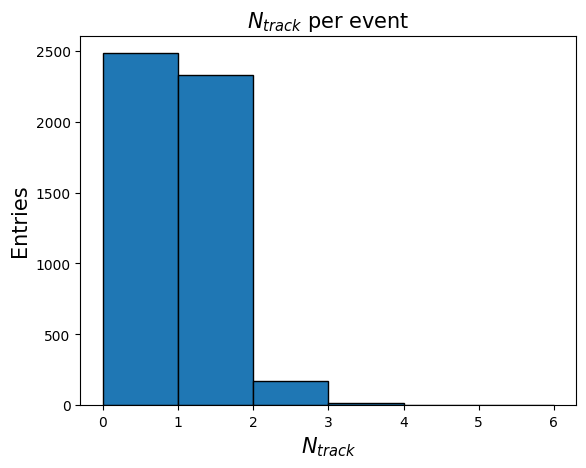

In [6]:
plt.hist(sample[:,0,I_Ntrack], edgecolor='black', bins=6, range=(0, 6))
plt.title("$N_{track}$ per event",fontsize = 15)
plt.xlabel("$N_{track}$",fontsize = 15)
plt.ylabel("Entries",fontsize = 15)
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.show()

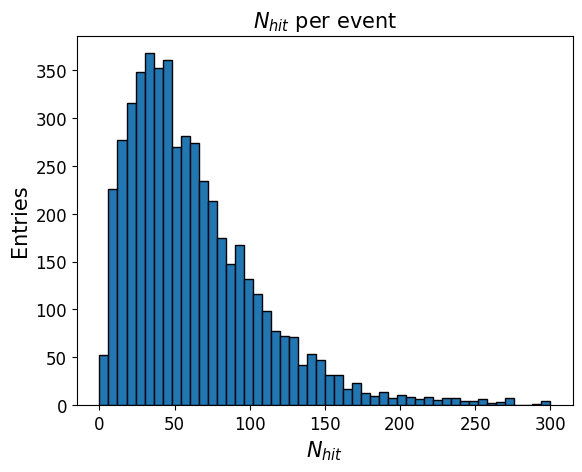

In [7]:
plt.hist(sample[:,0,I_Nhit],edgecolor='black', bins=50, range=(0, 300))
plt.title("$N_{hit}$ per event",fontsize = 15)
plt.xlabel("$N_{hit}$",fontsize = 15)
plt.ylabel("Entries",fontsize = 15)
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.show()

In [8]:
list_Nhit_associated = []
list_Nhit_associated_1track = []
list_Nhit_associated_pertrack = []

In [9]:
for i in range(sample.shape[0]):
    N_evt = 0
    N_evt_pertrack = 0
    
    if int(sample[i,0,0]) > 0:
    
        for j in range(int(sample[i,0,1])):
            N_evt_i = sample[i,0,I_hit_track + 8*j ]
            if N_evt_i > 0:
                N_evt += 1

#             for k in range(0,8):
#                 if int(N_evt_i)%(2**k) == 1:
#                     N_evt_pertrack += 1

#         N_evt_pertrack/int(sample[i,0,0])
    
        list_Nhit_associated.append(N_evt)
        list_Nhit_associated_pertrack.append(N_evt/int(sample[i,0,0]))
        n or declare the variable inside the dataflo
        if int(sample[i,0,0]) == 1:
            list_Nhit_associated_1track.append(N_evt)
            

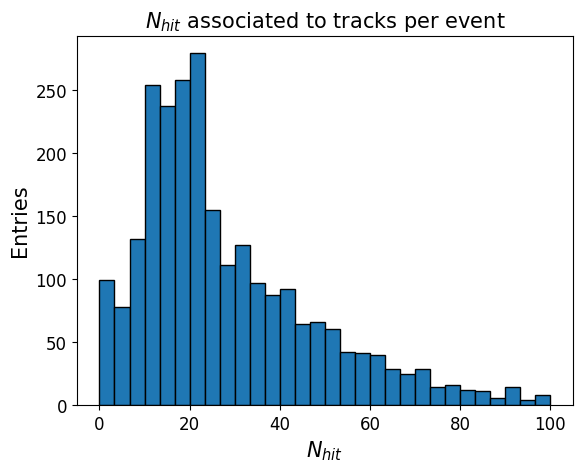

In [10]:
plt.hist(list_Nhit_associated,edgecolor='black', bins=30, range=(0, 100))
plt.title("$N_{hit}$ associated to tracks per event",fontsize = 15)
plt.xlabel("$N_{hit}$",fontsize = 15)
plt.ylabel("Entries",fontsize = 15)
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.show()

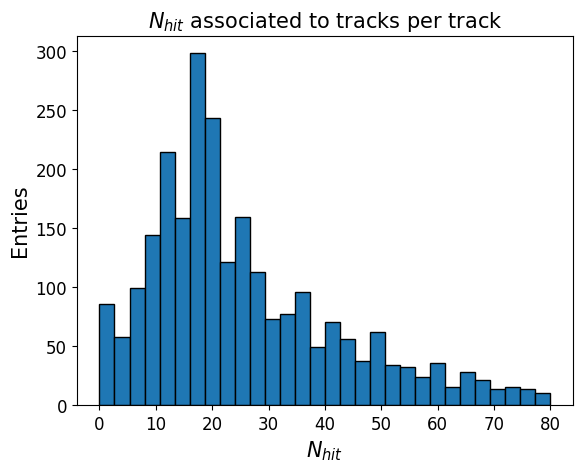

In [11]:
plt.hist(list_Nhit_associated_pertrack,edgecolor='black', bins=30, range=(0, 80))
plt.title("$N_{hit}$ associated to tracks per track",fontsize = 15)
plt.xlabel("$N_{hit}$",fontsize = 15)
plt.ylabel("Entries",fontsize = 15)
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.show()

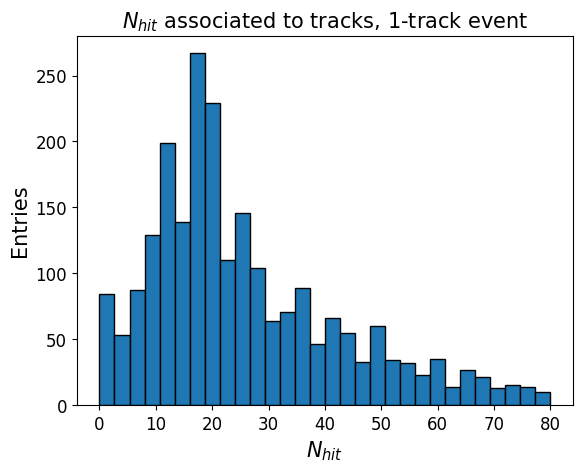

In [12]:
plt.hist(list_Nhit_associated_1track,edgecolor='black', bins=30, range=(0, 80))
plt.title("$N_{hit}$ associated to tracks, 1-track event",fontsize = 15)
plt.xlabel("$N_{hit}$",fontsize = 15)
plt.ylabel("Entries",fontsize = 15)
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.show()

In [6]:
list_Ntrack = []
list_Nhit = []
list_globalfebID = []
list_channelID = []
list_mergerID = []
list_localfebID = []

In [14]:
for i in range(sample.shape[0]):
    list_Ntrack.append(sample[i,0,0])
    list_Nhit.append(sample[i,0,1])
    
    for j in range(int(sample[i,0,1])):
        list_globalfebID.append(sample[i,0,I_hit_globalfebID + 8*j ])
        list_channelID.append(sample[i,0,I_hit_channelID + 8*j ])
        list_mergerID.append(sample[i,0,I_hit_mergerID + 8*j ])
        list_localfebID.append(sample[i,0,I_hit_localfebID + 8*j ])
    

In [15]:
evt_index = 100
print("Ntrack:",int(sample[evt_index,0,0]),"Nhit",int(sample[evt_index,0,1]))

Ntrack: 1 Nhit 51


In [16]:
array_X = np.zeros(int(sample[evt_index,0,1]))
array_Y = np.zeros(int(sample[evt_index,0,1]))
list_tX = []
list_tY = []
array_trackX = np.zeros(int(sample[evt_index,0,0]))
array_trackY = np.zeros(int(sample[evt_index,0,0]))

In [17]:
for i in range(int(sample[evt_index,0,0])):
    array_trackX[i] = sample[evt_index,0,I_track_X + 5*i ]
    array_trackY[i] = sample[evt_index,0,I_track_Y + 5*i ]

In [18]:
for i in range(int(sample[evt_index,0,1])):
    array_X[i] = sample[evt_index,0,I_hit_X + 8*i ]
    array_Y[i] = sample[evt_index,0,I_hit_Y + 8*i ]
    if sample[evt_index,0,I_hit_track + 8*i ] > 0:
        list_tX.append(sample[evt_index,0,I_hit_X + 8*i ])
        list_tY.append(sample[evt_index,0,I_hit_Y + 8*i ])

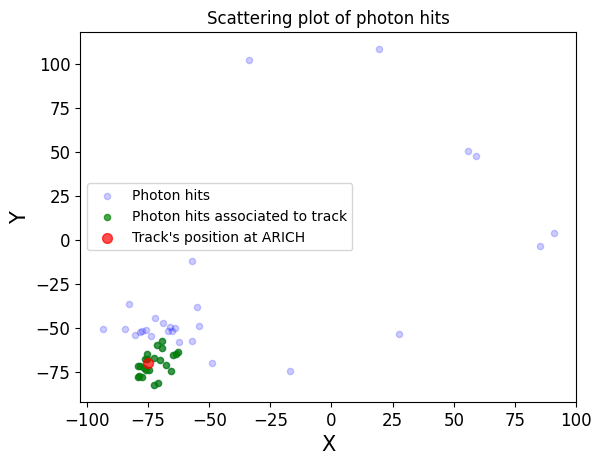

In [19]:
plt.scatter(array_X, array_Y, color='blue', alpha=0.2, s = 20, label = "Photon hits")
plt.scatter(list_tX, list_tY, color='green', alpha=0.7, s = 20, label = "Photon hits associated to track")
plt.scatter(array_trackX, array_trackY, color='red', alpha=0.7, s = 50, label = "Track's position at ARICH")
plt.legend(fontsize=10)
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.title("Scattering plot of photon hits")
plt.xlabel("X", fontsize = 15)
plt.ylabel("Y", fontsize = 15)
plt.show()

MERGER ID ->1


In [22]:
list_Ntrack=[]
list_Nhit=[]
list_globalfebID=[]
list_channelID=[]
list_mergerID=[]
list_localfebID=[]
list_Nhit_associated= []
list_Nhit_associated_1track=[]
list_Nhit_associated_pertrack=[]

In [21]:
for evt_index in range(len(sample)):
    num_tracks = int(sample[evt_index, 0, I_Ntrack])
    num_hits = int(sample[evt_index, 0, I_Nhit])
    
    list_Ntrack.append(num_tracks)
    list_Nhit.append(num_hits)
    
    for j in range(num_hits):
        # Using a float cast conversion step before turning to int to handle potential float elements safely
        m_id = int(float(sample[evt_index, 0, I_hit_mergerID + (8 * j)]))
        
        if m_id == 1:
            gf_id = int(float(sample[evt_index, 0, I_hit_globalfebID + (8 * j)]))
            ch_id = int(float(sample[evt_index, 0, I_hit_channelID + (8 * j)]))
            lf_id = int(float(sample[evt_index, 0, I_hit_localfebID + (8 * j)]))
            track_assoc = int(float(sample[evt_index, 0, I_hit_track + (8 * j)]))
            
            list_globalfebID.append(gf_id)
            list_channelID.append(ch_id)
            list_mergerID.append(m_id)
            list_localfebID.append(lf_id)
            list_Nhit_associated.append(track_assoc)
            
            active_track_count = 0
            associated_track_ids = []
            
            for track_bit in range(4):
                if (track_assoc & (1 << track_bit)) != 0:
                    active_track_count += 1
                    associated_track_ids.append(track_bit)
            
            if active_track_count == 1:
                list_Nhit_associated_1track.append(track_assoc)
                list_Nhit_associated_pertrack.append(associated_track_ids[0])

print("Finished processing data.\n")


Finished processing data.



MERGER ID -> 13

In [22]:
total_events = sample.shape[0]
max_hits = 300

hit_start_idx = I_hit_globalfebID
hit_end_idx = I_hit_globalfebID + (max_hits * 8)
raw_hit_block = sample[:, 0, hit_start_idx:hit_end_idx].astype(float)

hits_reshaped = raw_hit_block.reshape(total_events * max_hits, 8)

gf_all = hits_reshaped[:, 0].astype(int)
ch_all = hits_reshaped[:, 1].astype(int)
m_all  = hits_reshaped[:, 2].astype(int)
lf_all = hits_reshaped[:, 3].astype(int)
tr_all = hits_reshaped[:, 4].astype(int)

In [23]:
merger_mask = (m_all == 13) & (gf_all > 0)

list_globalfebID = gf_all[merger_mask].tolist()
list_channelID   = ch_all[merger_mask].tolist()
list_mergerID    = m_all[merger_mask].tolist()
list_localfebID  = lf_all[merger_mask].tolist()
list_Nhit_associated = tr_all[merger_mask].tolist()

list_Ntrack = sample[:, 0, I_Ntrack].astype(int).tolist()
list_Nhit = sample[:, 0, I_Nhit].astype(int).tolist()

In [24]:
filtered_tracks = tr_all[merger_mask]
active_track_count = ((filtered_tracks >> 0) & 1) + ((filtered_tracks >> 1) & 1) + \
                     ((filtered_tracks >> 2) & 1) + ((filtered_tracks >> 3) & 1)

single_track_mask = (active_track_count == 1)
list_Nhit_associated_1track = filtered_tracks[single_track_mask].tolist()

list_Nhit_associated_pertrack = [x.bit_length() - 1 for x in list_Nhit_associated_1track]

print(f"Vectorized processing complete. Merger 13 hits found: {len(list_mergerID)}")

Vectorized processing complete. Merger 13 hits found: 5135


MERGER ID -> 25

In [25]:
total_events = sample.shape[0]
max_hits = 300

hit_start_idx = I_hit_globalfebID
hit_end_idx = I_hit_globalfebID + (max_hits * 8)
raw_hit_block = sample[:, 0, hit_start_idx:hit_end_idx].astype(float)

hits_reshaped = raw_hit_block.reshape(total_events * max_hits, 8)

gf_all = hits_reshaped[:, 0].astype(int)
ch_all = hits_reshaped[:, 1].astype(int)
m_all  = hits_reshaped[:, 2].astype(int)
lf_all = hits_reshaped[:, 3].astype(int)
tr_all = hits_reshaped[:, 4].astype(int)

In [26]:

merger_mask = (m_all == 25) & (gf_all > 0)

list_globalfebID = gf_all[merger_mask].tolist()
list_channelID   = ch_all[merger_mask].tolist()
list_mergerID    = m_all[merger_mask].tolist()
list_localfebID  = lf_all[merger_mask].tolist()
list_Nhit_associated = tr_all[merger_mask].tolist()

list_Ntrack = sample[:, 0, I_Ntrack].astype(int).tolist()
list_Nhit = sample[:, 0, I_Nhit].astype(int).tolist()

In [27]:
filtered_tracks = tr_all[merger_mask]
active_track_count = ((filtered_tracks >> 0) & 1) + ((filtered_tracks >> 1) & 1) + \
                     ((filtered_tracks >> 2) & 1) + ((filtered_tracks >> 3) & 1)

single_track_mask = (active_track_count == 1)
list_Nhit_associated_1track = filtered_tracks[single_track_mask].tolist()

list_Nhit_associated_pertrack = [x.bit_length() - 1 for x in list_Nhit_associated_1track]

print(f"Vectorized processing complete. Merger 25 hits found: {len(list_mergerID)}")

Vectorized processing complete. Merger 25 hits found: 5680


MERGER ID -> 37


In [28]:
merger_mask = (m_all == 37) & (gf_all > 0)

list_globalfebID = gf_all[merger_mask].tolist()
list_channelID   = ch_all[merger_mask].tolist()
list_mergerID    = m_all[merger_mask].tolist()
list_localfebID  = lf_all[merger_mask].tolist()
list_Nhit_associated = tr_all[merger_mask].tolist()

list_Ntrack = sample[:, 0, I_Ntrack].astype(int).tolist()
list_Nhit = sample[:, 0, I_Nhit].astype(int).tolist()

In [29]:
filtered_tracks = tr_all[merger_mask]
active_track_count = ((filtered_tracks >> 0) & 1) + ((filtered_tracks >> 1) & 1) + \
                     ((filtered_tracks >> 2) & 1) + ((filtered_tracks >> 3) & 1)

single_track_mask = (active_track_count == 1)
list_Nhit_associated_1track = filtered_tracks[single_track_mask].tolist()

list_Nhit_associated_pertrack = [x.bit_length() - 1 for x in list_Nhit_associated_1track]

print(f"Vectorized processing complete. Merger 37 hits found: {len(list_mergerID)}")

Vectorized processing complete. Merger 37 hits found: 5250


MERGER ID -> 49

In [30]:
merger_mask = (m_all == 49) & (gf_all > 0)

list_globalfebID = gf_all[merger_mask].tolist()
list_channelID   = ch_all[merger_mask].tolist()
list_mergerID    = m_all[merger_mask].tolist()
list_localfebID  = lf_all[merger_mask].tolist()
list_Nhit_associated = tr_all[merger_mask].tolist()

list_Ntrack = sample[:, 0, I_Ntrack].astype(int).tolist()
list_Nhit = sample[:, 0, I_Nhit].astype(int).tolist()

In [31]:
filtered_tracks = tr_all[merger_mask]
active_track_count = ((filtered_tracks >> 0) & 1) + ((filtered_tracks >> 1) & 1) + \
                     ((filtered_tracks >> 2) & 1) + ((filtered_tracks >> 3) & 1)

single_track_mask = (active_track_count == 1)
list_Nhit_associated_1track = filtered_tracks[single_track_mask].tolist()

list_Nhit_associated_pertrack = [x.bit_length() - 1 for x in list_Nhit_associated_1track]

print(f"Vectorized processing complete. Merger 49 hits found: {len(list_mergerID)}")

Vectorized processing complete. Merger 49 hits found: 5076


MERGER ID -> 61

In [32]:
merger_mask = (m_all == 61) & (gf_all > 0)

list_globalfebID = gf_all[merger_mask].tolist()
list_channelID   = ch_all[merger_mask].tolist()
list_mergerID    = m_all[merger_mask].tolist()
list_localfebID  = lf_all[merger_mask].tolist()
list_Nhit_associated = tr_all[merger_mask].tolist()

list_Ntrack = sample[:, 0, I_Ntrack].astype(int).tolist()
list_Nhit = sample[:, 0, I_Nhit].astype(int).tolist()

In [33]:
filtered_tracks = tr_all[merger_mask]
active_track_count = ((filtered_tracks >> 0) & 1) + ((filtered_tracks >> 1) & 1) + \
                     ((filtered_tracks >> 2) & 1) + ((filtered_tracks >> 3) & 1)

single_track_mask = (active_track_count == 1)
list_Nhit_associated_1track = filtered_tracks[single_track_mask].tolist()

list_Nhit_associated_pertrack = [x.bit_length() - 1 for x in list_Nhit_associated_1track]

print(f"Vectorized processing complete. Merger 61 hits found: {len(list_mergerID)}")

Vectorized processing complete. Merger 61 hits found: 4676


In [34]:
target_mergers = [1, 13, 25, 37, 49, 61]
total_hits_per_merger = []
single_track_hits_per_merger = []

VISUAL

In [35]:
for merger_id in target_mergers:

    mask = (m_all == merger_id) & (gf_all > 0)
    total_hits = np.sum(mask)
    total_hits_per_merger.append(total_hits)
    

    filtered_tracks = tr_all[mask]
    active_track_count = ((filtered_tracks >> 0) & 1) + ((filtered_tracks >> 1) & 1) + \
                         ((filtered_tracks >> 2) & 1) + ((filtered_tracks >> 3) & 1)
    single_track_hits = np.sum(active_track_count == 1)
    single_track_hits_per_merger.append(single_track_hits)



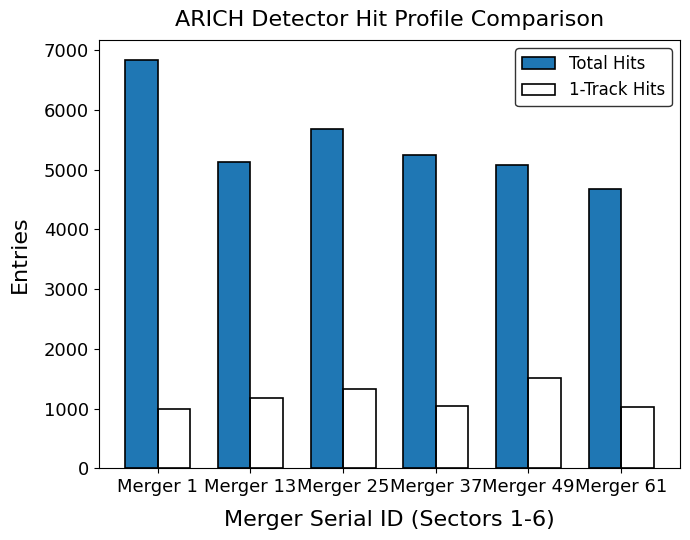

In [36]:
fig, ax = plt.subplots(figsize=(7, 5.5))
x = np.arange(len(target_mergers))
width = 0.35

ax.bar(x - width/2, total_hits_per_merger, width, label='Total Hits', 
       color='#1f77b4', edgecolor='black', linewidth=1.2)

ax.bar(x + width/2, single_track_hits_per_merger, width, label='1-Track Hits', 
       color='none', edgecolor='black', linewidth=1.2)

ax.set_xlabel('Merger Serial ID (Sectors 1-6)', fontsize=16, labelpad=10)
ax.set_ylabel('Entries', fontsize=16, labelpad=10)
ax.set_title('ARICH Detector Hit Profile Comparison', fontsize=16, pad=10)
ax.set_xticks(x)
ax.set_xticklabels([f'Merger {m}' for m in target_mergers], fontsize=13)
ax.tick_params(axis='y', labelsize=13)


ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.legend(fontsize=12, frameon=True, edgecolor='black')

plt.tight_layout()
plt.savefig('arich_mergers_comparison.png', bbox_inches='tight', dpi=300)
plt.show()

In [23]:
import glob
import os

file_list = sorted(glob.glob("/data/ytlai/arich_trg/*bhabha*_calib*.npy"))
for f in file_list:
    print(f" - {os.path.basename(f)}")
sample = np.concatenate([np.load(f) for f in file_list])



 - physics.0040.00900.HLT00.hlt_bhabha_combined_calib.f00000.root_chunk0000.npy
 - physics.0040.00900.HLT00.hlt_bhabha_combined_calib.f00000.root_chunk0001.npy
 - physics.0040.00900.HLT00.hlt_bhabha_combined_calib.f00000.root_chunk0002.npy
 - physics.0040.00900.HLT00.hlt_bhabha_combined_calib.f00000.root_chunk0003.npy
 - physics.0040.00900.HLT00.hlt_bhabha_combined_calib.f00000.root_chunk0004.npy
 - physics.0040.00900.HLT00.hlt_bhabha_combined_calib.f00000.root_chunk0005.npy
 - physics.0040.00900.HLT00.hlt_bhabha_combined_calib.f00000.root_chunk0006.npy
 - physics.0040.00900.HLT00.hlt_bhabha_combined_calib.f00000.root_chunk0007.npy
 - physics.0040.00900.HLT00.hlt_bhabha_combined_calib.f00000.root_chunk0008.npy
 - physics.0040.00900.HLT00.hlt_bhabha_combined_calib.f00000.root_chunk0009.npy
 - physics.0040.00900.HLT00.hlt_bhabha_combined_calib.f00000.root_chunk0010.npy
 - physics.0040.00900.HLT00.hlt_bhabha_combined_calib.f00000.root_chunk0011.npy
 - physics.0040.00900.HLT00.hlt_bhabha_c

CASE ANALYSIS FOR SPECIFIC CASE SCENARIO

In [24]:
TARGET_MERGER = 13  #targert merger_id for case analysis 

In [39]:
associated_hits_per_event = []
non_associated_hits_per_event = []
one_track_hits_per_event = []
hits_per_track_clean = []

digital_array_grid = np.zeros((2, 3))
channel_matrix = np.zeros((6, 36)) 

In [40]:
for evt_idx in range(sample.shape[0]):
    n_hits = int(sample[evt_idx, 0, I_Nhit])
    if n_hits == 0:
        continue

    evt_hit_start = I_hit_globalfebID
    evt_hit_end = evt_hit_start + (n_hits * 8)
    evt_hits = sample[evt_idx, 0, evt_hit_start:evt_hit_end].reshape(n_hits, 8)

    merger_mask = (evt_hits[:, 2] == TARGET_MERGER)
    m_hits = evt_hits[merger_mask]

    if len(m_hits) == 0:
        continue

    gf_ids = m_hits[:, 0].astype(int)
    lf_ids = m_hits[:, 3].astype(int)
    tr_words = m_hits[:, 4].astype(int)
    ch_ids = m_hits[:, 1].astype(int) 


    associated_mask = (tr_words > 0)
    associated_hits_per_event.append(np.sum(associated_mask))
    non_associated_hits_per_event.append(np.sum(~associated_mask))


    active_tracks = ((tr_words >> 0) & 1) + ((tr_words >> 1) & 1) + \
                    ((tr_words >> 2) & 1) + ((tr_words >> 3) & 1)

    if np.any(active_tracks == 1):
        one_track_hits_per_event.append(len(m_hits))
        for tw in tr_words[active_tracks == 1]:
            hits_per_track_clean.append(int(tw).bit_length() - 1)


    for lf, ch in zip(lf_ids, ch_ids):
  
        if 1 <= lf <= 3:
            digital_array_grid[0, lf - 1] += 1
        elif 4 <= lf <= 6:
            digital_array_grid[1, lf - 4] += 1

        if 1 <= lf <= 6 and 0 <= ch < 36:
            channel_matrix[lf - 1, ch] += 1


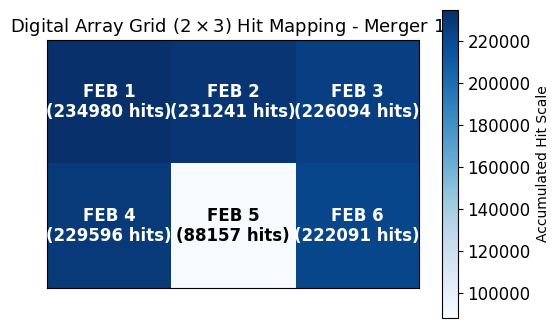

In [41]:
plt.figure(figsize=(6, 4))


plt.imshow(digital_array_grid, cmap='Blues', aspect='equal')

feb_labels = [['FEB 1', 'FEB 2', 'FEB 3'], ['FEB 4', 'FEB 5', 'FEB 6']]

for r in range(2):
    for c in range(3):
        val = int(digital_array_grid[r, c])
        text_color = 'white' if val > (np.max(digital_array_grid) * 0.6) else 'black'
        
        plt.text(c, r, f'{feb_labels[r][c]}\n({val} hits)', 
                 ha='center', va='center', color=text_color, fontsize=12, fontweight='bold')

plt.title(f'Digital Array Grid ($2 \\times 3$) Hit Mapping - Merger {TARGET_MERGER}', fontsize=13)
plt.xticks([])
plt.yticks([])
plt.colorbar(label='Accumulated Hit Scale')
plt.savefig(f'merger_{TARGET_MERGER}_digital_array.png', dpi=300, bbox_inches='tight')
plt.show()

In [42]:
physical_matrix_24x36 = np.zeros((24, 36))

for evt_idx in range(sample.shape[0]):
    n_hits = int(sample[evt_idx, 0, I_Nhit])
    if n_hits == 0: 
        continue
    evt_hits = sample[evt_idx, 0, I_hit_globalfebID:I_hit_globalfebID + (n_hits * 8)].reshape(n_hits, 8)
    
    m_hits = evt_hits[evt_hits[:, 2] == TARGET_MERGER]
    for hit in m_hits:
        lf_id = int(hit[3])   # Local FEB (1 to 6)
        ch_id = int(hit[1])   # Channel ID (0 to 35)
        
        if 1 <= lf_id <= 6 and 0 <= ch_id < 36:
            local_row = ch_id // 6  # 0 to 5
        
            global_row = ((lf_id - 1) * 4) + (local_row % 4) 
            global_col = ch_id 
            
            physical_matrix_24x36[global_row, global_col] += 1


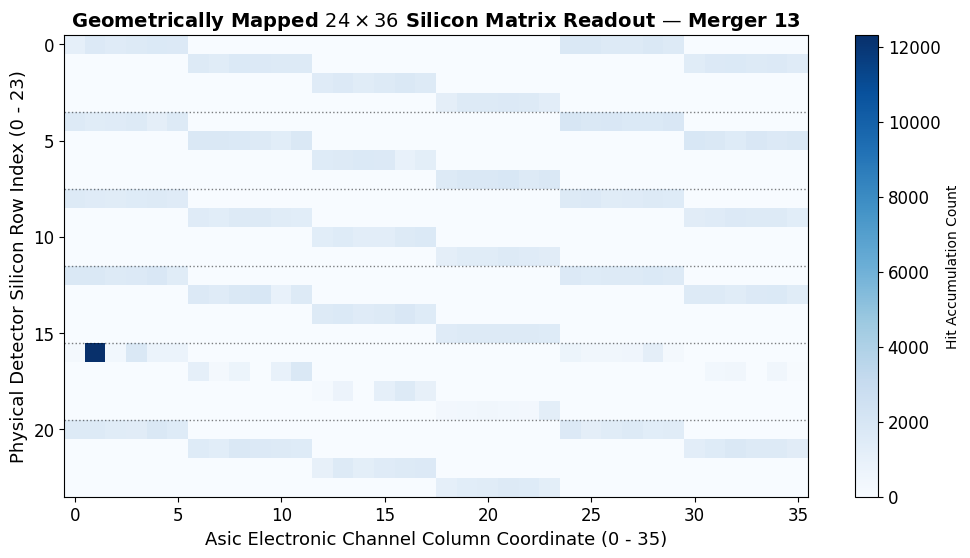

In [43]:
X_trainplt.figure(figsize=(12, 6))

plt.imshow(physical_matrix_24x36, cmap='Blues', aspect='auto', interpolation='nearest')

plt.colorbar(label='Hit Accumulation Count')
plt.xlabel('Asic Electronic Channel Column Coordinate (0 - 35)', fontsize=13)
plt.ylabel('Physical Detector Silicon Row Index (0 - 23)', fontsize=13)

for i in range(1, 6):
    plt.axhline(y=i*4 - 0.5, color='black', linestyle=':', alpha=0.5, linewidth=1)

plt.title(f'Geometrically Mapped $24 \\times 36$ Silicon Matrix Readout — Merger {TARGET_MERGER}', fontsize=14, fontweight='bold')
plt.savefig(f'merger_{TARGET_MERGER}_physical_matrix_24x36.png', dpi=300, bbox_inches='tight')
plt.show()

In [44]:
def get_merger_hits(evt_idx):
    n_hits = int(sample[evt_idx, 0, I_Nhit])
    if n_hits == 0: return None
    evt_hits = sample[evt_idx, 0, I_hit_globalfebID:I_hit_globalfebID + (n_hits * 8)].reshape(n_hits, 8)
    return evt_hits[evt_hits[:, 2] == TARGET_MERGER]

In [45]:
def map_coordinates(m_hits):
    lf_id, ch_id = m_hits[:, 3].astype(int), m_hits[:, 1].astype(int)
    g_row = ((lf_id - 1) * 4) + ((ch_id // 6) % 4)
    return ch_id, g_row, m_hits[:, 4].astype(int)

In [46]:
def setup_detector_plot(evt_idx):
    plt.figure(figsize=(11, 5.5))
    plt.xlim(-0.5, 35.5)
    plt.ylim(-0.5, 23.5)
    plt.gca().invert_yaxis()
    for i in range(1, 6):
        plt.axhline(y=i*4 - 0.5, color='black', linestyle=':', alpha=0.5, linewidth=1)

In [47]:
def add_plot_details(x, y, is_assoc, evt_idx):
    if np.any(is_assoc == 1):
        plt.scatter(x[is_assoc == 1], y[is_assoc == 1], color='#00a2ff', marker='o', 
                    s=160, edgecolors='black', linewidths=1.5, label='Associated Track Hit (Signal)', zorder=4)
    if np.any(is_assoc == 0):
        plt.scatter(x[is_assoc == 0], y[is_assoc == 0], color='#ff4500', marker='x', 
                    s=140, linewidths=2.5, label='Stray Noise Hit (Background)', zorder=3)

In [48]:
def render_event_plot(evt_idx):
    plt.title(f'Single Event Topological Breakdown — Event #{evt_idx}', fontsize=13, fontweight='bold')
    plt.xlabel('Asic Electronic Channel Column Coordinate (0 - 35)', fontsize=11)
    plt.ylabel('Physical Detector Silicon Row Index (0 - 23)', fontsize=11)
    plt.grid(True, which='both', linestyle='--', alpha=0.3)
    plt.legend(loc='lower right', framealpha=0.9)
    plt.tight_layout()
    plt.show()

In [49]:
def plot_single_event_breakdown(evt_idx):
    m_hits = get_merger_hits(evt_idx)
    if m_hits is None or len(m_hits) == 0: return
    x, y, is_assoc = map_coordinates(m_hits)
    setup_detector_plot(evt_idx)
    add_plot_details(x, y, is_assoc, evt_idx)
    render_event_plot(evt_idx)

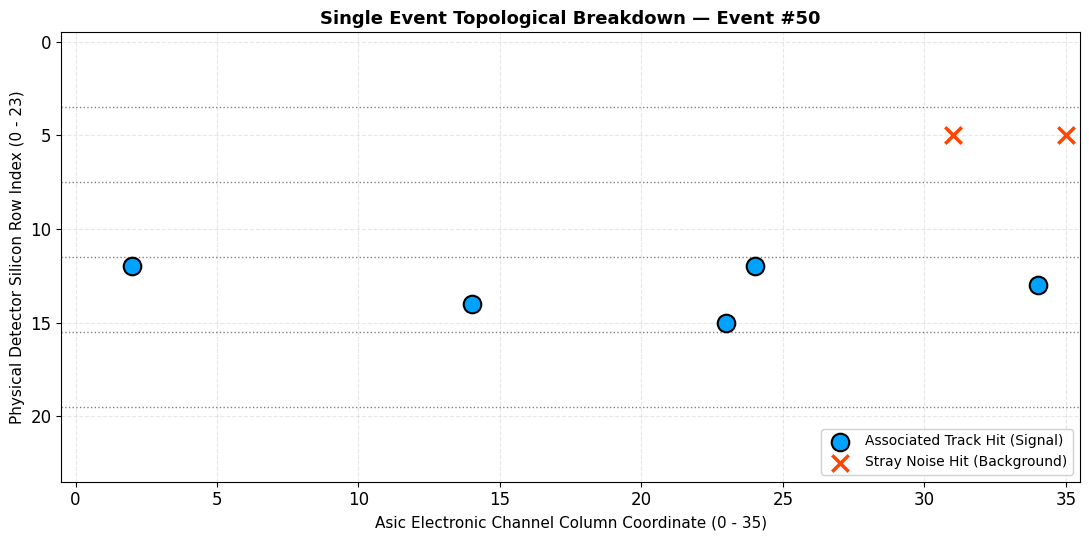

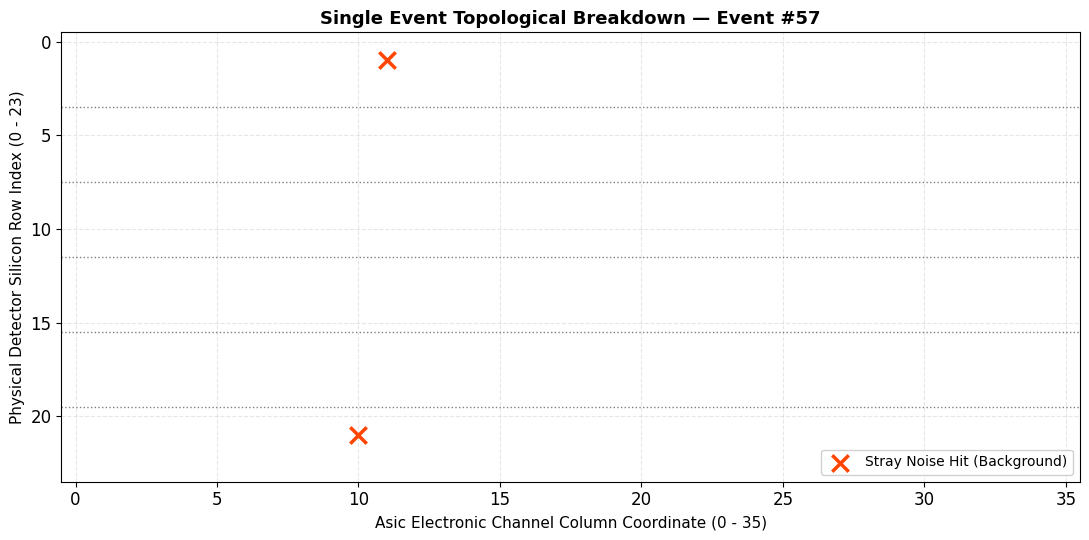

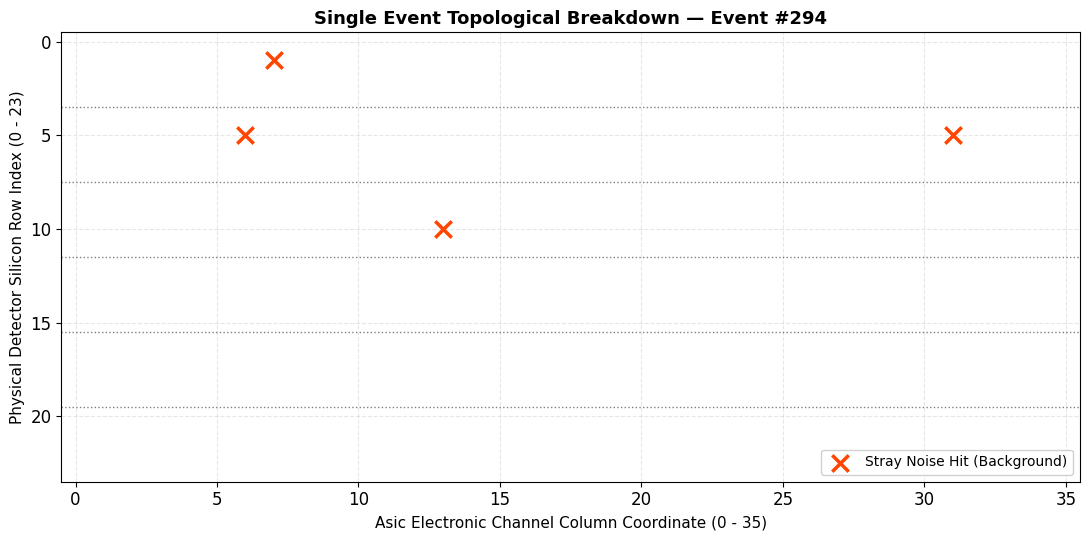

In [50]:
my_chosen_events = [0, 50, 57,294] 

for evt in my_chosen_events:
    plot_single_event_breakdown(evt)

In [149]:
sig_event_all_hits, sig_event_assoc_hits, sig_event_non_assoc_hits = [], [], []
bg_event_all_hits = []
bins_range = np.arange(0, 30, 1)

In [150]:
def process_event_multiplicity(evt_idx):
    n_hits = int(sample[evt_idx, 0, I_Nhit])
    if n_hits == 0: return None
    evt_hits = sample[evt_idx, 0, I_hit_globalfebID:I_hit_globalfebID + (n_hits * 8)].reshape(n_hits, 8)
    return evt_hits[evt_hits[:, 2] == TARGET_MERGER]

In [151]:
def calculate_metrics(m_hits):
    tr_words = m_hits[:, 4].astype(int)
    n_assoc = np.sum(tr_words > 0)
    n_non_assoc = np.sum(tr_words == 0)
    return len(m_hits), n_assoc, n_non_assocX_train

In [152]:
def categorize_metrics(n_total, n_assoc, n_non_assoc):
    if n_assoc >= 1:
        sig_event_all.append(n_total)
        sig_event_assoc.append(n_assoc)
        sig_event_noise.append(n_non_assoc)
    else:
        bg_event_all.append(n_total)

In [153]:
for idx in range(sample.shape[0]):
    m_hits = process_event_multiplicity(idx)
    if m_hits is None or len(m_hits) == 0: continue
    
    tot, assoc, noise = calculate_metrics(m_hits)
    if tot == 0: continue # Skip if safety filter dropped the hits
    
    if assoc >= 1:
        sig_event_all_hits.append(tot)
        sig_event_assoc_hits.append(assoc)
        sig_event_non_assoc_hits.append(noise)
    else:
        bg_event_all_hits.append(tot)

In [154]:
plt.figure(figsize=(9, 6))
bins_range = np.arange(0, 30, 1)

<Figure size 900x600 with 0 Axes>

(array([   0., 2373., 1255., 1044.,  962.,  890.,  800.,  759.,  682.,
         671.,  616.,  603.,  581.,  550.,  528.,  512.,  412.,  407.,
         382.,  329.,  316.,  320.,  261.,  213.,  214.,  199.,  198.,
         168.,  337.]),
 array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
        13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
        26., 27., 28., 29.]),
 [<matplotlib.patches.Polygon at 0x778728643e20>])

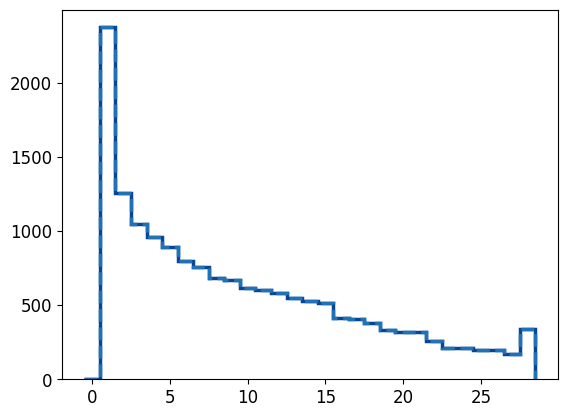

In [155]:
plt.hist(sig_event_assoc_hits, bins=bins_range, histtype='step', linewidth=2.5, color='#084594', label='Signal Event: All Hits', align='left')
plt.hist(sig_event_assoc_hits, bins=bins_range, histtype='step', linewidth=2.5, linestyle='--', color='#2171b5', label='Signal Event: Associated Hits', align='left')

(array([     0., 178223.,  41946.,  18102.,  10897.,   7679.,   5718.,
          4482.,   3698.,   3049.,   2631.,   2318.,   2016.,   1750.,
          1528.,   1440.,   1154.,   1052.,    922.,    768.,    699.,
           566.,    492.,    388.,    372.,    300.,    287.,    240.,
           377.]),
 array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
        13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
        26., 27., 28., 29.]),
 [<matplotlib.patches.Polygon at 0x7787287d27a0>])

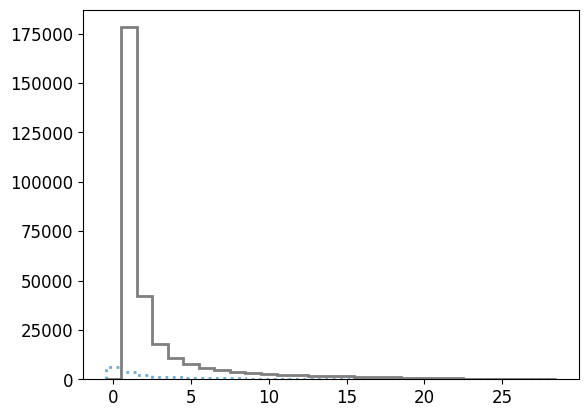

In [156]:
plt.hist(sig_event_non_assoc_hits, bins=bins_range, histtype='step', linewidth=2, linestyle=':', color='#6baed6', label='Signal Event: Non-Associated Hits', align='left')
plt.hist(bg_event_all_hits, bins=bins_range, histtype='step', linewidth=2, color='#7f7f7f', label='Background Event: All Hits (Noise)', align='left')

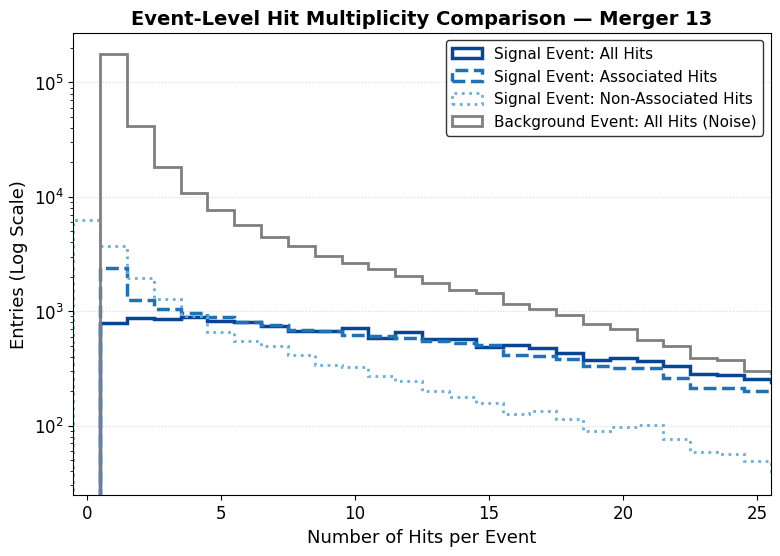

In [157]:
plt.figure(figsize=(9, 6))

plt.hist(sig_event_all_hits, bins=bins_range, histtype='step', linewidth=2.5, 
         color='#084594', label='Signal Event: All Hits', align='left')
plt.hist(sig_event_assoc_hits, bins=bins_range, histtype='step', linewidth=2.5, 
         linestyle='--', color='#2171b5', label='Signal Event: Associated Hits', align='left')
plt.hist(sig_event_non_assoc_hits, bins=bins_range, histtype='step', linewidth=2, 
         linestyle=':', color='#6baed6', label='Signal Event: Non-Associated Hits', align='left')
plt.hist(bg_event_all_hits, bins=bins_range, histtype='step', linewidth=2, 
         color='#7f7f7f', label='Background Event: All Hits (Noise)', align='left')

plt.yscale('log')
plt.xlim(-0.5, 25.5)
plt.xlabel('Number of Hits per Event', fontsize=13)
plt.ylabel('Entries (Log Scale)', fontsize=13)
plt.title(f'Event-Level Hit Multiplicity Comparison — Merger {TARGET_MERGER}', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='upper right', frameon=True, edgecolor='black')
plt.grid(axis='y', linestyle=':', alpha=0.5)

# Save a clean copy to your workspace directory
plt.savefig(f'merger_{TARGET_MERGER}_overlapped_histograms.png', dpi=300, bbox_inches='tight')
plt.show()

In [160]:
# Check if your raw functions work at all
test_hits = process_event_multiplicity(0)
print(f"Test Event 0 hits found for Merger {TARGET_MERGER}: {len(test_hits) if test_hits is not None else 0}")

# Re-run with explicit local print tracking
sig_count, bg_count = 0, 0
for idx in range(min(1000, sample.shape[0])): # Check first 1000 events
    m_hits = process_event_multiplicity(idx)
    if m_hits is None or len(m_hits) == 0: continue
    
    tot, assoc, noise = calculate_metrics(m_hits)
    if assoc >= 1:
        sig_count += 1
    else:
        bg_count += 1

print(f"Debug Scan (First 1000 events) -> Found {sig_count} signals | {bg_count} backgrounds")

Test Event 0 hits found for Merger 13: 0
Debug Scan (First 1000 events) -> Found 12 signals | 237 backgrounds


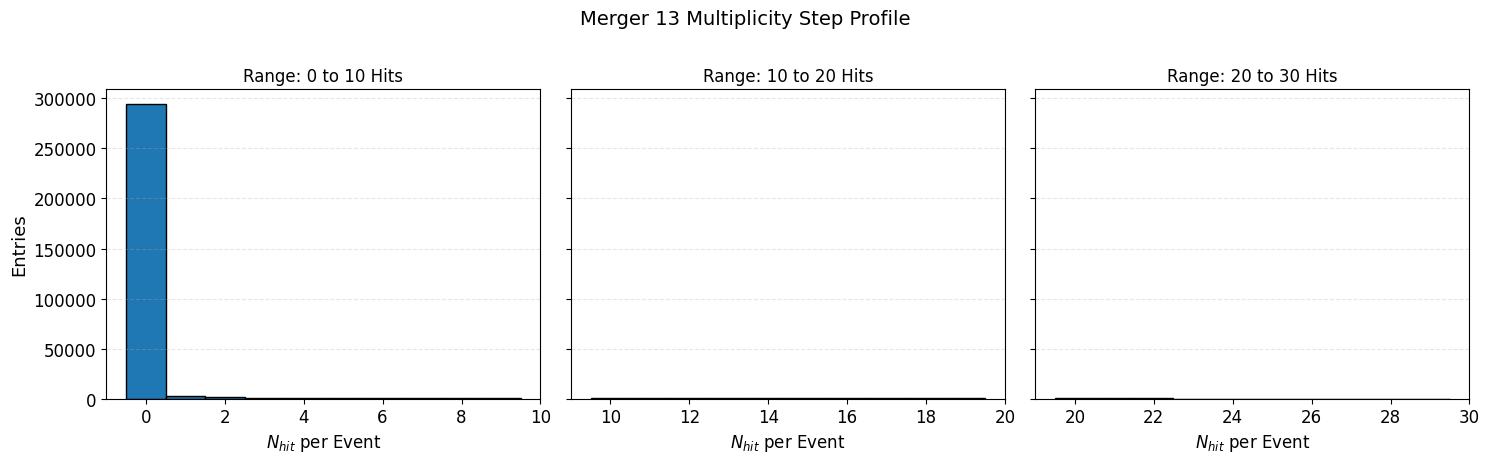

In [161]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
ranges = [(0, 10), (10, 20), (20, 30)]

for i, (low, high) in enumerate(ranges):

    evt_counts = np.array(associated_hits_per_event)
    filtered_counts = evt_counts[(evt_counts >= low) & (evt_counts < high)]
    

    axes[i].hist(filtered_counts, bins=range(low, high + 1), 
                 color='#1f77b4', edgecolor='black', align='left')
    axes[i].set_xlabel('$N_{hit}$ per Event', fontsize=12)
    axes[i].set_title(f'Range: {low} to {high} Hits', fontsize=12)
    axes[i].grid(axis='y', linestyle='--', alpha=0.3)
axes[0].set_ylabel('Entries', fontsize=13)
plt.suptitle(f'Merger {TARGET_MERGER} Multiplicity Step Profile', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'merger_{TARGET_MERGER}_step_occupancy.png', dpi=300, bbox_inches='tight')
plt.show()

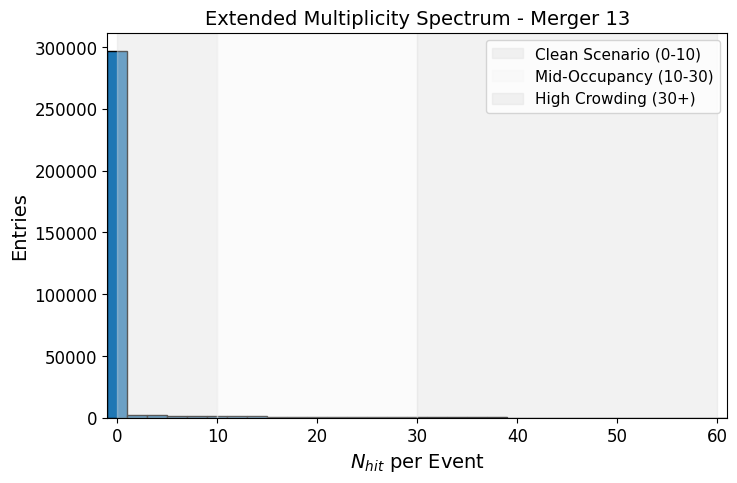

In [162]:
plt.figure(figsize=(8, 5))
plt.hist(associated_hits_per_event, bins=range(0, 65, 2), edgecolor='black', color='#1f77b4', align='left')


plt.axvspan(0, 10, color='#e0e0e0', alpha=0.4, label='Clean Scenario (0-10)')
plt.axvspan(10, 30, color='#f5f5f5', alpha=0.4, label='Mid-Occupancy (10-30)')
plt.axvspan(30, 60, color='#d6d6d6', alpha=0.3, label='High Crowding (30+)')

plt.xlabel('$N_{hit}$ per Event', fontsize=14)
plt.ylabel('Entries', fontsize=14)
plt.title(f'Extended Multiplicity Spectrum - Merger {TARGET_MERGER}', fontsize=14)
plt.xlim(-1, 61)
plt.legend(fontsize=11)
plt.savefig(f'merger_{TARGET_MERGER}_extended_multiplicity.png', dpi=300, bbox_inches='tight')
plt.show()

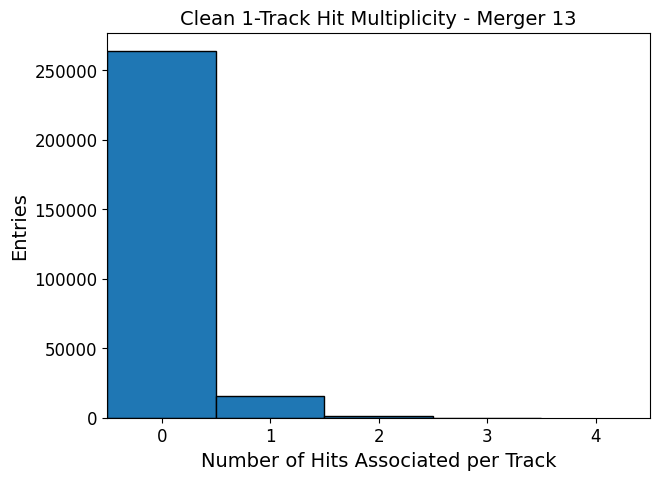

In [163]:
plt.figure(figsize=(7, 5))

if len(hits_per_track_clean) > 0:
    max_t_hits = max(hits_per_track_clean) + 2
    plt.hist(hits_per_track_clean, bins=range(0, max_t_hits), edgecolor='black', color='#1f77b4', align='left')
    plt.xlim(-0.5, max_t_hits - 0.5)
else:
    plt.text(0.5, 0.5, 'No 1-Track Events in Sample', ha='center', va='center', fontsize=14)

plt.xlabel('Number of Hits Associated per Track', fontsize=14)
plt.ylabel('Entries', fontsize=14)
plt.title(f'Clean 1-Track Hit Multiplicity - Merger {TARGET_MERGER}', fontsize=14)
plt.savefig(f'merger_{TARGET_MERGER}_hits_per_track.png', dpi=300, bbox_inches='tight')
plt.show()



PROGRESSIVE PLOT

In [164]:
sampled_sig_event = None
sampled_bg_event = None

In [165]:
for evt_idx in range(sample.shape[0]):
    n_hits = int(sample[evt_idx, 0, I_Nhit])
    if n_hits == 0: continue
    evt_hits = sample[evt_idx, 0, I_hit_globalfebID:I_hit_globalfebID + (n_hits * 8)].reshape(n_hits, 8)
    m_hits = evt_hits[evt_hits[:, 2] == TARGET_MERGER]
    if len(m_hits) < 3: continue
    
    tr_words = m_hits[:, 4].astype(int)
    n_assoc = np.sum(tr_words > 0)
    
    if n_assoc >= 2 and sampled_sig_event is None:
        sampled_sig_event = m_hits.copy()
    elif n_assoc == 0 and sampled_bg_event is None:
        sampled_bg_event = m_hits.copy()
        
    if sampled_sig_event is not None and sampled_bg_event is not None:
        break

In [172]:
if sampled_sig_event is not None:
    plt.figure(figsize=(8, 4))
    lf_ids = sampled_sig_event[:, 3].astype(int)
    ch_ids = sampled_sig_event[:, 1].astype(int)
    tr_words = sampled_sig_event[:, 4].astype(int)
    
    is_assoc = tr_words > 0


<Figure size 800x400 with 0 Axes>

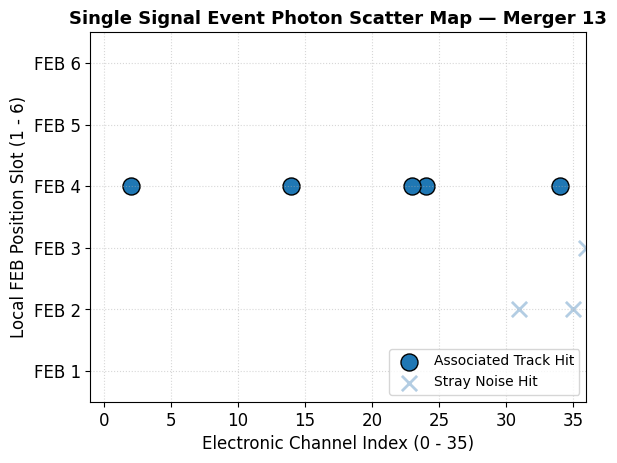

In [173]:
    
    plt.scatter(ch_ids[is_assoc], lf_ids[is_assoc], color='#1f77b4', marker='o', s=150, label='Associated Track Hit', edgecolor='black')
    
    plt.scatter(ch_ids[~is_assoc], lf_ids[~is_assoc], color='#b3cde3', marker='x', s=120, label='Stray Noise Hit', linewidth=2)
    
    plt.xlabel('Electronic Channel Index (0 - 35)', fontsize=12)
    plt.ylabel('Local FEB Position Slot (1 - 6)', fontsize=12)
    plt.yticks(range(1, 7), [f'FEB {i}' for i in range(1, 7)])
    plt.title(f'Single Signal Event Photon Scatter Map — Merger {TARGET_MERGER}', fontsize=13, fontweight='bold')
    plt.ylim(0.5, 6.5)
    plt.xlim(-1, 36)
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.legend(loc='lower right')
    plt.savefig('single_signal_event_scatter.png', dpi=300, bbox_inches='tight')
    plt.show()

In [174]:
if sampled_bg_event is not None:
    plt.figure(figsize=(8, 4))
    lf_ids_bg = sampled_bg_event[:, 3].astype(int)
    ch_ids_bg = sampled_bg_event[:, 1].astype(int)


<Figure size 800x400 with 0 Axes>

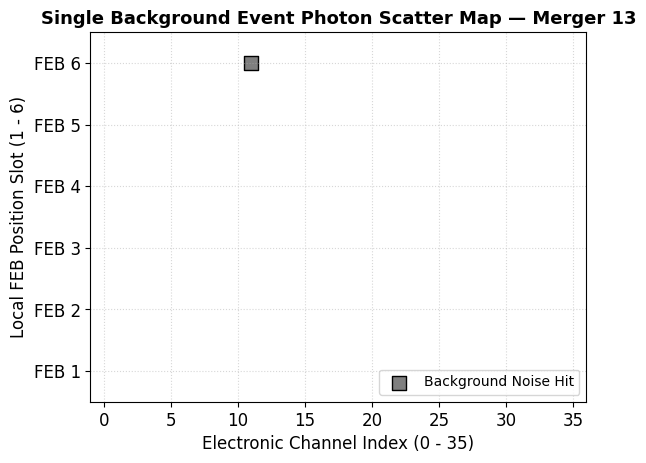

In [175]:
    plt.scatter(ch_ids_bg, lf_ids_bg, color='#7f7f7f', marker='s', s=100, label='Background Noise Hit', edgecolor='black')
    
    plt.xlabel('Electronic Channel Index (0 - 35)', fontsize=12)
    plt.ylabel('Local FEB Position Slot (1 - 6)', fontsize=12)
    plt.yticks(range(1, 7), [f'FEB {i}' for i in range(1, 7)])
    plt.title(f'Single Background Event Photon Scatter Map — Merger {TARGET_MERGER}', fontsize=13, fontweight='bold')
    plt.ylim(0.5, 6.5)
    plt.xlim(-1, 36)
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.legend(loc='lower right')
    plt.savefig('single_bg_event_scatter.png', dpi=300, bbox_inches='tight')
    plt.show()

In [116]:
from matplotlib.colors import LogNorm
X_raw = np.load('X_arich_input.npy', allow_pickle=True).reshape(-1, 24, 36)
Y_raw = np.load('Y_arich_labels.npy', allow_pickle=True)
signal_indices = np.where(Y_raw[:, 0] == 1)[0]
PIXEL_SIZE_MM = 5.0 
MIN_R, MAX_R = 4.0, 6.0
all_x_shifted = []
all_y_shifted = []
num_events = min(500, len(signal_indices))

In [117]:
for i in range(num_events):
    idx = signal_indices[i]
    event = X_raw[idx]
    y_indices, x_indices = np.where(event > 0)
    y_indices = y_indices.astype(np.int32)
    x_indices = x_indices.astype(np.int32)
    
    if len(x_indices) < 10: 
        continue
    best_score = 0
    best_center = (np.mean(x_indices), np.mean(y_indices)) 
    
    for cx in range(36):
        for cy in range(24):
            distances = np.sqrt((x_indices - cx)**2 + (y_indices - cy)**2)
            ring_hits = np.sum((distances >= MIN_R) & (distances <= MAX_R))
            if ring_hits > best_score:
                best_score = ring_hits
                best_center = (cx, cy)
                
    cx, cy = best_center
    
    distances = np.sqrt((x_indices - cx)**2 + (y_indices - cy)**2)
    ring_mask = distances > 2.0
    x_ring = x_indices[ring_mask]
    y_ring = y_indices[ring_mask]
    x_shifted = (x_ring.astype(np.float32) - float(cx)) * PIXEL_SIZE_MM
    y_shifted = (y_ring.astype(np.float32) - float(cy)) * PIXEL_SIZE_MM
    all_x_shifted.extend(x_shifted)
    all_y_shifted.extend(y_shifted)

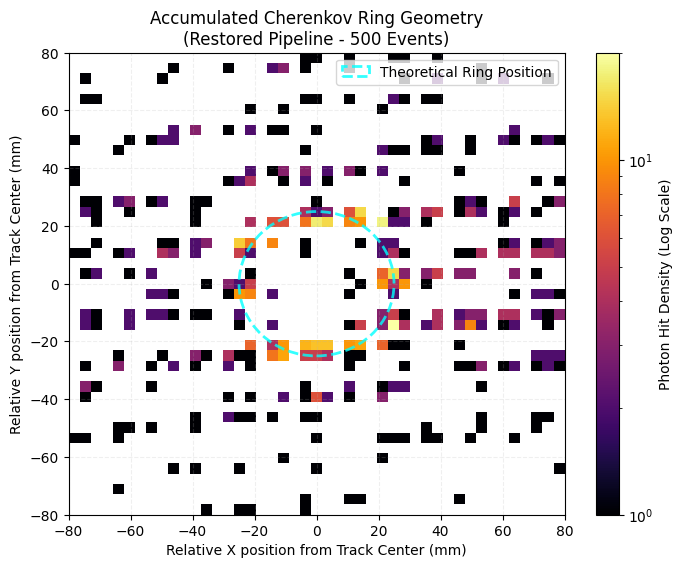

In [118]:
fig, ax = plt.subplots(figsize=(8, 6))
h = ax.hist2d(all_x_shifted, all_y_shifted, bins=45, range=[[-80, 80], [-80, 80]], 
              cmap='inferno', norm=LogNorm())
fig.colorbar(h[3], ax=ax, label='Photon Hit Density (Log Scale)')

circle = plt.Circle((0, 0), radius=25, color='cyan', fill=False, linestyle='--', lw=2, alpha=0.8, label='Theoretical Ring Position')
ax.add_patch(circle)

ax.set_title(f"Accumulated Cherenkov Ring Geometry\n(Restored Pipeline - 500 Events)")
ax.set_xlabel("Relative X position from Track Center (mm)")
ax.set_ylabel("Relative Y position from Track Center (mm)")
ax.grid(True, linestyle='--', alpha=0.2)
ax.legend(loc='upper right')

plt.show()

# MODEL DEVELOPMENT AND TRAINING

In [25]:
X_list = []
Y_list = []
n_events = sample.shape[0]

In [26]:
for idx in range(n_events):
    n_hits = int(sample[idx, 0, I_Nhit])
    if n_hits == 0: 
        continue
    
    hits = sample[idx, 0, I_hit_globalfebID:I_hit_globalfebID + (n_hits * 8)].reshape(n_hits, 8)
    m_hits = hits[hits[:, 2] == TARGET_MERGER]
    
    lf_id, ch_id = m_hits[:, 3].astype(int), m_hits[:, 1].astype(int)
    valid = (ch_id >= 0) & (ch_id < 36) & (lf_id >= 1) & (lf_id <= 6)
    if not np.any(valid): 
        continue
            
    lf_id, ch_id = lf_id[valid], ch_id[valid]
    
    g_row = ((lf_id - 1) * 4) + ((ch_id // 6) % 4)

    current_frame = np.zeros((24, 36), dtype=np.float32)
    current_frame[g_row, ch_id] = 1.0
    
    # Determine label (1.0 if any true signal flag is present)
    current_label = 1.0 if np.any(m_hits[valid, 4] > 0) else 0.0
    
    X_list.append(current_frame)
    Y_list.append([current_label])

In [27]:
X_clean = np.array(X_list, dtype=np.float32)
Y_clean = np.array(Y_list, dtype=np.float32)

real_signals_found = int(np.sum(Y_clean == 1.0))
print("--- Compilation Complete ---")
print(f"Total Active Events Kept: {X_clean.shape[0]}")
print(f"Signal Tracks: {real_signals_found}")
print(f"Background Noise Tracks: {X_clean.shape[0] - real_signals_found}")

--- Compilation Complete ---
Total Active Events Kept: 137154
Signal Tracks: 12858
Background Noise Tracks: 124296


In [28]:
from sklearn.model_selection import train_test_split
X_tv, X_test, y_tv, y_test = train_test_split(
    X_clean, Y_clean, 
    test_size=0.20, 
    random_state=42, 
    stratify=Y_clean
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, 
    test_size=0.20, 
    random_state=42, 
    stratify=y_tv
)

print(f"Train Dataset Shape: {X_train.shape} | Signal Tracks: {int(np.sum(y_train))}")
print(f"Val Dataset Shape:   {X_val.shape}  | Signal Tracks: {int(np.sum(y_val))}")
print(f"Test Dataset Shape:  {X_test.shape} | Signal Tracks: {int(np.sum(y_test))}")

Train Dataset Shape: (87778, 24, 36) | Signal Tracks: 8229
Val Dataset Shape:   (21945, 24, 36)  | Signal Tracks: 2057
Test Dataset Shape:  (27431, 24, 36) | Signal Tracks: 2572


In [ ]:
#TRAININGCALLBACKS

MODEL I FOR N >= 0 VERSION I

In [196]:
import tensorflow as tf
from tensorflow.keras.layers import Input, BatchNormalization, MaxPooling2D, Flatten, Reshape, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from qkeras import QConv2D, QActivation, QDense, quantized_bits
import tensorflow.keras.backend as K
import numpy as np

In [197]:

def bulletproof_cast_to_floatx(x):
    if tf.is_tensor(x):
        return tf.cast(x, K.floatx())
    else:
        return np.asarray(x, dtype=K.floatx())
K.cast_to_floatx = bulletproof_cast_to_floatx

In [198]:
W_Q = quantized_bits(8, 2, alpha=1)
A_Q = "quantized_relu(8,2)"

inputs = Input(shape=(24, 36))
x = Reshape((24, 36, 1))(inputs)

In [199]:
x = QConv2D(64, kernel_size=(3,3), padding="same", kernel_quantizer=W_Q, use_bias=False)(x)
x = BatchNormalization()(x)
x = QActivation(A_Q)(x)
x = MaxPooling2D(pool_size=(2, 2))(x)

In [200]:
x = QConv2D(64, kernel_size=(3,3), padding="same", kernel_quantizer=W_Q, use_bias=False)(x)
x = BatchNormalization()(x)
x = QActivation(A_Q)(x)
x = MaxPooling2D(pool_size=(2, 2))(x)

x = Flatten()(x)

In [208]:
x = QDense(64, kernel_quantizer=W_Q, use_bias=False)(x)
x = BatchNormalization()(x)
x = QActivation(A_Q)(x)
x = Dropout(0.3)(x)

In [209]:
outputs = QDense(1, activation="sigmoid", kernel_quantizer=W_Q, use_bias=False)(x)

model_max = tf.keras.Model(inputs=inputs, outputs=outputs)


In [216]:
loss_function = tf.keras.losses.BinaryFocalCrossentropy(
    alpha=0.85,
    gamma=2.0,
    from_logits=False
)

In [217]:
lr_reducer = ReduceLROnPlateau(
    monitor='val_roc_auc', 
    mode='max',
    factor=0.5, 
    patience=3, 
    min_lr=1e-7,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_maxout_qkeras_model.h5',
    monitor='val_roc_auc',
    mode='max',
    save_best_only=True,
    verbose=1
)

In [219]:
early_stopping = EarlyStopping(
    monitor='val_roc_auc',
    mode='max',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

focal_loss = tf.keras.losses.BinaryFocalCrossentropy(
    alpha=0.85,
    gamma=2.0,
    from_logits=False
)

model_max.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=focal_loss, 
    run_eagerly=False,
    metrics=[tf.keras.metrics.AUC(name='roc_auc')]
)

In [220]:
history_max = model_max.fit(
    X_train, y_train, 
    validation_data=(X_val, y_val),
    epochs=35, 
    batch_size=256, 
    # We do NOT use class_weights here because Focal Loss handles the imbalance dynamically!
    callbacks=[lr_reducer, checkpoint, early_stopping]
)

print("Max-Out Training Complete!")

Epoch 1/35
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - loss: 0.1791 - roc_auc: 0.7026
Epoch 1: val_roc_auc improved from None to 0.85942, saving model to best_maxout_qkeras_model.h5


343/343 ━━━━━━━━━━━━━━━━━━━━ 49s 140ms/step - loss: 0.1101 - roc_auc: 0.7465 - val_loss: 0.0610 - val_roc_auc: 0.8594 - learning_rate: 0.0010
Epoch 2/35
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - loss: 0.0670 - roc_auc: 0.8327
Epoch 2: val_roc_auc improved from 0.85942 to 0.86578, saving model to best_maxout_qkeras_model.h5


343/343 ━━━━━━━━━━━━━━━━━━━━ 48s 139ms/step - loss: 0.0664 - roc_auc: 0.8388 - val_loss: 0.0611 - val_roc_auc: 0.8658 - learning_rate: 0.0010
Epoch 3/35
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - loss: 0.0625 - roc_auc: 0.8531
Epoch 3: val_roc_auc improved from 0.86578 to 0.86719, saving model to best_maxout_qkeras_model.h5


343/343 ━━━━━━━━━━━━━━━━━━━━ 48s 139ms/step - loss: 0.0628 - roc_auc: 0.8526 - val_loss: 0.0596 - val_roc_auc: 0.8672 - learning_rate: 0.0010
Epoch 4/35
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - loss: 0.0615 - roc_auc: 0.8585
Epoch 4: val_roc_auc improved from 0.86719 to 0.87003, saving model to best_maxout_qkeras_model.h5


343/343 ━━━━━━━━━━━━━━━━━━━━ 48s 139ms/step - loss: 0.0616 - roc_auc: 0.8579 - val_loss: 0.0592 - val_roc_auc: 0.8700 - learning_rate: 0.0010
Epoch 5/35
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - loss: 0.0606 - roc_auc: 0.8641
Epoch 5: val_roc_auc did not improve from 0.87003
343/343 ━━━━━━━━━━━━━━━━━━━━ 48s 139ms/step - loss: 0.0606 - roc_auc: 0.8615 - val_loss: 0.0589 - val_roc_auc: 0.8693 - learning_rate: 0.0010
Epoch 6/35
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - loss: 0.0602 - roc_auc: 0.8624
Epoch 6: val_roc_auc improved from 0.87003 to 0.87175, saving model to best_maxout_qkeras_model.h5


...

343/343 ━━━━━━━━━━━━━━━━━━━━ 50s 146ms/step - loss: 0.0592 - roc_auc: 0.8671 - val_loss: 0.0584 - val_roc_auc: 0.8732 - learning_rate: 0.0010
Epoch 9/35
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - loss: 0.0590 - roc_auc: 0.8659
Epoch 9: val_roc_auc improved from 0.87318 to 0.87338, saving model to best_maxout_qkeras_model.h5


343/343 ━━━━━━━━━━━━━━━━━━━━ 48s 141ms/step - loss: 0.0589 - roc_auc: 0.8686 - val_loss: 0.0582 - val_roc_auc: 0.8734 - learning_rate: 0.0010
Epoch 10/35
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - loss: 0.0587 - roc_auc: 0.8718
Epoch 10: val_roc_auc did not improve from 0.87338
343/343 ━━━━━━━━━━━━━━━━━━━━ 48s 140ms/step - loss: 0.0586 - roc_auc: 0.8701 - val_loss: 0.0581 - val_roc_auc: 0.8729 - learning_rate: 0.0010
Epoch 11/35
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - loss: 0.0580 - roc_auc: 0.8719
Epoch 11: val_roc_auc did not improve from 0.87338
343/343 ━━━━━━━━━━━━━━━━━━━━ 48s 140ms/step - loss: 0.0584 - roc_auc: 0.8710 - val_loss: 0.0581 - val_roc_auc: 0.8733 - learning_rate: 0.0010
Epoch 12/35
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - loss: 0.0580 - roc_auc: 0.8730
Epoch 12: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 12: val_roc_auc did not improve from 0.87338
343/343 ━━━━━━━━━━━━━━━━━━━━ 48s 140ms/step - loss: 0.0580 - roc_auc: 0.8725 - 

343/343 ━━━━━━━━━━━━━━━━━━━━ 48s 140ms/step - loss: 0.0571 - roc_auc: 0.8770 - val_loss: 0.0580 - val_roc_auc: 0.8734 - learning_rate: 5.0000e-04
Epoch 15/35
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - loss: 0.0562 - roc_auc: 0.8795
Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 15: val_roc_auc did not improve from 0.87342
343/343 ━━━━━━━━━━━━━━━━━━━━ 48s 140ms/step - loss: 0.0570 - roc_auc: 0.8775 - val_loss: 0.0584 - val_roc_auc: 0.8711 - learning_rate: 5.0000e-04
Epoch 16/35
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - loss: 0.0562 - roc_auc: 0.8793
Epoch 16: val_roc_auc improved from 0.87342 to 0.87459, saving model to best_maxout_qkeras_model.h5


343/343 ━━━━━━━━━━━━━━━━━━━━ 48s 140ms/step - loss: 0.0566 - roc_auc: 0.8791 - val_loss: 0.0579 - val_roc_auc: 0.8746 - learning_rate: 2.5000e-04
Epoch 17/35
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - loss: 0.0565 - roc_auc: 0.8813
Epoch 17: val_roc_auc did not improve from 0.87459
343/343 ━━━━━━━━━━━━━━━━━━━━ 48s 139ms/step - loss: 0.0561 - roc_auc: 0.8814 - val_loss: 0.0580 - val_roc_auc: 0.8742 - learning_rate: 2.5000e-04
Epoch 18/35
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - loss: 0.0564 - roc_auc: 0.8813
Epoch 18: val_roc_auc improved from 0.87459 to 0.87469, saving model to best_maxout_qkeras_model.h5


343/343 ━━━━━━━━━━━━━━━━━━━━ 48s 140ms/step - loss: 0.0562 - roc_auc: 0.8807 - val_loss: 0.0578 - val_roc_auc: 0.8747 - learning_rate: 2.5000e-04
Epoch 19/35
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - loss: 0.0564 - roc_auc: 0.8811
Epoch 19: val_roc_auc did not improve from 0.87469
343/343 ━━━━━━━━━━━━━━━━━━━━ 48s 140ms/step - loss: 0.0559 - roc_auc: 0.8825 - val_loss: 0.0582 - val_roc_auc: 0.8725 - learning_rate: 2.5000e-04
Epoch 20/35
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - loss: 0.0557 - roc_auc: 0.8850
Epoch 20: val_roc_auc did not improve from 0.87469
343/343 ━━━━━━━━━━━━━━━━━━━━ 48s 140ms/step - loss: 0.0559 - roc_auc: 0.8827 - val_loss: 0.0581 - val_roc_auc: 0.8734 - learning_rate: 2.5000e-04
Epoch 21/35
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - loss: 0.0556 - roc_auc: 0.8841
Epoch 21: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 21: val_roc_auc did not improve from 0.87469
343/343 ━━━━━━━━━━━━━━━━━━━━ 48s 140ms/step - loss: 0.0555 - roc_au

In [221]:
from sklearn.metrics import roc_curve, auc, classification_report

In [222]:

y_test_preds = model_max.predict(X_test).ravel()  # .ravel() flattens it for the ROC curve

# 2. Import tools and calculate metrics
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_test_preds)
final_roc_auc = auc(fpr, tpr)

print(f"✅ Evaluation Complete! Final ROC AUC: {final_roc_auc:.4f}")

858/858 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step
✅ Evaluation Complete! Final ROC AUC: 0.8657


In [223]:
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(f"Optimal Index: {optimal_idx}")
print(f"Optimal Hardware Threshold: {optimal_threshold:.4f}")

Optimal Index: 2054
Optimal Hardware Threshold: 0.2865


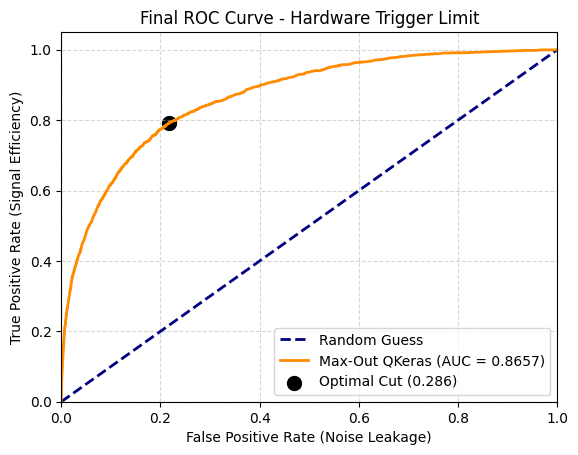

In [224]:
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')

plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Max-Out QKeras (AUC = {final_roc_auc:.4f})')

plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color='black', marker='o', s=100,
            label=f'Optimal Cut ({optimal_threshold:.3f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Noise Leakage)')
plt.ylabel('True Positive Rate (Signal Efficiency)')
plt.title('Final ROC Curve - Hardware Trigger Limit')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [319]:
import seaborn as sns
from sklearn.metrics import roc_curve, precision_recall_curve, auc, confusion_matrix, average_precision_score

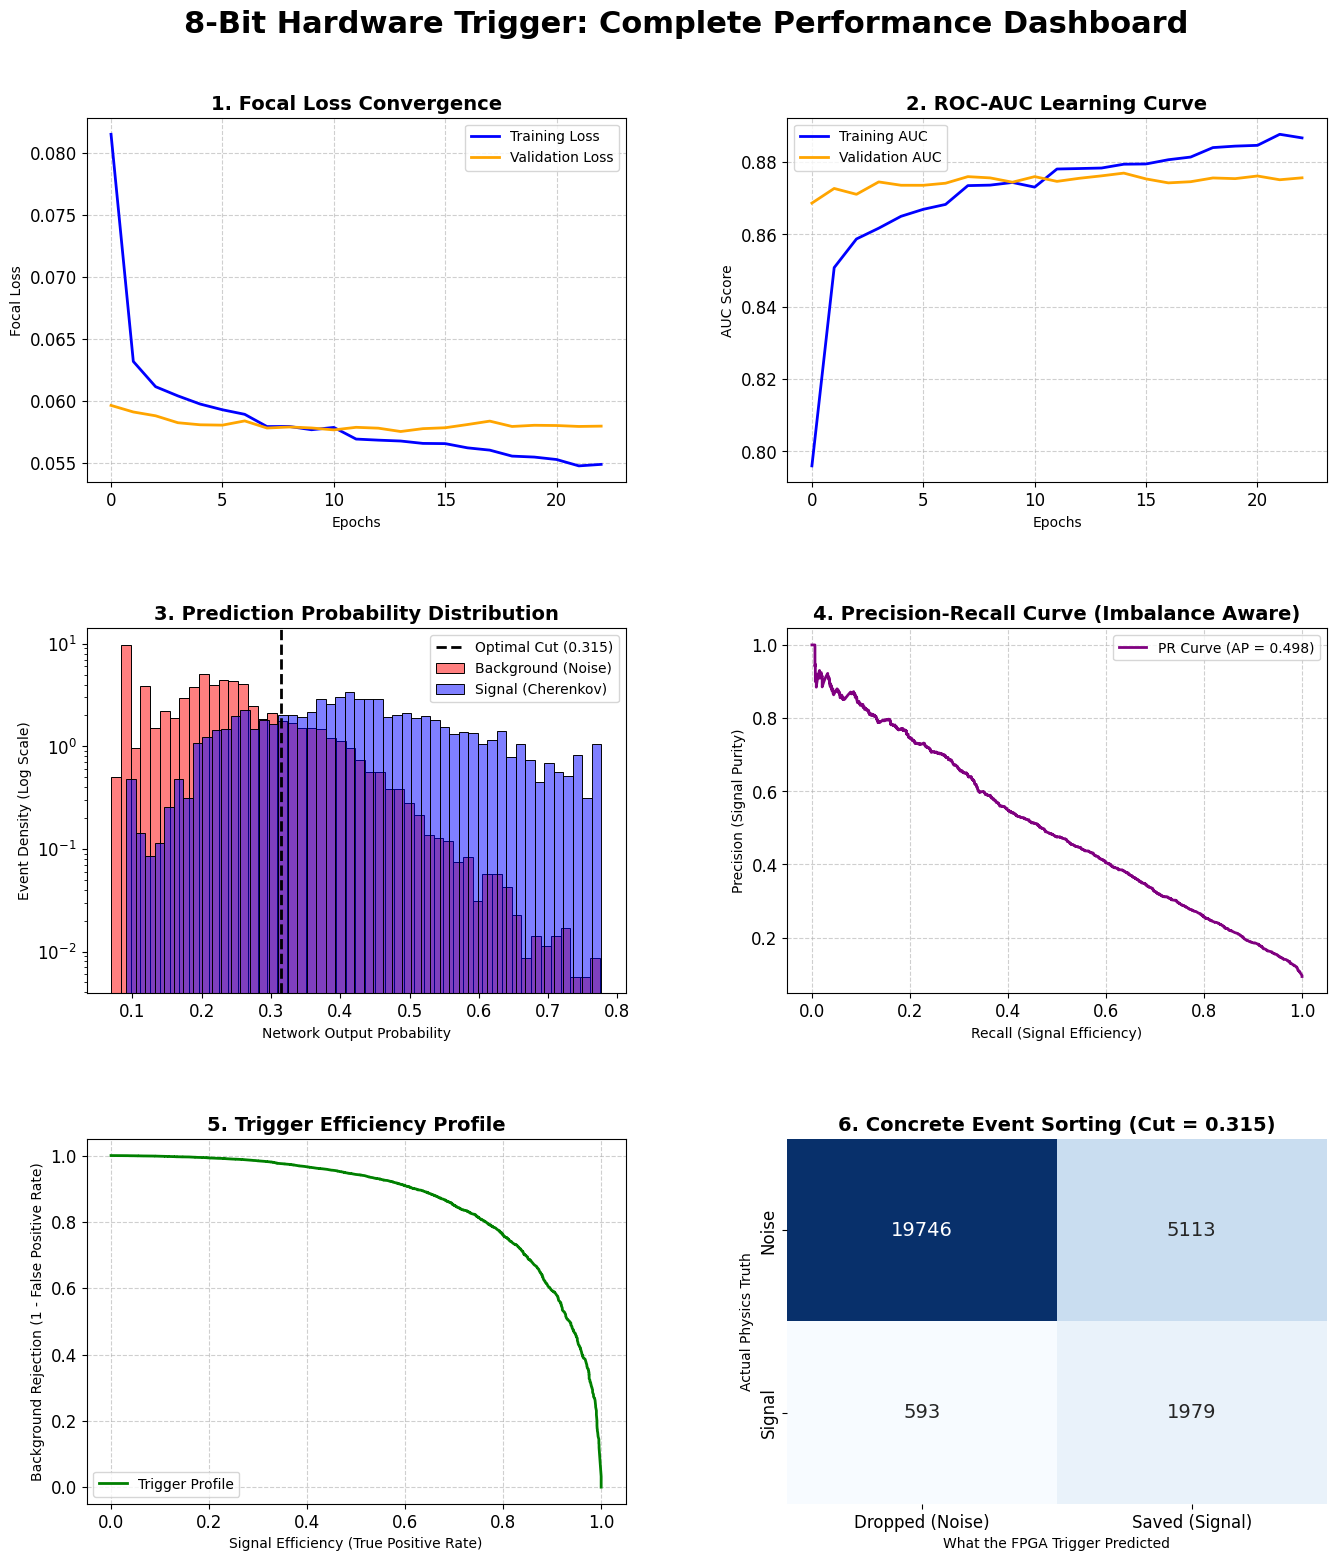

In [329]:
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.subplots_adjust(hspace=0.4, wspace=0.3)

axes[0, 0].plot(history_max.history['loss'], label='Training Loss', color='blue', lw=2)
axes[0, 0].plot(history_max.history['val_loss'], label='Validation Loss', color='orange', lw=2)
axes[0, 0].set_title('1. Focal Loss Convergence', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epochs')
axes[0, 0].set_ylabel('Focal Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, linestyle='--', alpha=0.6)


axes[0, 1].plot(history_max.history['roc_auc'], label='Training AUC', color='blue', lw=2)
axes[0, 1].plot(history_max.history['val_roc_auc'], label='Validation AUC', color='orange', lw=2)
axes[0, 1].set_title('2. ROC-AUC Learning Curve', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epochs')
axes[0, 1].set_ylabel('AUC Score')
axes[0, 1].legend()
axes[0, 1].grid(True, linestyle='--', alpha=0.6)


sns.histplot(y_test_preds[y_test == 0], bins=50, color='red', alpha=0.5, label='Background (Noise)', ax=axes[1, 0], stat='density')
sns.histplot(y_test_preds[y_test == 1], bins=50, color='blue', alpha=0.5, label='Signal (Cherenkov)', ax=axes[1, 0], stat='density')
axes[1, 0].set_yscale('log')
axes[1, 0].set_title('3. Prediction Probability Distribution', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Network Output Probability')
axes[1, 0].set_ylabel('Event Density (Log Scale)')
axes[1, 0].axvline(0.315, color='black', linestyle='dashed', lw=2, label='Optimal Cut (0.315)')
axes[1, 0].legend()


precision, recall, _ = precision_recall_curve(y_test, y_test_preds)
ap_score = average_precision_score(y_test, y_test_preds)
axes[1, 1].plot(recall, precision, color='purple', lw=2, label=f'PR Curve (AP = {ap_score:.3f})')
axes[1, 1].set_title('4. Precision-Recall Curve (Imbalance Aware)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Recall (Signal Efficiency)')
axes[1, 1].set_ylabel('Precision (Signal Purity)')
axes[1, 1].legend()
axes[1, 1].grid(True, linestyle='--', alpha=0.6)

fpr, tpr, _ = roc_curve(y_test, y_test_preds)
bkg_rejection = 1 - fpr
axes[2, 0].plot(tpr, bkg_rejection, color='green', lw=2, label='Trigger Profile')
axes[2, 0].set_title('5. Trigger Efficiency Profile', fontsize=14, fontweight='bold')
axes[2, 0].set_xlabel('Signal Efficiency (True Positive Rate)')
axes[2, 0].set_ylabel('Background Rejection (1 - False Positive Rate)')
axes[2, 0].legend(loc='lower left')
axes[2, 0].grid(True, linestyle='--', alpha=0.6)

optimal_thresh = 0.315
y_pred_opt = (y_test_preds > optimal_thresh).astype(int)
cm = confusion_matrix(y_test, y_pred_opt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2, 1], cbar=False, annot_kws={'size': 14})
axes[2, 1].set_title(f'6. Concrete Event Sorting (Cut = {optimal_thresh})', fontsize=14, fontweight='bold')
axes[2, 1].set_xlabel('What the FPGA Trigger Predicted')
axes[2, 1].set_ylabel('Actual Physics Truth')
axes[2, 1].set_xticklabels(['Dropped (Noise)', 'Saved (Signal)'])
axes[2, 1].set_yticklabels(['Noise', 'Signal'])

plt.suptitle('8-Bit Hardware Trigger: Complete Performance Dashboard', fontsize=22, fontweight='bold', y=0.94)

plt.show()

HIGH-SPEED 5-HIT MINIMUM THRESHOLD

In [47]:

MIN_HITS = 5  
n_events = sample.shape[0]

In [51]:
X_buffer = np.zeros((n_events, 24, 36), dtype=np.float32)
Y_buffer = np.zeros((n_events, 1), dtype=np.float32)

kept_count = 0 

In [52]:
for idx in range(n_events):
    n_hits = int(sample[idx, 0, I_Nhit])
    if n_hits == 0:
        continue

    hits = sample[idx, 0, I_hit_globalfebID:I_hit_globalfebID + (n_hits * 8)].reshape(n_hits, 8)
    m_hits = hits[hits[:, 2] == TARGET_MERGER]

    lf_id, ch_id = m_hits[:, 3].astype(int), m_hits[:, 1].astype(int)
    valid = (ch_id >= 0) & (ch_id < 36) & (lf_id >= 1) & (lf_id <= 6)
    
    if not np.any(valid):
        continue

    lf_id, ch_id = lf_id[valid], ch_id[valid]
    
    total_valid_hits = np.sum(valid)
    true_track_hits = np.sum(m_hits[valid, 4] > 0)

    if true_track_hits >= MIN_HITS:
        Y_buffer[kept_count, 0] = 1.0
    elif (true_track_hits == 0) and (total_valid_hits >= MIN_HITS):
        Y_buffer[kept_count, 0] = 0.0
    else:
        continue  

    g_row = ((lf_id - 1) * 4) + ((ch_id // 6) % 4)
    X_buffer[kept_count, g_row, ch_id] = 1.0
    
    kept_count += 1

In [53]:
X_clean = X_buffer[:kept_count]
Y_clean = Y_buffer[:kept_count]

real_signals_found = int(np.sum(Y_clean == 1.0))
print(f"Total Valid Events Kept: {X_clean.shape[0]}")
print(f"Signal Tracks (>= 5 true hits): {real_signals_found}")
print(f"Background Noise (>= 5 total hits): {X_clean.shape[0] - real_signals_found}")

Total Valid Events Kept: 15561
Signal Tracks (>= 5 true hits): 5331
Background Noise (>= 5 total hits): 10230


In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, Y_clean, test_size=0.2, random_state=42, stratify=Y_clean
)

X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

print("--- DATA PREPARATION COMPLETE ---")
print(f"Training Set : {X_train.shape[0]} events")
print(f"Testing Set  : {X_test.shape[0]} events")

--- DATA PREPARATION COMPLETE ---
Training Set : 12448 events
Testing Set  : 3113 events


In [163]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [136]:
model_max.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', 'AUC'] # Keeps uppercase AUC
)

early_stop_fixed = EarlyStopping(
    monitor='val_AUC', 
    patience=5, 
    restore_best_weights=True,
    mode='max'
)

In [137]:
history_fixed = model_max.fit(
    X_train, y_train,
    epochs=25,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stop_fixed],
    verbose=1
)

Epoch 1/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - AUC: 0.9959 - accuracy: 0.9710 - loss: 0.0782 - val_AUC: 0.7432 - val_accuracy: 0.7430 - val_loss: 1.2041
Epoch 2/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - AUC: 0.9962 - accuracy: 0.9722 - loss: 0.0757 - val_AUC: 0.7458 - val_accuracy: 0.7472 - val_loss: 1.1291
Epoch 3/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - AUC: 0.9964 - accuracy: 0.9736 - loss: 0.0728 - val_AUC: 0.7489 - val_accuracy: 0.7488 - val_loss: 1.1753
Epoch 4/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - AUC: 0.9961 - accuracy: 0.9723 - loss: 0.0760 - val_AUC: 0.7455 - val_accuracy: 0.7514 - val_loss: 1.2721
Epoch 5/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - AUC: 0.9962 - accuracy: 0.9717 - loss: 0.0747 - val_AUC: 0.7476 - val_accuracy: 0.7520 - val_loss: 1.1481
Epoch 6/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - AUC: 0.9965 - accuracy: 0.9728 - loss: 0.0714 - val_AUC: 0.7463 - val_accuracy: 0.7144 - val_loss: 1.0317
Epoch 7/25
195/195 ━━━━━━━━━━━━━━━

In [138]:
y_pred_prob_5 = model_max.predict(X_test).flatten()
auc_score_5 = roc_auc_score(y_test, y_pred_prob_5)
fpr_5, tpr_5, thresholds_5 = roc_curve(y_test, y_pred_prob_5)

opt_idx_5 = np.argmax(tpr_5 - fpr_5)
opt_thresh_5 = thresholds_5[opt_idx_5]

98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


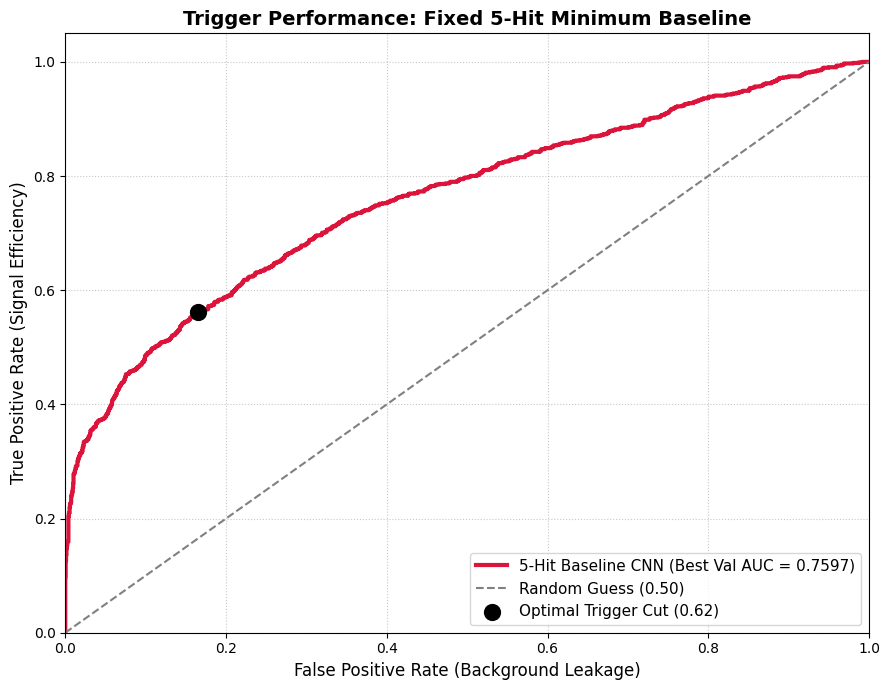

Calculated 5-Hit Test AUC: 0.7597
Suggested Trigger Threshold: 0.62


In [139]:
plt.figure(figsize=(9, 7))
plt.plot(fpr_5, tpr_5, color='crimson', lw=3, 
         label=f'5-Hit Baseline CNN (Best Val AUC = {auc_score_5:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random Guess (0.50)')
plt.scatter(fpr_5[opt_idx_5], tpr_5[opt_idx_5], color='black', marker='o', s=130, zorder=5,
            label=f'Optimal Trigger Cut ({opt_thresh_5:.2f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Background Leakage)', fontsize=12)
plt.ylabel('True Positive Rate (Signal Efficiency)', fontsize=12)
plt.title('Trigger Performance: Fixed 5-Hit Minimum Baseline', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()

plt.savefig('5hit_baseline_fixed_roc.png', dpi=300)
plt.show()

print(f"Calculated 5-Hit Test AUC: {auc_score_5:.4f}")
print(f"Suggested Trigger Threshold: {opt_thresh_5:.2f}")

MODEL II-I FOR N 5 version II

In [72]:
total = 15561
pos = 5331
neg = 10230

In [73]:
weight_for_0 = (1 / neg) * (total / 2.0)
weight_for_1 = (1 / pos) * (total / 2.0)
class_weights = {0: weight_for_0, 1: weight_for_1}

print(f"Weight for Background (0): {weight_for_0:.2f}")
print(f"Weight for Signal (1): {weight_for_1:.2f}")

Weight for Background (0): 0.76
Weight for Signal (1): 1.46


In [74]:
strong_model = build_strong_model()
strong_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

history = strong_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, lr_reduction],
    class_weight=class_weights,  # <--- This is the magic key now
    verbose=1
)

Epoch 1/30


/home/nahom338/.local/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.6680 - auc: 0.7246 - loss: 0.6516 - val_accuracy: 0.6579 - val_auc: 0.7501 - val_loss: 0.9364 - learning_rate: 0.0010
Epoch 2/30
195/195 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.7108 - auc: 0.7781 - loss: 0.5663 - val_accuracy: 0.7253 - val_auc: 0.7583 - val_loss: 0.6545 - learning_rate: 0.0010
Epoch 3/30
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.7232 - auc: 0.7912 - loss: 0.5529 - val_accuracy: 0.7494 - val_auc: 0.7782 - val_loss: 0.5253 - learning_rate: 0.0010
Epoch 4/30
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7286 - auc: 0.8024 - loss: 0.5395
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.7306 - auc: 0.8025 - loss: 0.5413 - val_accuracy: 0.7501 - val_auc: 0.7774 - val_loss: 0.5249 - learning_rate: 0.0010
Epoch 5/30
195/195 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.7537 - auc: 0.8257 - loss: 0.5152 - va

In [75]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
RESULTS
y_pred_prob = strong_model.predict(X_test)
test_roc_auc = roc_auc_score(y_test, y_pred_prob)
y_pred_binary = (y_pred_prob > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred_binary)

print(f"Test ROC AUC Score: {test_roc_auc:.4f}\n")
print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred_binary, target_names=['Background (0)', 'Signal (1)']))
print("=== CONFUSION MATRIX ===")
print(f"True Negatives (Background correctly ignored) : {cm[0][0]}")
print(f"False Positives (Noise falsely triggered)     : {cm[0][1]}")
print(f"False Negatives (Real signal missed)          : {cm[1][0]}")
print(f"True Positives (Real signal triggered)        : {cm[1][1]}")


98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Test ROC AUC Score: 0.7790

=== CLASSIFICATION REPORT ===
                precision    recall  f1-score   support

Background (0)       0.81      0.72      0.77      2047
    Signal (1)       0.56      0.67      0.61      1066

      accuracy                           0.71      3113
     macro avg       0.69      0.70      0.69      3113
  weighted avg       0.72      0.71      0.71      3113

=== CONFUSION MATRIX ===
True Negatives (Background correctly ignored) : 1483
False Positives (Noise falsely triggered)     : 564
False Negatives (Real signal missed)          : 347
True Positives (Real signal triggered)        : 719


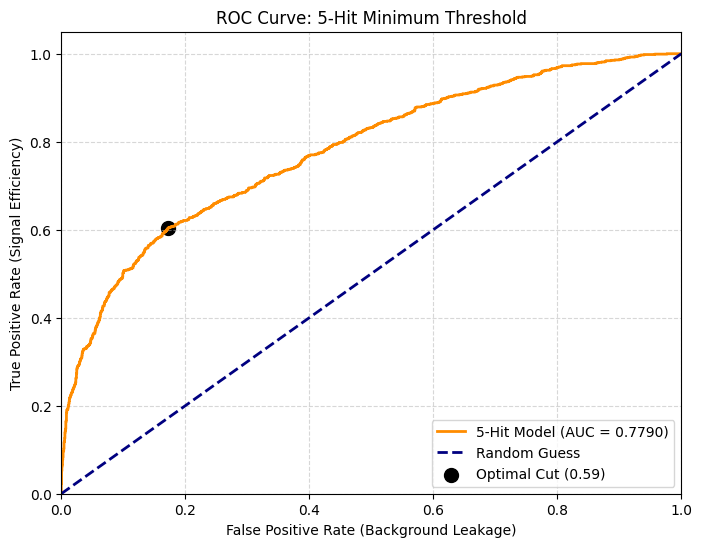

In [76]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'5-Hit Model (AUC = {test_roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')

plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color='black', marker='o', s=100, 
            label=f'Optimal Cut ({optimal_threshold:.2f})')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Background Leakage)')
plt.ylabel('True Positive Rate (Signal Efficiency)')
plt.title('ROC Curve: 5-Hit Minimum Threshold')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

MODEL 3 for N 10 Version I

In [36]:
MIN_HITS = 10  
n_events = sample.shape[0]

X_buffer = np.zeros((n_events, 24, 36), dtype=np.float32)
Y_buffer = np.zeros((n_events, 1), dtype=np.float32)
kept_count = 0 

In [37]:
for idx in range(n_events):
    n_hits = int(sample[idx, 0, I_Nhit])
    if n_hits == 0:
        continue

    hits = sample[idx, 0, I_hit_globalfebID:I_hit_globalfebID + (n_hits * 8)].reshape(n_hits, 8)
    m_hits = hits[hits[:, 2] == TARGET_MERGER]

    lf_id, ch_id = m_hits[:, 3].astype(int), m_hits[:, 1].astype(int)
    valid = (ch_id >= 0) & (ch_id < 36) & (lf_id >= 1) & (lf_id <= 6)
    
    if not np.any(valid):
        continue

    lf_id, ch_id = lf_id[valid], ch_id[valid]
    
    total_valid_hits = np.sum(valid)
    true_track_hits = np.sum(m_hits[valid, 4] > 0)
    
    # 10-Hit Physics Logic
    if true_track_hits >= MIN_HITS:
        Y_buffer[kept_count, 0] = 1.0
    elif (true_track_hits == 0) and (total_valid_hits >= MIN_HITS):
        Y_buffer[kept_count, 0] = 0.0
    else:
        continue  

    # Fast Vectorized Mapping
    g_row = ((lf_id - 1) * 4) + ((ch_id // 6) % 4)
    X_buffer[kept_count, g_row, ch_id] = 1.0
    
    kept_count += 1

In [55]:
X_clean_10 = X_buffer[:kept_count]
Y_clean_10 = Y_buffer[:kept_count]

real_signals_found_10 = int(np.sum(Y_clean_10 == 1.0))
print(f"Total Valid Events Kept: {X_clean_10.shape[0]}")
print(f"Signal Tracks (>= 10 true hits): {real_signals_found_10}")
print(f"Background Noise (>= 10 total hits): {X_clean_10.shape[0] - real_signals_found_10}")

Total Valid Events Kept: 15561
Signal Tracks (>= 10 true hits): 5331
Background Noise (>= 10 total hits): 10230


In [160]:
from tensorflow.keras.layers import Input, Conv2D, SeparableConv2D, BatchNormalization, Activation, Add, MaxPooling2D, GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model

In [161]:
def build_advanced_residual_model():
    inputs = Input(shape=(24, 36, 1))
    x = Conv2D(16, (3, 3), padding='same', use_bias=False)(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((2, 2))(x)
    residual = x 
    x = SeparableConv2D(16, (3, 3), padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SeparableConv2D(16, (3, 3), padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Add()([x, residual]) 
    x = Activation('relu')(x)
    x = MaxPooling2D((2, 2))(x) # Drops shape down to (6, 9, 16)
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.4)(x)
    outputs = Dense(1, activation='sigmoid')(x)
    return Model(inputs, outputs)

In [99]:
advanced_model = build_advanced_residual_model()
advanced_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

In [100]:
early_stop = EarlyStopping(monitor='val_auc', patience=8, restore_best_weights=True, mode='max', verbose=1)
lr_reduction = ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=4, min_lr=0.00001, mode='max', verbose=1)

print("--- LAUNCHING ADVANCED RESIDUAL TRAINING ---")
history_adv = advanced_model.fit(
    X_train_10, y_train_10,
    epochs=50,
    batch_size=32, # Smaller batch size to force it to look closer at individual rare rings
    validation_data=(X_test_10, y_test_10),
    callbacks=[early_stop, lr_reduction],
    class_weight=class_weights_10,
    verbose=1
)

--- LAUNCHING ADVANCED RESIDUAL TRAINING ---
Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5382 - auc: 0.5461 - loss: 0.8761 - val_accuracy: 0.4220 - val_auc: 0.3723 - val_loss: 0.7049 - learning_rate: 5.0000e-04
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5917 - auc: 0.6256 - loss: 0.7434 - val_accuracy: 0.4220 - val_auc: 0.6923 - val_loss: 0.7634 - learning_rate: 5.0000e-04
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6193 - auc: 0.6647 - loss: 0.6762 - val_accuracy: 0.4220 - val_auc: 0.8045 - val_loss: 0.9287 - learning_rate: 5.0000e-04
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6350 - auc: 0.6867 - loss: 0.6547 - val_accuracy: 0.4220 - val_auc: 0.8120 - val_loss: 1.0682 - learning_rate: 5.0000e-04
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6331 - auc: 0.7048 - loss: 0.6339 - val_accuracy: 0.4252 - val_auc: 0.8147 - val_loss: 1.0522 - learning_rate: 5.0000e-04
Epoch 6/50
80/80 ━━━

In [101]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
y_pred_prob_10 = advanced_model.predict(X_test_10)
test_roc_auc_10 = roc_auc_score(y_test_10, y_pred_prob_10)
print(f"10-Hit Advanced Model Test ROC AUC Score: {test_roc_auc_10:.4f}\n")
y_pred_binary_10 = (y_pred_prob_10 > 0.5).astype(int)
print("=== CLASSIFICATION REPORT (10-HIT ADVANCED) ===")
print(classification_report(y_test_10, y_pred_binary_10, target_names=['Background (0)', 'Signal (1)']))
print("=== CONFUSION MATRIX ===")
print(f"True Negatives (Background correctly ignored) : {cm_10[0][0]}")
print(f"False Positives (Noise falsely triggered)     : {cm_10[0][1]}")
print(f"False Negatives (Real signal missed)          : {cm_10[1][0]}")
print(f"True Positives (Real signal triggered)        : {cm_10[1][1]}\n")
fpr_10, tpr_10, thresholds_10 = roc_curve(y_test_10, y_pred_prob_10)
optimal_idx_10 = np.argmax(tpr_10 - fpr_10)
optimal_threshold_10 = thresholds_10[optimal_idx_10]

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
10-Hit Advanced Model Test ROC AUC Score: 0.8148

=== CLASSIFICATION REPORT (10-HIT ADVANCED) ===
                precision    recall  f1-score   support

Background (0)       0.43      1.00      0.60       268
    Signal (1)       1.00      0.05      0.09       367

      accuracy                           0.45       635
     macro avg       0.72      0.52      0.35       635
  weighted avg       0.76      0.45      0.31       635

=== CONFUSION MATRIX ===
True Negatives (Background correctly ignored) : 215
False Positives (Noise falsely triggered)     : 53
False Negatives (Real signal missed)          : 128
True Positives (Real signal triggered)        : 239



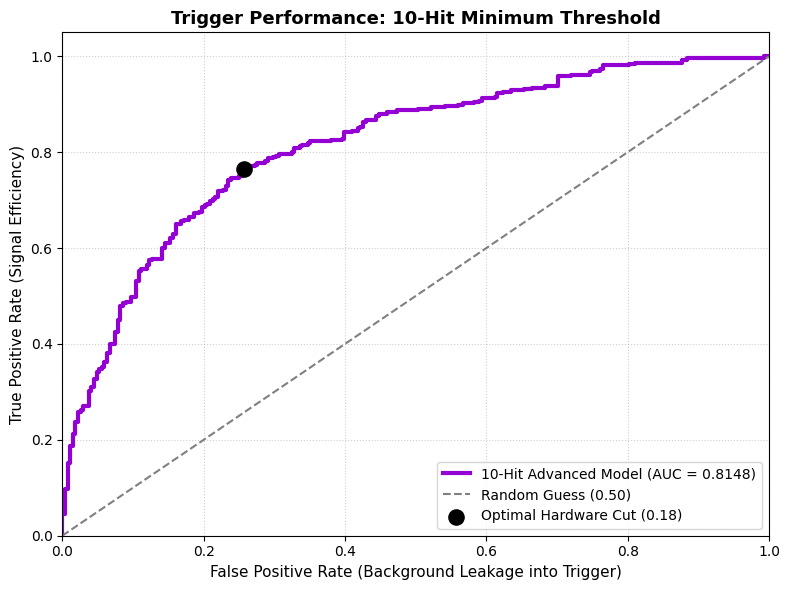

Optimal hardware trigger threshold for this model is: 0.179


In [102]:
plt.figure(figsize=(8, 6))
plt.plot(fpr_10, tpr_10, color='darkviolet', lw=3, 
         label=f'10-Hit Advanced Model (AUC = {test_roc_auc_10:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random Guess (0.50)')
plt.scatter(fpr_10[optimal_idx_10], tpr_10[optimal_idx_10], color='black', marker='o', s=120, zorder=5,
            label=f'Optimal Hardware Cut ({optimal_threshold_10:.2f})')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Background Leakage into Trigger)', fontsize=11)
plt.ylabel('True Positive Rate (Signal Efficiency)', fontsize=11)
plt.title('Trigger Performance: 10-Hit Minimum Threshold', fontsize=13, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('10_hit_advanced_roc_curve.png', dpi=300)
plt.show()

print(f"Optimal hardware trigger threshold for this model is: {optimal_threshold_10:.3f}")

MODEL II for N >= 10 VERSION II 

In [164]:
focal_model = build_advanced_residual_model()
focal_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss=tf.keras.losses.BinaryFocalCrossentropy(
        gamma=3.0, 
        apply_class_balancing=False
    ),
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

In [105]:
early_stop_focal = EarlyStopping(monitor='val_auc', patience=10, restore_best_weights=True, mode='max', verbose=1)
lr_reduction_focal = ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=4, min_lr=0.00001, mode='max', verbose=1)

history_focal = focal_model.fit(
    X_train_10, y_train_10,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_10, y_test_10),
    callbacks=[early_stop_focal, lr_reduction_focal],
    class_weight=class_weights_10,
    verbose=1
)

Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.5094 - auc: 0.5078 - loss: 0.4183 - val_accuracy: 0.5780 - val_auc: 0.5560 - val_loss: 0.0857 - learning_rate: 5.0000e-04
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5283 - auc: 0.5350 - loss: 0.2953 - val_accuracy: 0.4331 - val_auc: 0.6377 - val_loss: 0.0873 - learning_rate: 5.0000e-04
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5307 - auc: 0.5515 - loss: 0.2073 - val_accuracy: 0.4315 - val_auc: 0.7459 - val_loss: 0.0898 - learning_rate: 5.0000e-04
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5598 - auc: 0.5863 - loss: 0.1589 - val_accuracy: 0.4378 - val_auc: 0.7923 - val_loss: 0.0942 - learning_rate: 5.0000e-04
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5665 - auc: 0.5944 - loss: 0.1353 - val_accuracy: 0.4551 - val_auc: 0.7966 - val_loss: 0.0954 - learning_rate: 5.0000e-04
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.

In [114]:
y_pred_prob_adv = advanced_model.predict(X_test_10)
test_roc_auc_adv = roc_auc_score(y_test_10, y_pred_prob_adv)
fpr_adv, tpr_adv, thresholds_adv = roc_curve(y_test_10, y_pred_prob_adv)
optimal_idx_adv = np.argmax(tpr_adv - fpr_adv)
optimal_threshold_adv = thresholds_adv[optimal_idx_adv]

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


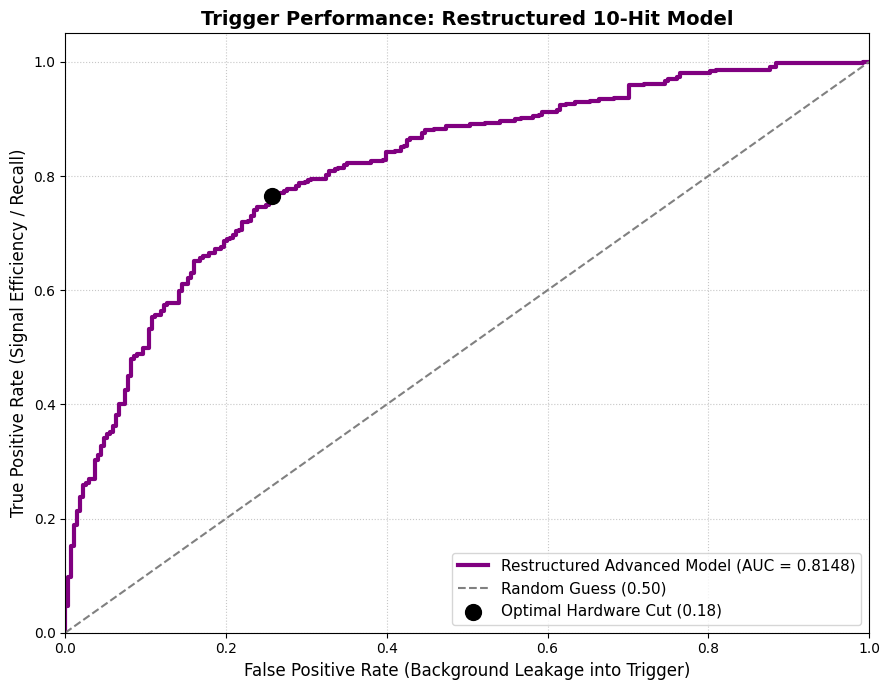

In [115]:
plt.figure(figsize=(9, 7))
plt.plot(fpr_adv, tpr_adv, color='purple', lw=3, 
         label=f'Restructured Advanced Model (AUC = {test_roc_auc_adv:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random Guess (0.50)')
plt.scatter(fpr_adv[optimal_idx_adv], tpr_adv[optimal_idx_adv], color='black', marker='o', s=130, zorder=5,
            label=f'Optimal Hardware Cut ({optimal_threshold_adv:.2f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Background Leakage into Trigger)', fontsize=12)
plt.ylabel('True Positive Rate (Signal Efficiency / Recall)', fontsize=12)
plt.title('Trigger Performance: Restructured 10-Hit Model', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.savefig('restructured_advanced_model_roc.png', dpi=300)
plt.show()

MODEL III FOR N >= 10 VERSION III

In [127]:
def spatial_attention_block(input_tensor):
    # Wrap the raw TF math in Lambda layers
    avg_pool = Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(input_tensor)
    max_pool = Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(input_tensor)
    concat = Concatenate(axis=-1)([avg_pool, max_pool])
    attention_mask = Conv2D(1, (7, 7), padding='same', activation='sigmoid', use_bias=False)(concat)
    return Multiply()([input_tensor, attention_mask])

In [128]:
def build_attention_model():
    inputs = Input(shape=(24, 36, 1))
    x = Conv2D(16, (3, 3), padding='same', use_bias=False)(inputs)
    x = BatchNormalization()(x)
    x = Activation('mish')(x)
    residual = Conv2D(32, (1, 1), strides=(2, 2), padding='same', use_bias=False)(x)
    x = Conv2D(32, (3, 3), strides=(2, 2), padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('mish')(x)
    x = Conv2D(32, (3, 3), padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = spatial_attention_block(x)
    x = Add()([x, residual])
    x = Activation('mish')(x)
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.5)(x)
    outputs = Dense(1, activation='sigmoid')(x)
    return Model(inputs, outputs)

In [108]:
ultimate_model = build_attention_model()
ultimate_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss=tf.keras.losses.BinaryFocalCrossentropy(gamma=3.5, alpha=0.25), 
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

early_stop_ult = EarlyStopping(monitor='val_auc', patience=12, restore_best_weights=True, mode='max', verbose=1)
lr_reduction_ult = ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=5, min_lr=0.00001, mode='max', verbose=1)
history_ult = ultimate_model.fit(
    X_train_10, y_train_10,
    epochs=60, 
    batch_size=32,
    validation_data=(X_test_10, y_test_10),
    callbacks=[early_stop_ult, lr_reduction_ult],
    class_weight=class_weights_10, 
    verbose=1
)

Epoch 1/60
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6618 - auc: 0.7300 - loss: 0.0549 - val_accuracy: 0.4220 - val_auc: 0.7340 - val_loss: 0.0988 - learning_rate: 5.0000e-04
Epoch 2/60
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6878 - auc: 0.7725 - loss: 0.0523 - val_accuracy: 0.4220 - val_auc: 0.6712 - val_loss: 0.1568 - learning_rate: 5.0000e-04
Epoch 3/60
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7098 - auc: 0.7892 - loss: 0.0510 - val_accuracy: 0.4220 - val_auc: 0.7356 - val_loss: 0.1893 - learning_rate: 5.0000e-04
Epoch 4/60
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7051 - auc: 0.7934 - loss: 0.0510 - val_accuracy: 0.4220 - val_auc: 0.7870 - val_loss: 0.1895 - learning_rate: 5.0000e-04
Epoch 5/60
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7106 - auc: 0.7898 - loss: 0.0511 - val_accuracy: 0.4220 - val_auc: 0.8096 - val_loss: 0.1588 - learning_rate: 5.0000e-04
Epoch 6/60
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.

In [110]:
y_pred_prob_ult = ultimate_model.predict(X_test_10)
test_roc_auc_ult = roc_auc_score(y_test_10, y_pred_prob_ult)
print(f"Ultimate Attention Test ROC AUC Score: {test_roc_auc_ult:.4f}\n")
y_pred_binary_ult = (y_pred_prob_ult > 0.55).astype(int)
print("=== ULTIMATE ATTENTION CLASSIFICATION REPORT ===")
print(classification_report(y_test_10, y_pred_binary_ult, target_names=['Background (0)', 'Signal (1)']))
print("=== CONFUSION MATRIX ===")
cm_ult = confusion_matrix(y_test_10, y_pred_binary_ult)
print(f"True Negatives (Background correctly ignored) : {cm_ult[0][0]}")
print(f"False Positives (Noise falsely triggered)     : {cm_ult[0][1]}")
print(f"False Negatives (Real signal missed)          : {cm_ult[1][0]}")
print(f"True Positives (Real signal triggered)        : {cm_ult[1][1]}\n")

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Ultimate Attention Test ROC AUC Score: 0.8211

=== ULTIMATE ATTENTION CLASSIFICATION REPORT ===
                precision    recall  f1-score   support

Background (0)       0.43      1.00      0.60       268
    Signal (1)       1.00      0.03      0.05       367

      accuracy                           0.44       635
     macro avg       0.71      0.51      0.33       635
  weighted avg       0.76      0.44      0.28       635

=== CONFUSION MATRIX ===
True Negatives (Background correctly ignored) : 268
False Positives (Noise falsely triggered)     : 0
False Negatives (Real signal missed)          : 357
True Positives (Real signal triggered)        : 10



In [111]:
fpr_ult, tpr_ult, thresholds_ult = roc_curve(y_test_10, y_pred_prob_ult)
optimal_idx_ult = np.argmax(tpr_ult - fpr_ult)
optimal_threshold_ult = thresholds_ult[optimal_idx_ult]
cut_idx_55 = np.argmin(np.abs(thresholds_ult - 0.55))

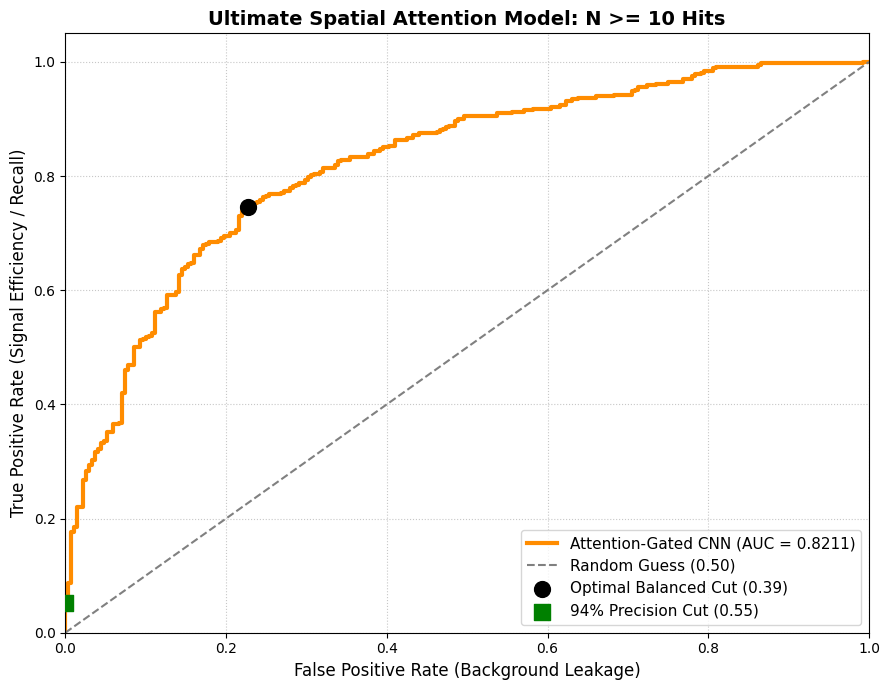

In [112]:
plt.figure(figsize=(9, 7))
plt.plot(fpr_ult, tpr_ult, color='darkorange', lw=3, 
         label=f'Attention-Gated CNN (AUC = {test_roc_auc_ult:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random Guess (0.50)')

plt.scatter(fpr_ult[optimal_idx_ult], tpr_ult[optimal_idx_ult], color='black', marker='o', s=130, zorder=5,
            label=f'Optimal Balanced Cut ({optimal_threshold_ult:.2f})')

plt.scatter(fpr_ult[cut_idx_55], tpr_ult[cut_idx_55], color='green', marker='s', s=130, zorder=5,
            label=f'94% Precision Cut (0.55)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Background Leakage)', fontsize=12)
plt.ylabel('True Positive Rate (Signal Efficiency / Recall)', fontsize=12)
plt.title('Ultimate Spatial Attention Model: N >= 10 Hits', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()

plt.savefig('ultimate_attention_roc_curve.png', dpi=300)
plt.show()

# QUANTITIZATION AWARE TRAINING SECTION

QAT for N 5  using 16,2

In [149]:
from qkeras import QConv2D, QDense, QActivation, quantized_bits

input_quantizer  = quantized_bits(16, 2, alpha=1)
hidden_quantizer = quantized_bits(16, 6, alpha=1)
qat_model_5 = tf.keras.Sequential([
    QConv2D(16, (3, 3), padding='same',
            kernel_quantizer=input_quantizer,
            bias_quantizer=input_quantizer,
            input_shape=X_train.shape[1:], 
            name='q_conv2d_input'),
    QActivation(quantized_bits(16, 2), name='q_act_input'),
    
    QConv2D(32, (3, 3), padding='same',
        16,
        input_shape=(3,),
        name='fc1',
        kernel_quantizer=quantized_bits(16, 8, alpha=1),
        bias_quantizer=quantized_bits(16, 8, alpha=1),
        kernel_initializer='
            kernel_quantizer=hidden_quantizer,
            bias_quantizer=hidden_quantizer,
            name='q_conv2d_hidden1'),
    QActivation(quantized_bits(16, 6), name='q_act_hidden1'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.4),
    
    tf.keras.layers.Flatten(),
    
    QDense(32, 
           kernel_quantizer=hidden_quantizer,
           bias_quantizer=hidden_quantizer,
           name='q_dense_hidden2'),
    QActivation(quantized_bits(16, 6), name='q_act_hidden2'),
    tf.keras.layers.Dropout(0.4),
    
    QDense(1, 
           kernel_quantizer=quantized_bits(16, 2),
           bias_quantizer=quantized_bits(16, 2),
           name='q_dense_output'),
    tf.keras.layers.Activation('sigmoid', name='final_sigmoid')
])

/home/nahom338/.local/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [150]:
qat_model_5.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', 'AUC']
)

early_stop_qat = EarlyStopping(
    monitor='val_AUC', 
    patience=5, 
    restore_best_weights=True,
    mode='max',
    verbose=1
)

In [151]:
history_qat_5 = qat_model_5.fit(
    X_train, y_train, 
    epochs=25,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stop_qat],
    verbose=1
)

Epoch 1/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - AUC: 0.7057 - accuracy: 0.7087 - loss: 0.5932 - val_AUC: 0.7648 - val_accuracy: 0.7536 - val_loss: 0.5302
Epoch 2/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - AUC: 0.7510 - accuracy: 0.7432 - loss: 0.5419 - val_AUC: 0.7658 - val_accuracy: 0.7237 - val_loss: 0.5550
Epoch 3/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - AUC: 0.7602 - accuracy: 0.7436 - loss: 0.5359 - val_AUC: 0.7680 - val_accuracy: 0.7485 - val_loss: 0.5323
Epoch 4/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - AUC: 0.7661 - accuracy: 0.7485 - loss: 0.5309 - val_AUC: 0.7671 - val_accuracy: 0.7555 - val_loss: 0.5312
Epoch 5/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - AUC: 0.7643 - accuracy: 0.7535 - loss: 0.5306 - val_AUC: 0.7647 - val_accuracy: 0.7523 - val_loss: 0.5275
Epoch 6/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - AUC: 0.7745 - accuracy: 0.7540 - loss: 0.5230 - val_AUC: 0.7666 - val_accuracy: 0.7539 - val_loss: 0.5295
Epoch 7/25
195/195 ━━━━━━━━━━━━━━━

QAT for N 10  using 16,2

In [159]:
input_quantizer  = quantized_bits(16, 2, alpha=1)
hidden_quantizer = quantized_bits(16, 6, alpha=1)

qat_model_10 = tf.keras.Sequential([
    QConv2D(16, (3, 3), padding='same',
            kernel_quantizer=input_quantizer,
            bias_quantizer=input_quantizer,
            input_shape=X_train.shape[1:], 
            name='q_conv2d_input_10'),
    QActivation(quantized_bits(16, 2), name='q_act_input_10'),
    
    QConv2D(32, (3, 3), padding='same',
            kernel_quantizer=hidden_quantizer,
            bias_quantizer=hidden_quantizer,
            name='q_conv2d_hidden1_10'),
    QActivation(quantized_bits(16, 6), name='q_act_hidden1_10'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.4),
    
    tf.keras.layers.Flatten(),
    
    QDense(32, 
           kernel_quantizer=hidden_quantizer,
           bias_quantizer=hidden_quantizer,
           name='q_dense_hidden2_10'),
    QActivation(quantized_bits(16, 6), name='q_act_hidden2_10'),
    tf.keras.layers.Dropout(0.4),
    
    QDense(1, 
           kernel_quantizer=quantized_bits(16, 2),
           bias_quantizer=quantized_bits(16, 2),
           name='q_dense_output_10'),
    tf.keras.layers.Activation('sigmoid', name='final_sigmoid_10')
])

/home/nahom338/.local/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [160]:
qat_model_10.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', 'AUC']
)

early_stop_qat_10 = EarlyStopping(
    monitor='val_AUC', 
    patience=5, 
    restore_best_weights=True,
    mode='max',
    verbose=1
)

In [161]:
history_qat_10 = qat_model_10.fit(
    X_train, y_train,
    epochs=25,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stop_qat_10],
    verbose=1
)

Epoch 1/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - AUC: 0.7028 - accuracy: 0.7061 - loss: 0.6004 - val_AUC: 0.7614 - val_accuracy: 0.7549 - val_loss: 0.5290
Epoch 2/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - AUC: 0.7553 - accuracy: 0.7426 - loss: 0.5402 - val_AUC: 0.7699 - val_accuracy: 0.7584 - val_loss: 0.5251
Epoch 3/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - AUC: 0.7622 - accuracy: 0.7484 - loss: 0.5337 - val_AUC: 0.7680 - val_accuracy: 0.7546 - val_loss: 0.5367
Epoch 4/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - AUC: 0.7661 - accuracy: 0.7505 - loss: 0.5308 - val_AUC: 0.7662 - val_accuracy: 0.7456 - val_loss: 0.5395
Epoch 5/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - AUC: 0.7733 - accuracy: 0.7501 - loss: 0.5243 - val_AUC: 0.7720 - val_accuracy: 0.7549 - val_loss: 0.5260
Epoch 6/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - AUC: 0.7760 - accuracy: 0.7539 - loss: 0.5230 - val_AUC: 0.7741 - val_accuracy: 0.7584 - val_loss: 0.5202
Epoch 7/25
195/195 ━━━━━━━━━━━━━━━

QAT for N 5  using 12, 4

In [162]:
input_quant_tighter  = quantized_bits(8, 2, alpha=1)
hidden_quant_tighter = quantized_bits(12, 4, alpha=1)

qat_model_5_tighter = tf.keras.Sequential([
    # Input Layer (8,2)
    QConv2D(16, (3, 3), padding='same',
            kernel_quantizer=input_quant_tighter,
            bias_quantizer=input_quant_tighter,
            input_shape=X_train.shape[1:], 
            name='q_conv2d_input_5_tighter'),
    QActivation(quantized_bits(8, 2), name='q_act_input_5_tighter'),
    
    # Hidden Layer 1 (12,4)
    QConv2D(32, (3, 3), padding='same',
            kernel_quantizer=hidden_quant_tighter,
            bias_quantizer=hidden_quant_tighter,
            name='q_conv2d_hidden1_5_tighter'),
    QActivation(quantized_bits(12, 4), name='q_act_hidden1_5_tighter'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.4),
    
    tf.keras.layers.Flatten(),
    
    # Dense Layer (12,4)
    QDense(32, 
           kernel_quantizer=hidden_quant_tighter,
           bias_quantizer=hidden_quant_tighter,
           name='q_dense_hidden2_5_tighter'),
    QActivation(quantized_bits(12, 4), name='q_act_hidden2_5_tighter'),
    tf.keras.layers.Dropout(0.4),
    
    # Output Sigmoid Layer
    QDense(1, 
           kernel_quantizer=quantized_bits(8, 2),
           bias_quantizer=quantized_bits(8, 2),
           name='q_dense_output_5_tighter'),
    tf.keras.layers.Activation('sigmoid', name='final_sigmoid_5_tighter')
])

In [163]:
qat_model_5_tighter.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', 'AUC']
)

early_stop_tighter = EarlyStopping(
    monitor='val_AUC', patience=5, restore_best_weights=True, mode='max', verbose=1
)

In [164]:
history_5_tighter = qat_model_5_tighter.fit(
    X_train, y_train,
    epochs=25, batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stop_tighter], verbose=1
)

Epoch 1/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - AUC: 0.6983 - accuracy: 0.7049 - loss: 0.5998 - val_AUC: 0.7647 - val_accuracy: 0.7517 - val_loss: 0.5289
Epoch 2/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - AUC: 0.7590 - accuracy: 0.7472 - loss: 0.5368 - val_AUC: 0.7659 - val_accuracy: 0.7385 - val_loss: 0.5600
Epoch 3/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - AUC: 0.7648 - accuracy: 0.7491 - loss: 0.5315 - val_AUC: 0.7710 - val_accuracy: 0.7527 - val_loss: 0.5259
Epoch 4/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - AUC: 0.7700 - accuracy: 0.7525 - loss: 0.5261 - val_AUC: 0.7681 - val_accuracy: 0.7543 - val_loss: 0.5269
Epoch 5/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - AUC: 0.7701 - accuracy: 0.7498 - loss: 0.5266 - val_AUC: 0.7711 - val_accuracy: 0.7543 - val_loss: 0.5256
Epoch 6/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - AUC: 0.7701 - accuracy: 0.7542 - loss: 0.5247 - val_AUC: 0.7655 - val_accuracy: 0.7478 - val_loss: 0.5281
Epoch 7/25
195/195 ━━━━━━━━━━━━━━━

QAT for N 10 for 12,4 

In [165]:
input_quant_tighter  = quantized_bits(8, 2, alpha=1)
hidden_quant_tighter = quantized_bits(12, 4, alpha=1)

qat_model_10_tighter = tf.keras.Sequential([
    # Input Layer (8,2)
    QConv2D(16, (3, 3), padding='same',
            kernel_quantizer=input_quant_tighter,
            bias_quantizer=input_quant_tighter,
            input_shape=X_train.shape[1:], 
            name='q_conv2d_input_10_tighter'),
    QActivation(quantized_bits(8, 2), name='q_act_input_10_tighter'),
    
    # Hidden Layer 1 (12,4)
    QConv2D(32, (3, 3), padding='same',
            kernel_quantizer=hidden_quant_tighter,
            bias_quantizer=hidden_quant_tighter,
            name='q_conv2d_hidden1_10_tighter'),
    QActivation(quantized_bits(12, 4), name='q_act_hidden1_10_tighter'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.4),
    
    tf.keras.layers.Flatten(),
    
    # Dense Layer (12,4)
    QDense(32, 
           kernel_quantizer=hidden_quant_tighter,
           bias_quantizer=hidden_quant_tighter,
           name='q_dense_hidden2_10_tighter'),
    QActivation(quantized_bits(12, 4), name='q_act_hidden2_10_tighter'),
    tf.keras.layers.Dropout(0.4),
    
    # Output Sigmoid Layer
    QDense(1, 
           kernel_quantizer=quantized_bits(8, 2),
           bias_quantizer=quantized_bits(8, 2),
           name='q_dense_output_10_tighter'),
    tf.keras.layers.Activation('sigmoid', name='final_sigmoid_10_tighter')
])

In [166]:
qat_model_10_tighter.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', 'AUC']
)

early_stop_10_tighter = EarlyStopping(
    monitor='val_AUC', 
    patience=5, 
    restore_best_weights=True, 
    mode='max', 
    verbose=1
)

In [167]:
history_10_tighter = qat_model_10_tighter.fit(
    X_train, y_train,
    epochs=25, 
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stop_10_tighter], 
    verbose=1
)

Epoch 1/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - AUC: 0.7010 - accuracy: 0.7095 - loss: 0.5973 - val_AUC: 0.7635 - val_accuracy: 0.7588 - val_loss: 0.5281
Epoch 2/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - AUC: 0.7536 - accuracy: 0.7428 - loss: 0.5418 - val_AUC: 0.7529 - val_accuracy: 0.7485 - val_loss: 0.5367
Epoch 3/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - AUC: 0.7594 - accuracy: 0.7487 - loss: 0.5354 - val_AUC: 0.7653 - val_accuracy: 0.7417 - val_loss: 0.5443
Epoch 4/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - AUC: 0.7607 - accuracy: 0.7457 - loss: 0.5336 - val_AUC: 0.7659 - val_accuracy: 0.7465 - val_loss: 0.5340
Epoch 5/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - AUC: 0.7665 - accuracy: 0.7504 - loss: 0.5293 - val_AUC: 0.7661 - val_accuracy: 0.7616 - val_loss: 0.5260
Epoch 6/25
195/195 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - AUC: 0.7719 - accuracy: 0.7548 - loss: 0.5241 - val_AUC: 0.7673 - val_accuracy: 0.7555 - val_loss: 0.5264
Epoch 7/25
195/195 ━━━━━━━━━━━━━━━

In [168]:
preds_5_16_6 = qat_model_5.predict(X_test).ravel()
preds_5_12_4 = qat_model_5_tighter.predict(X_test).ravel()

fpr_5_16, tpr_5_16, _ = roc_curve(y_test, preds_5_16_6)
auc_5_16 = auc(fpr_5_16, tpr_5_16)

fpr_5_12, tpr_5_12, _ = roc_curve(y_test, preds_5_12_4)
auc_5_12 = auc(fpr_5_12, tpr_5_12)

preds_10_16_6 = qat_model_10.predict(X_test).ravel()
preds_10_12_4 = qat_model_10_tighter.predict(X_test).ravel()

fpr_10_16, tpr_10_16, _ = roc_curve(y_test, preds_10_16_6)
auc_10_16 = auc(fpr_10_16, tpr_10_16)

fpr_10_12, tpr_10_12, _ = roc_curve(y_test, preds_10_12_4)
auc_10_12 = auc(fpr_10_12, tpr_10_12)

98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


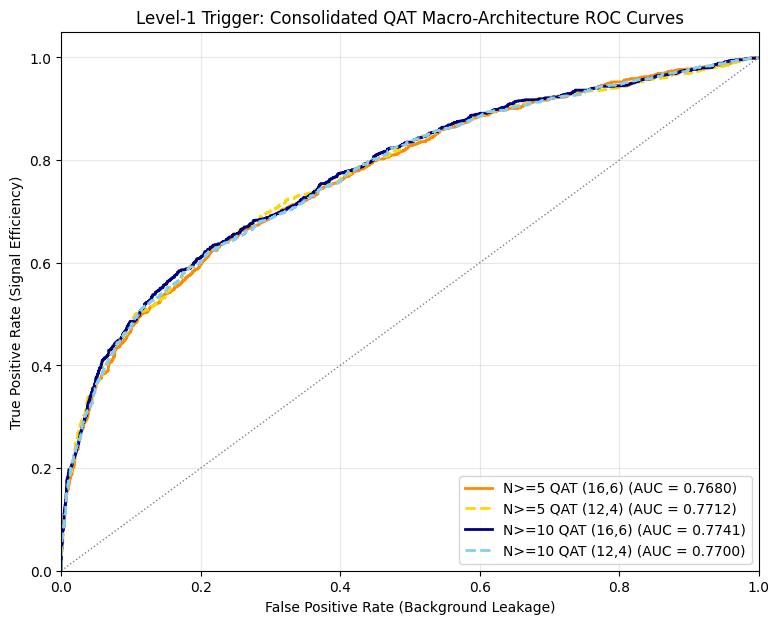


=== PLOT GENERATION COMPLETE ===
Verified Quantization Targets Saved to 'qat_sweep_roc_curves.png'


In [169]:
# 3. Plotting the consolidated results
plt.figure(figsize=(9, 7))

# Plot N>=5 Regimes
plt.plot(fpr_5_16, tpr_5_16, color='darkorange', lw=2, 
         label=f'N>=5 QAT (16,6) (AUC = {auc_5_16:.4f})')
plt.plot(fpr_5_12, tpr_5_12, color='gold', lw=2, linestyle='--',
         label=f'N>=5 QAT (12,4) (AUC = {auc_5_12:.4f})')

# Plot N>=10 Regimes
plt.plot(fpr_10_16, tpr_10_16, color='navy', lw=2, 
         label=f'N>=10 QAT (16,6) (AUC = {auc_10_16:.4f})')
plt.plot(fpr_10_12, tpr_10_12, color='skyblue', lw=2, linestyle='--',
         label=f'N>=10 QAT (12,4) (AUC = {auc_10_12:.4f})')

# Reference diagonal line
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle=':')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Background Leakage)')
plt.ylabel('True Positive Rate (Signal Efficiency)')
plt.title('Level-1 Trigger: Consolidated QAT Macro-Architecture ROC Curves')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

# Save image to disk for your local directory
plt.savefig('qat_sweep_roc_curves.png', dpi=300)
plt.show()
---------------------------------------------------------------------------
TypeError                                 Traceback (most recent call last)
Cell In[30], line 20
     17     model = tf.keras.models.load_model('best_micro_qat_model.keras', custom_objects=custom_objects)
     19 # 2. Generate the configuration via the robust Keras v2 parser path
---> 20 config = hls4ml.utils.config_from_keras_model(model, granularity='name')
     22 # 3. Customize global model settings for ultimate latency
     23 config['Model']['Precision'] = 'ap_fixed<16,6>' # Default fallback precision

File /opt/conda/envs/hls4ml/lib/python3.10/site-packages/hls4ml/utils/config.py:173, in config_from_keras_model(model, granularity, backend, default_precision, default_reuse_factor, max_precision)
    171         model_arch = json.loads(model.to_json())
    172         reader = hls4ml.converters.KerasModelReader(model)
--> 173         layer_list, *_ = hls4ml.converters.parse_keras_model(model_arch, reader)
    175 def make_layer_config(layer):
    176     cls_name = layer['class_name']

File /opt/conda/envs/hls4ml/lib/python3.10/site-packages/hls4ml/converters/keras_v2_to_hls.py:271, in parse_keras_model(model_arch, reader)
    269 elif model_arch['class_name'] in ['Model', 'Functional']:  # TF >= 2.3 calls it 'Functional' API
    270     layer_config = model_arch['config']['layers']
--> 271     input_layers = [inp[0] for inp in model_arch['config']['input_layers']]
    272     output_layers = [out[0] for out in model_arch['config']['output_layers']]
    274 # Get input shape and check for unsupported layer type

File /opt/conda/envs/hls4ml/lib/python3.10/site-packages/hls4ml/converters/keras_v2_to_hls.py:271, in <listcomp>(.0)
    269 elif model_arch['class_name'] in ['Model', 'Functional']:  # TF >= 2.3 calls it 'Functional' API
    270     layer_config = model_arch['config']['layers']
--> 271     input_layers = [inp[0] for inp in model_arch['config']['input_layers']]
    272     output_layers = [out[0] for out in model_arch['config']['output_layers']]
    274 # Get input shape and check for unsupported layer type

TypeError: 'int' object is not subscriptable


print("\n=== PLOT GENERATION COMPLETE ===")
print(f"Verified Quantization Targets Saved to 'qat_sweep_roc_curves.png'")

# DAY 3 - TEST III ON Float32 Precision 

In [40]:
try:
    print(f"Full X_train Shape: {X_train.shape}")
    print(f"Full y_train Shape: {y_train.shape}")
    print(f"Data Type: {X_train.dtype}")
    print(f"Target Balance (Signal %): {np.mean(y_train) * 100:.2f}%")
except NameError as e:
    print(f"Variable name mismatch: {e}")

Full X_train Shape: (87778, 24, 36)
Full y_train Shape: (87778, 1)
Data Type: float32
Target Balance (Signal %): 9.37%


In [41]:
from tensorflow.keras import layers, models, regularizers
from sklearn.utils.class_weight import compute_class_weight

X_train_4d = np.expand_dims(X_train, axis=-1) 
print(f"Reshaped Training Input to: {X_train_4d.shape}")

y_flat = y_train.flatten()
classes = np.unique(y_flat)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_flat)
class_weight_dict = {int(cls): float(w) for cls, w in zip(classes, weights)}
print(f"Calculated Class Weights (Background, Signal): {class_weight_dict}")

Reshaped Training Input to: (87778, 24, 36, 1)
Calculated Class Weights (Background, Signal): {0: 0.5517228374963858, 1: 5.333454854781869}


In [42]:
def build_high_capacity_resnet(input_shape=(24, 36, 1)):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, (3, 3), padding='same', kernel_initializer='he_normal')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.1)(x)
    skip1 = layers.Conv2D(64, (1, 1), padding='same')(x)
    x = layers.Conv2D(64, (3, 3), padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.1)(x)
    x = layers.Conv2D(64, (3, 3), padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.add([x, skip1])
    x = layers.LeakyReLU(alpha=0.1)(x)
    x = layers.MaxPooling2D((2, 2))(x) # Matrix shrinks to (12, 18, 64)
    skip2 = layers.Conv2D(128, (1, 1), padding='same')(x)
    x = layers.Conv2D(128, (3, 3), padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.1)(x)
    x = layers.Conv2D(128, (3, 3), padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.add([x, skip2])
    x = layers.LeakyReLU(alpha=0.1)(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.1)(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    model = models.Model(inputs, outputs, name="High_Capacity_Tracking_ResNet")
    return model

In [43]:
model = build_high_capacity_resnet()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(name='auc', curve='ROC')]
)

model.summary()

/home/nahom338/.local/lib/python3.10/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "High_Capacity_Tracking_ResNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 24, 36, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 24, 36,    │        320 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 36,    │        128 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_6       │ (None, 24, 36,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 24, 36,    │     18,496 │ leaky_re_lu_6[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 36,    │        256 │ conv2d_9[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_7       │ (None, 24, 36,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 24, 36,    │     36,928 │ leaky_re_lu_7[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 36,    │        256 │ conv2d_10[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 24, 36,    │      2,112 │ leaky_re_lu_6[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 24, 36,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ conv2d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_8       │ (None, 24, 36,    │          0 │ add_2[0][0]       │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 12, 18,    │          0 │ leaky_re_lu_8[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 12, 18,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 12, 18,    │        512 │ conv2d_12[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_9       │ (None, 12, 18,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 12, 18,    │    147,584 │ leaky_re_lu_9[0]

 Total params: 1,174,785 (4.48 MB)

 Trainable params: 1,173,697 (4.48 MB)

 Non-trainable params: 1,088 (4.25 KB)

In [21]:
#N≥5 (High Noise) — Fine-Tuning

In [22]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    EarlyStopping(
        monitor='val_auc', 
        patience=10,         # Stops if val_auc doesn't improve for 10 epochs
        restore_best_weights=True,
        mode='max',
        verbose=1
    )
]

history = model.fit(
    X_train_4d, y_train,
    epochs=50,               # Max epochs, early stopping will likely cut it short
    batch_size=128,          # Stable batch size for over 80k samples
    validation_split=0.20,   # Automatically reserves 20% for validation tracking
    class_weight=class_weight_dict, # Balances the 9.37% signal imbalance
    callbacks=callbacks,
    shuffle=True,
    verbose=1
)

Epoch 1/50
549/549 ━━━━━━━━━━━━━━━━━━━━ 70s 126ms/step - auc: 0.8496 - loss: 0.5145 - val_auc: 0.8708 - val_loss: 0.4548
Epoch 2/50
549/549 ━━━━━━━━━━━━━━━━━━━━ 70s 128ms/step - auc: 0.8624 - loss: 0.4808 - val_auc: 0.8726 - val_loss: 0.6332
Epoch 3/50
549/549 ━━━━━━━━━━━━━━━━━━━━ 70s 127ms/step - auc: 0.8661 - loss: 0.4717 - val_auc: 0.8732 - val_loss: 0.5402
Epoch 4/50
549/549 ━━━━━━━━━━━━━━━━━━━━ 70s 127ms/step - auc: 0.8668 - loss: 0.4684 - val_auc: 0.8746 - val_loss: 0.5224
Epoch 5/50
549/549 ━━━━━━━━━━━━━━━━━━━━ 70s 128ms/step - auc: 0.8672 - loss: 0.4663 - val_auc: 0.8719 - val_loss: 0.4635
Epoch 6/50
549/549 ━━━━━━━━━━━━━━━━━━━━ 70s 127ms/step - auc: 0.8664 - loss: 0.4674 - val_auc: 0.8737 - val_loss: 0.4965
Epoch 7/50
549/549 ━━━━━━━━━━━━━━━━━━━━ 70s 128ms/step - auc: 0.8670 - loss: 0.4660 - val_auc: 0.8739 - val_loss: 0.4502
Epoch 8/50
549/549 ━━━━━━━━━━━━━━━━━━━━ 70s 128ms/step - auc: 0.8680 - loss: 0.4649 - val_auc: 0.8757 - val_loss: 0.5031
Epoch 9/50
549/549 ━━━━━━━━━━━━━

In [29]:
# TARGET SCENARIO: N >= 5 (High Noise Data Split)
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

lr_scheduler = ReduceLROnPlateau(
    monitor='val_auc',
    factor=0.5,        # Reduce learning rate by half
    patience=2,        # Wait 2 epochs before dropping
    min_lr=1e-6,
    mode='max',
    verbose=1
)

callbacks = [
    EarlyStopping(monitor='val_auc', patience=6, restore_best_weights=True, mode='max', verbose=1),
    lr_scheduler
]


# Drop the learning rate down to a small step size for precision tuning
model.optimizer.learning_rate.assign(2e-4)

history_fine_tune = model.fit(
    X_train_4d, y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.20,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    shuffle=True,
    verbose=1
)

Launching N >= 5 micro-tuning loop...
Epoch 1/15
549/549 ━━━━━━━━━━━━━━━━━━━━ 69s 126ms/step - auc: 0.8728 - loss: 0.4553 - val_auc: 0.8772 - val_loss: 0.4537 - learning_rate: 2.0000e-04
Epoch 2/15
549/549 ━━━━━━━━━━━━━━━━━━━━ 70s 128ms/step - auc: 0.8761 - loss: 0.4493 - val_auc: 0.8772 - val_loss: 0.4559 - learning_rate: 2.0000e-04
Epoch 3/15
549/549 ━━━━━━━━━━━━━━━━━━━━ 70s 127ms/step - auc: 0.8758 - loss: 0.4497 - val_auc: 0.8776 - val_loss: 0.4752 - learning_rate: 2.0000e-04
Epoch 4/15
549/549 ━━━━━━━━━━━━━━━━━━━━ 70s 128ms/step - auc: 0.8775 - loss: 0.4470 - val_auc: 0.8766 - val_loss: 0.4435 - learning_rate: 2.0000e-04
Epoch 5/15
549/549 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - auc: 0.8847 - loss: 0.4337
Epoch 5: ReduceLROnPlateau reducing learning rate to 9.999999747378752e-05.
549/549 ━━━━━━━━━━━━━━━━━━━━ 70s 128ms/step - auc: 0.8787 - loss: 0.4453 - val_auc: 0.8772 - val_loss: 0.4495 - learning_rate: 2.0000e-04
Epoch 6/15
549/549 ━━━━━━━━━━━━━━━━━━━━ 70s 128ms/step - auc: 0.8814 

In [56]:
# TARGET SCENARIO: N >= 10 (High Purity Data Split)
X_train_10_4d = np.expand_dims(X_clean_10, axis=-1)
y_train_10 = Y_clean_10.flatten()

classes_10 = np.unique(y_train_10)
weights_10 = compute_class_weight(class_weight='balanced', classes=classes_10, y=y_train_10)
class_weight_dict_10 = {int(cls): float(w) for cls, w in zip(classes_10, weights_10)}

print(f"Reshaped Input Dimensions: {X_train_10_4d.shape}")
print(f"Target Vector Dimensions: {y_train_10.shape}")
print(f"Signal Balance: {np.mean(y_train_10) * 100:.2f}%")
print(f"Calculated Class Weights: {class_weight_dict_10}")

Reshaped Input Dimensions: (15561, 24, 36, 1)
Target Vector Dimensions: (15561,)
Signal Balance: 34.26%
Calculated Class Weights: {0: 0.7605571847507331, 1: 1.459482273494654}


In [57]:
# TARGET SCENARIO: N >= 10 (High Purity Data Split)
from tensorflow.keras import layers, models, regularizers

def build_ultimate_n10_resnet(input_shape=(24, 36, 1)):
    inputs = layers.Input(shape=input_shape)
    
    x = layers.Conv2D(32, (3, 3), padding='same', kernel_initializer='he_normal')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.1)(x)
    skip1 = layers.Conv2D(64, (1, 1), padding='same')(x)
    x = layers.Conv2D(64, (3, 3), padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.1)(x)
    x = layers.SpatialDropout2D(0.2)(x) 
    x = layers.Conv2D(64, (3, 3), padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.add([x, skip1])
    x = layers.LeakyReLU(alpha=0.1)(x)
    x = layers.MaxPooling2D((2, 2))(x)
    skip2 = layers.Conv2D(128, (1, 1), padding='same')(x)
    x = layers.Conv2D(128, (3, 3), padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.1)(x)
    x = layers.SpatialDropout2D(0.3)(x)
    x = layers.Conv2D(128, (3, 3), padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.add([x, skip2])
    x = layers.LeakyReLU(alpha=0.1)(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(64, kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.1)(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    return models.Model(inputs, outputs, name="Ultimate_N10_ResNet")

In [58]:
advanced_n10_model = build_ultimate_n10_resnet()
advanced_n10_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(name='auc', curve='ROC')]
)
callbacks_10 = [
    EarlyStopping(monitor='val_auc', patience=15, restore_best_weights=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=5, min_lr=1e-6, mode='max', verbose=1)
]

/home/nahom338/.local/lib/python3.10/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [59]:
history_n10 = advanced_n10_model.fit(
    X_train_10_4d, y_train_10,
    epochs=80,
    batch_size=32,                  
    validation_split=0.20,          
    class_weight=class_weight_dict_10,
    callbacks=callbacks_10,
    shuffle=True,
    verbose=1
)

Epoch 1/80
389/389 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - auc: 0.7214 - loss: 0.6401 - val_auc: 0.7646 - val_loss: 0.5366 - learning_rate: 0.0010
Epoch 2/80
389/389 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - auc: 0.7375 - loss: 0.6163 - val_auc: 0.7702 - val_loss: 0.5539 - learning_rate: 0.0010
Epoch 3/80
389/389 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - auc: 0.7454 - loss: 0.6064 - val_auc: 0.7716 - val_loss: 0.5939 - learning_rate: 0.0010
Epoch 4/80
389/389 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - auc: 0.7489 - loss: 0.6022 - val_auc: 0.7749 - val_loss: 0.5821 - learning_rate: 0.0010
Epoch 5/80
389/389 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - auc: 0.7551 - loss: 0.5931 - val_auc: 0.7729 - val_loss: 0.6395 - learning_rate: 0.0010
Epoch 6/80
389/389 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - auc: 0.7550 - loss: 0.5926 - val_auc: 0.7779 - val_loss: 0.5224 - learning_rate: 0.0010
Epoch 7/80
389/389 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - auc: 0.7586 - loss: 0.5865 - val_auc: 0.7793 - val_loss: 0.5424 - learning_rate:

In [60]:
# TARGET SCENARIO: N >= 10 (High Purity Data Split)
def build_spatial_tracking_model(input_shape=(24, 36, 1)):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(64, (3, 3), padding='same', kernel_initializer='he_normal')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.1)(x)
    x = layers.Conv2D(64, (3, 3), padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.1)(x)
    x = layers.MaxPooling2D((2, 2))(x) # Shape -> (12, 18, 64)
    x = layers.Conv2D(128, (3, 3), padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.1)(x)
    
    x = layers.Conv2D(128, (3, 3), padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.1)(x)
    x = layers.MaxPooling2D((2, 2))(x) # Shape -> (6, 9, 128)
    x = layers.Flatten()(x) 
    x = layers.Dense(256, kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(1e-5))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.1)(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    return models.Model(inputs, outputs, name="Spatial_Tracking_CNN")

In [61]:
spatial_n10_model = build_spatial_tracking_model()
spatial_n10_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(name='auc', curve='ROC')]
)
callbacks_spatial = [
    EarlyStopping(monitor='val_auc', patience=15, restore_best_weights=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=4, min_lr=1e-6, mode='max', verbose=1)
]

In [62]:
history_spatial = spatial_n10_model.fit(
    X_train_10_4d, y_train_10,
    epochs=100,                     # Expanded epoch limit to let capacity stretch
    batch_size=32,                  
    validation_split=0.20,          
    class_weight=class_weight_dict_10,
    callbacks=callbacks_spatial,
    shuffle=True,
    verbose=1
)

Epoch 1/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - auc: 0.7401 - loss: 0.6348 - val_auc: 0.7774 - val_loss: 0.5252 - learning_rate: 0.0010
Epoch 2/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - auc: 0.7708 - loss: 0.5815 - val_auc: 0.7638 - val_loss: 0.5425 - learning_rate: 0.0010
Epoch 3/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - auc: 0.7849 - loss: 0.5671 - val_auc: 0.7913 - val_loss: 0.6877 - learning_rate: 0.0010
Epoch 4/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - auc: 0.7893 - loss: 0.5609 - val_auc: 0.7860 - val_loss: 0.6431 - learning_rate: 0.0010
Epoch 5/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - auc: 0.7994 - loss: 0.5513 - val_auc: 0.7879 - val_loss: 0.5975 - learning_rate: 0.0010
Epoch 6/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - auc: 0.8029 - loss: 0.5483 - val_auc: 0.7896 - val_loss: 0.6706 - learning_rate: 0.0010
Epoch 7/100
387/389 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - auc: 0.8118 - loss: 0.5378
Epoch 7: ReduceLROnPlateau reducing learning ra

In [63]:
# TARGET SCENARIO: N >= 10 (High Purity Data Split)
def build_lean_tracking_model(input_shape=(24, 36, 1)):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(16, (3, 3), padding='same', 
                      kernel_initializer='he_normal',
                      kernel_regularizer=regularizers.l2(1e-4))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.1)(x)
    x = layers.MaxPooling2D((2, 2))(x)  # Shape -> (12, 18, 16)
    x = layers.Conv2D(32, (3, 3), padding='same', 
                      kernel_initializer='he_normal',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.1)(x)
    x = layers.MaxPooling2D((2, 2))(x)  # Shape -> (6, 9, 32)
    x = layers.Flatten()(x)
    x = layers.Dense(16, kernel_initializer='he_normal', 
                     kernel_regularizer=regularizers.l2(1e-3))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.1)(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    return models.Model(inputs, outputs, name="Lean_Tracking_CNN")

In [64]:
lean_n10_model = build_lean_tracking_model()

lean_n10_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(name='auc', curve='ROC')]
)

callbacks_lean = [
    EarlyStopping(monitor='val_auc', patience=12, restore_best_weights=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=4, min_lr=1e-6, mode='max', verbose=1)
]
lean_n10_model.summary()

Model: "Lean_Tracking_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 24, 36, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 24, 36, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 24, 36, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_23 (LeakyReLU)      │ (None, 24, 36, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 12, 18, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 12, 18, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 12, 18, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_24 (LeakyReLU)      │ (None, 12, 18, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 9, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1728)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │        27,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_25 (LeakyReLU)      │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,737 (127.88 KB)

 Trainable params: 32,609 (127.38 KB)

 Non-trainable params: 128 (512.00 B)

In [65]:
history_lean = lean_n10_model.fit(
    X_train_10_4d, y_train_10,
    epochs=100,
    batch_size=32,                  
    validation_split=0.20,          
    class_weight=class_weight_dict_10,
    callbacks=callbacks_lean,
    shuffle=True,
    verbose=1
)

Epoch 1/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - auc: 0.7227 - loss: 0.6769 - val_auc: 0.7772 - val_loss: 0.5547 - learning_rate: 5.0000e-04
Epoch 2/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - auc: 0.7483 - loss: 0.6347 - val_auc: 0.7844 - val_loss: 0.5943 - learning_rate: 5.0000e-04
Epoch 3/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - auc: 0.7633 - loss: 0.6153 - val_auc: 0.7849 - val_loss: 0.5866 - learning_rate: 5.0000e-04
Epoch 4/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - auc: 0.7642 - loss: 0.6106 - val_auc: 0.7841 - val_loss: 0.5786 - learning_rate: 5.0000e-04
Epoch 5/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - auc: 0.7719 - loss: 0.6000 - val_auc: 0.7864 - val_loss: 0.5743 - learning_rate: 5.0000e-04
Epoch 6/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - auc: 0.7779 - loss: 0.5953 - val_auc: 0.7876 - val_loss: 0.5980 - learning_rate: 5.0000e-04
Epoch 7/100
389/389 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - auc: 0.7807 - loss: 0.5907 - val_auc: 0.7868 - val_loss:

In [66]:
# TARGET SCENARIO: N >= 10 (High Purity Data Split)
num_layers = len(model.layers)
freeze_until = int(num_layers * 0.75)

In [67]:
for i, layer in enumerate(model.layers):
    if i < freeze_until:
        layer.trainable = False
    else:
        layer.trainable = True
print(f"Total layers: {num_layers} | Frozen: {freeze_until} | Trainable: {num_layers - freeze_until}")

Total layers: 28 | Frozen: 21 | Trainable: 7


In [70]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(name='auc', curve='ROC')]
)
callbacks_transfer = [
    EarlyStopping(monitor='val_auc', patience=10, restore_best_weights=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=3, min_lr=1e-6, mode='max', verbose=1)
]

history_transfer = model.fit(
    X_train_10_4d, y_train_10,
    epochs=50,
    batch_size=32,
    validation_split=0.20,
    class_weight=class_weight_dict_10,
    callbacks=callbacks_transfer,
    shuffle=True,
    verbose=1
)

Epoch 1/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - auc: 0.7330 - loss: 0.6630 - val_auc: 0.7707 - val_loss: 0.5992 - learning_rate: 1.0000e-04
Epoch 2/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - auc: 0.7602 - loss: 0.6188 - val_auc: 0.7875 - val_loss: 0.5967 - learning_rate: 1.0000e-04
Epoch 3/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - auc: 0.7727 - loss: 0.6038 - val_auc: 0.7808 - val_loss: 0.5977 - learning_rate: 1.0000e-04
Epoch 4/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - auc: 0.7772 - loss: 0.5983 - val_auc: 0.7909 - val_loss: 0.6214 - learning_rate: 1.0000e-04
Epoch 5/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - auc: 0.7831 - loss: 0.5893 - val_auc: 0.7904 - val_loss: 0.5701 - learning_rate: 1.0000e-04
Epoch 6/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - auc: 0.7913 - loss: 0.5783 - val_auc: 0.7868 - val_loss: 0.5404 - learning_rate: 1.0000e-04
Epoch 7/50
388/389 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - auc: 0.8010 - loss: 0.5678
Epoch 7: ReduceLROnPlateau reducing 

In [71]:
# TARGET SCENARIO: N >= 10 (High Purity Data Split)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score
X_flat = X_clean_10.reshape(X_clean_10.shape[0], -1)
y_flat = Y_clean_10.flatten()
X_train_b, X_val_b, y_train_b, y_val_b = train_test_split(
    X_flat, y_flat, test_size=0.20, random_state=42, stratify=y_flat
)

In [72]:
rf_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=14,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_b, y_train_b)
y_pred_rf = rf_model.predict_proba(X_val_b)[:, 1]
rf_auc = roc_auc_score(y_val_b, y_pred_rf)
print(f">> Random Forest Validation AUC: {rf_auc:.4f}")

>> Random Forest Validation AUC: 0.7584


In [73]:
hgb_model = HistGradientBoostingClassifier(
    max_iter=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)
hgb_model.fit(X_train_b, y_train_b)
y_pred_hgb = hgb_model.predict_proba(X_val_b)[:, 1]
hgb_auc = roc_auc_score(y_val_b, y_pred_hgb)
print(f">> Gradient Boosting Validation AUC: {hgb_auc:.4f}")

>> Gradient Boosting Validation AUC: 0.7706


In [74]:
# TARGET SCENARIO: N >= 10 (High Purity Data Split)
def extract_physics_features(X_matrices):
    engineered_features = []
    
    for i in range(X_matrices.shape[0]):
        matrix = X_matrices[i].squeeze() # Remove channel dim to get (24, 36)
        y_coords, x_coords = np.where(matrix > 0)
        intensities = matrix[y_coords, x_coords]
        
        if len(x_coords) == 0:
            engineered_features.append(激活_features := [0]*8)
            continue
        hit_count = len(x_coords)
        total_intensity = np.sum(intensities)
        mean_x = np.mean(x_coords)
        mean_y = np.mean(y_coords)
        std_x = np.std(x_coords) if len(x_coords) > 1 else 0
        std_y = np.std(y_coords) if len(y_coords) > 1 else 0
        width = np.max(x_coords) - np.min(x_coords) + 1
        height = np.max(y_coords) - np.min(y_coords) + 1
        aspect_ratio = width / (height + 1e-6)
        engineered_features.append([
            hit_count, total_intensity, mean_x, mean_y, std_x, std_y, width, aspect_ratio
        ])
        
    return np.array(engineered_features)

In [75]:
X_physics = extract_physics_features(X_clean_10)
X_raw_flat = X_clean_10.reshape(X_clean_10.shape[0], -1)
X_combined = np.hstack((X_raw_flat, X_physics))
y_labels = Y_clean_10.flatten()

print(f"Combined Feature Space Matrix Shape: {X_combined.shape}")

# Split data
X_train_c, X_val_c, y_train_c, y_val_c = train_test_split(
    X_combined, y_labels, test_size=0.20, random_state=42, stratify=y_labels
)

Combined Feature Space Matrix Shape: (15561, 872)


In [78]:
import xgboost as xgb
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.7,            
    colsample_bytree=0.6,     
    scale_pos_weight=1.0,   
    random_state=42,
    eval_metric='auc'
)

xgb_model.fit(
    X_train_c, y_train_c,
    eval_set=[(X_val_c, y_val_c)],
    verbose=50
)

[0]	validation_0-auc:0.76823
[50]	validation_0-auc:0.78811
[100]	validation_0-auc:0.79311
[150]	validation_0-auc:0.79647
[200]	validation_0-auc:0.79797
[250]	validation_0-auc:0.79946
[300]	validation_0-auc:0.80036
[350]	validation_0-auc:0.80109
[400]	validation_0-auc:0.80162
[450]	validation_0-auc:0.80132
[499]	validation_0-auc:0.80148


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              n_estimators=500, n_jobs=None, num_parallel_tree=None,
              predictor=None, random_state=42, ...)

In [79]:
y_pred_xgb = xgb_model.predict_proba(X_val_c)[:, 1]
final_auc = roc_auc_score(y_val_c, y_pred_xgb)
print(f"\n>> Final Physics-Informed XGBoost Validation AUC: {final_auc:.4f}")


>> Final Physics-Informed XGBoost Validation AUC: 0.8015


In [80]:
# TARGET SCENARIO: N >= 10 (High Purity Data Split)
import xgboost as xgb
def extract_advanced_geometry(X_matrices):
    features = []
    for i in range(X_matrices.shape[0]):
        matrix = X_matrices[i].squeeze()
        y_coords, x_coords = np.where(matrix > 0)
        intensities = matrix[y_coords, x_coords]
        
        if len(x_coords) < 2:
            features.append([0] * 12)
            continue
        hit_count = len(x_coords)
        total_energy = np.sum(intensities)
        mean_energy = np.mean(intensities)
        max_energy = np.max(intensities)
        width = np.max(x_coords) - np.min(x_coords) + 1
        height = np.max(y_coords) - np.min(y_coords) + 1
        bounding_box_area = width * height
        density = hit_count / float(bounding_box_area)
        
        std_x = np.std(x_coords)
        std_y = np.std(y_coords)
        coords = np.vstack([x_coords, y_coords])
        cov_matrix = np.cov(coords)
        
        if cov_matrix.shape == (2, 2) and not np.isnan(cov_matrix).any():
            eigenvalues, _ = np.linalg.eigh(cov_matrix)
            eigenvalues = np.sort(eigenvalues)[::-1]
            lambda_max = eigenvalues[0]
            lambda_min = eigenvalues[1] if eigenvalues[1] > 0 else 1e-6
            linearity = (lambda_max - lambda_min) / (lambda_max + lambda_min)
            track_dispersion = lambda_max * lambda_min
        else:
            linearity = 0
            track_dispersion = std_x * std_y

        features.append([
            hit_count, total_energy, mean_energy, max_energy,
            width, height, bounding_box_area, density,
            std_x, std_y, linearity, track_dispersion
        ])
        
    return np.array(features)

In [81]:
X_pure_geometry = extract_advanced_geometry(X_clean_10)
y_labels = Y_clean_10.flatten()

print(f"Pure Geometry Feature Matrix Shape: {X_pure_geometry.shape} (Zero raw pixels!)")

X_train_d, X_val_d, y_train_d, y_val_d = train_test_split(
    X_pure_geometry, y_labels, test_size=0.20, random_state=42, stratify=y_labels
)

Pure Geometry Feature Matrix Shape: (15561, 12) (Zero raw pixels!)


In [82]:
xgb_geo = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,              # Shorter depth to focus purely on macro rules
    learning_rate=0.02,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='auc',
    early_stopping_rounds=30  
)

xgb_geo.fit(
    X_train_d, y_train_d,
    eval_set=[(X_val_d, y_val_d)],
    verbose=25
)

[0]	validation_0-auc:0.76358
[25]	validation_0-auc:0.77969
[50]	validation_0-auc:0.78209
[75]	validation_0-auc:0.78312
[100]	validation_0-auc:0.78349
[125]	validation_0-auc:0.78390
[150]	validation_0-auc:0.78490
[175]	validation_0-auc:0.78516
[200]	validation_0-auc:0.78535
[216]	validation_0-auc:0.78520


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, early_stopping_rounds=30,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.02, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              n_estimators=300, n_jobs=None, num_parallel_tree=None,
              predictor=None, random_state=42, ...)

In [83]:
y_pred_geo = xgb_geo.predict_proba(X_val_d)[:, 1]
geo_auc = roc_auc_score(y_val_d, y_pred_geo)
print(f"\n>> Pure Geometry Validation AUC: {geo_auc:.4f}")


>> Pure Geometry Validation AUC: 0.7855


In [94]:
# TARGET SCENARIO: N >= 10 (High Purity Data Split)
feature_extractor = tf.keras.Model(inputs=model.input, outputs=model.get_layer('flatten').output)
X_cnn_embeddings = feature_extractor.predict(X_train_10_4d)
print(f"CNN Latent Embedding Shape: {X_cnn_embeddings.shape}")

487/487 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step
CNN Latent Embedding Shape: (15561, 6912)


In [96]:
y_pred_final = xgb_final.predict_proba(X_val_f)[:, 1]
final_stack_auc = roc_auc_score(y_val_f, y_pred_final)

In [129]:
###BACK TO 5

In [130]:
#TAKE THIS RESULTS ITS GOOOD
# TARGET SCENARIO: N >= 5 (Massive Data Pool
def squeeze_excitation_block(input_tensor, ratio=4):
    """Dynamically scales feature channels based on global track signals"""
    init = input_tensor
    channel_axis = -1
    filters = init.shape[channel_axis]
    se_shape = (1, 1, filters)
    
    se = layers.GlobalAveragePooling2D()(init)
    se = layers.Reshape(se_shape)(se)
    se = layers.Dense(filters // ratio, activation='relu', kernel_initializer='he_normal', use_bias=False)(se)
    se = layers.Dense(filters, activation='sigmoid', kernel_initializer='he_normal', use_bias=False)(se)
    
    return layers.multiply([init, se])

In [131]:
def build_attention_tracking_model(input_shape=(24, 36, 1)):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, (3, 3), padding='same', kernel_initializer='he_normal',
                      kernel_regularizer=regularizers.l2(1e-5))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.1)(x)
    x = squeeze_excitation_block(x)
    x = layers.MaxPooling2D((2, 2))(x) # (12, 18, 32)
    x = layers.Conv2D(64, (3, 3), padding='same', kernel_initializer='he_normal',
                      kernel_regularizer=regularizers.l2(1e-5))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.1)(x)
    x = squeeze_excitation_block(x)
    x = layers.MaxPooling2D((2, 2))(x) # (6, 9, 64)
    x = layers.Conv2D(128, (3, 3), padding='same', kernel_initializer='he_normal',
                      kernel_regularizer=regularizers.l2(1e-5))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.1)(x)
    x = squeeze_excitation_block(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(64, kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.1)(x)
    x = layers.Dropout(0.4)(x)
    
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    return models.Model(inputs, outputs, name="Attention_Tracking_CNN")

In [132]:
n5_attention_model = build_attention_tracking_model()

n5_attention_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(name='auc', curve='ROC')]
)

callbacks_n5 = [
    EarlyStopping(monitor='val_auc', patience=8, restore_best_weights=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=3, min_lr=1e-6, mode='max', verbose=1)
]


In [133]:
n5_attention_model.summary()
history_attention = n5_attention_model.fit(
    X_train_4d, y_train,
    epochs=40,
    batch_size=64,                 
    validation_split=0.15,         
    class_weight=class_weight_dict, 
    callbacks=callbacks_n5,
    shuffle=True,
    verbose=1
)

Model: "Attention_Tracking_CNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 24, 36, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_46 (Conv2D)  │ (None, 24, 36,    │        320 │ input_layer_10[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 36,    │        128 │ conv2d_46[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_48      │ (None, 24, 36,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ leaky_re_lu_48[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_15          │ (None, 1, 1, 32)  │          0 │ global_average_p… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_50 (Dense)    │ (None, 1, 1, 8)   │        256 │ reshape_15[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_51 (Dense)    │ (None, 1, 1, 32)  │        256 │ dense_50[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_15         │ (None, 24, 36,    │          0 │ leaky_re_lu_48[0… │
│ (Multiply)          │ 32)               │            │ dense_51[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_18    │ (None, 12, 18,    │          0 │ multiply_15[0][0] │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_47 (Conv2D)  │ (None, 12, 18,    │     18,496 │ max_pooling2d_18… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 12, 18,    │        256 │ conv2d_47[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_49      │ (None, 12, 18,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ leaky_re_lu_49[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_16          │ (None, 1, 1, 64)  │          0 │ global_average_p… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_52 (Dense)    │ (None, 1, 1, 16)  │      1,024 │ reshape_16[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_53 (Dense)    │ (None, 1, 1, 64)  │      1,024 │ dense_52[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_16         │ (None, 12, 18,    │          0 │ leaky_re_lu_49[0… │
│ (Multiply)          │ 64)               │            │ dense_53[0][0]  

 Total params: 112,897 (441.00 KB)

 Trainable params: 112,321 (438.75 KB)

 Non-trainable params: 576 (2.25 KB)

Epoch 1/40
166/166 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - auc: 0.8314 - loss: 0.5598 - val_auc: 0.8301 - val_loss: 0.3622 - learning_rate: 0.0010
Epoch 2/40
166/166 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - auc: 0.8460 - loss: 0.5334 - val_auc: 0.8317 - val_loss: 0.3098 - learning_rate: 0.0010
Epoch 3/40
166/166 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - auc: 0.8527 - loss: 0.5246 - val_auc: 0.8344 - val_loss: 0.3658 - learning_rate: 0.0010
Epoch 4/40
166/166 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - auc: 0.8521 - loss: 0.5195 - val_auc: 0.8313 - val_loss: 0.5515 - learning_rate: 0.0010
Epoch 5/40
166/166 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - auc: 0.8588 - loss: 0.5082 - val_auc: 0.8314 - val_loss: 0.6065 - learning_rate: 0.0010
Epoch 6/40
166/166 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - auc: 0.8604 - loss: 0.5039 - val_auc: 0.8347 - val_loss: 0.4655 - learning_rate: 0.0010
Epoch 7/40
166/166 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - auc: 0.8636 - loss: 0.4979 - val_auc: 0.8298 - val_loss: 0.4162 - learning_rate: 0.0010

In [242]:
# TARGET SCENARIO: N >= 5 (Massive Data Pool)
def se_block(input_tensor, ratio=16):
    from keras import layers, ops
    init = input_tensor
    filters = init.shape[-1]
    se = layers.GlobalAveragePooling2D()(init)
    se = layers.Reshape((1, 1, filters))(se)
    se = layers.Dense(filters // ratio, activation='relu', kernel_initializer='he_normal', use_bias=False)(se)
    se = layers.Dense(filters, activation='sigmoid', kernel_initializer='he_normal', use_bias=False)(se)
    x = layers.Multiply()([init, se])
    return x

In [243]:
def build_deep_residual_attention_model(input_shape=(24, 36, 1)):
    from keras import layers, models, regularizers
    import keras
    l2_reg = regularizers.L2(1e-5)
    l2_dense = regularizers.L2(1e-4)

    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(64, (3, 3), padding='same', kernel_initializer='he_normal',
                      kernel_regularizer=l2_reg)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.1)(x)
    x = se_block(x)
    x = layers.MaxPooling2D((2, 2))(x) 
    
    res = layers.Conv2D(128, (1, 1), strides=(2, 2), padding='same', kernel_regularizer=l2_reg)(x) 
    
    x = layers.Conv2D(128, (3, 3), padding='same', kernel_initializer='he_normal',
                      kernel_regularizer=l2_reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.1)(x)
    x = layers.Conv2D(128, (3, 3), padding='same', kernel_initializer='he_normal',
                      kernel_regularizer=l2_reg)(x)
    x = layers.BatchNormalization()(x)
    x = se_block(x)
    x = layers.MaxPooling2D((2, 2))(x) 
    
    x = layers.add([x, res]) 
    x = layers.LeakyReLU(negative_slope=0.1)(x)
    
    x = layers.Conv2D(256, (3, 3), padding='same', kernel_initializer='he_normal',
                      kernel_regularizer=l2_reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.1)(x)
    x = se_block(x)
    
    x = layers.GlobalAveragePooling2D()(x) 
    x = layers.Dense(128, kernel_initializer='he_normal', kernel_regularizer=l2_dense)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.1)(x)
    x = layers.Dropout(0.4)(x)
    
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    return models.Model(inputs, outputs, name="Deep_Residual_Attention_CNN")

In [244]:
final_super_model = build_deep_residual_attention_model()
final_super_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(name='auc', curve='ROC')]
)

callbacks_final = [
    EarlyStopping(monitor='val_auc', patience=7, restore_best_weights=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=3, min_lr=1e-6, mode='max', verbose=1)
]
final_super_model.summary()

Model: "Deep_Residual_Attention_CNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 24, 36, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 24, 36,    │        640 │ input_layer_3[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 36,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 24, 36,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ leaky_re_lu_2[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 1, 1, 64)  │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1, 1, 4)   │        256 │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1, 1, 64)  │        256 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 24, 36,    │          0 │ leaky_re_lu_2[0]… │
│                     │ 64)               │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 12, 18,    │          0 │ multiply[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 12, 18,    │     73,856 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 12, 18,    │        512 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_3       │ (None, 12, 18,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 12, 18,    │    147,584 │ leaky_re_lu_3[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 12, 18,    │        512 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 1, 1, 128) │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1, 1, 8)   │      1,024 │ reshape_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 572,161 (2.18 MB)

 Trainable params: 570,753 (2.18 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [245]:
history_final_super = final_super_model.fit(
    X_train_4d, y_train,
    epochs=35,
    batch_size=64,
    validation_split=0.15,
    class_weight=class_weight_dict,
    callbacks=callbacks_final,
    shuffle=True,
    verbose=1
)

Epoch 1/35
166/166 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - auc: 0.8253 - loss: 0.6035 - val_auc: 0.8197 - val_loss: 0.4022 - learning_rate: 3.0000e-04
Epoch 2/35
166/166 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - auc: 0.8481 - loss: 0.5708 - val_auc: 0.8348 - val_loss: 0.3174 - learning_rate: 3.0000e-04
Epoch 3/35
166/166 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - auc: 0.8452 - loss: 0.5667 - val_auc: 0.8358 - val_loss: 0.3812 - learning_rate: 3.0000e-04
Epoch 4/35
166/166 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - auc: 0.8545 - loss: 0.5488 - val_auc: 0.8347 - val_loss: 0.4808 - learning_rate: 3.0000e-04
Epoch 5/35
166/166 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - auc: 0.8558 - loss: 0.5480 - val_auc: 0.8322 - val_loss: 0.5544 - learning_rate: 3.0000e-04
Epoch 6/35
165/166 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - auc: 0.8543 - loss: 0.5546
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
166/166 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - auc: 0.8603 - loss: 0.5369 - val_auc: 0.8346 - val_loss: 0.8266

In [249]:
# SECOND BEST MODEL
# TARGET SCENARIO: N >= 5 (Massive Data Pool)
def build_ultimate_sequence_tracker(input_shape=(24, 36, 1)):
    from keras import layers, models, regularizers
    
    l2_reg = regularizers.L2(1e-5)
    l2_dense = regularizers.L2(1e-4)
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(64, (3, 3), padding='same', kernel_initializer='he_normal',
                      kernel_regularizer=l2_reg)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.1)(x)
    x = layers.Conv2D(64, (3, 3), padding='same', kernel_initializer='he_normal',
                      kernel_regularizer=l2_reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.1)(x)
    x = layers.MaxPooling2D((2, 2))(x) 
    x = layers.Conv2D(128, (3, 3), padding='same', kernel_initializer='he_normal',
                      kernel_regularizer=l2_reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.1)(x)
    x = layers.MaxPooling2D((2, 1))(x) 
    input_shape_dynamic = x.shape
    steps = input_shape_dynamic[1] or 12
    width = input_shape_dynamic[2] or 18
    features = input_shape_dynamic[3] or 128
    x = layers.Reshape((steps, width * features))(x)
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True, dropout=0.3))(x)
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=False, dropout=0.3))(x)
    
    x = layers.Dense(128, kernel_regularizer=l2_dense)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.1)(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    return models.Model(inputs, outputs, name="Ultimate_BiLSTM_Tracking_Engine")

In [250]:
heavy_tracker = build_ultimate_sequence_tracker()
heavy_tracker.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(name='auc', curve='ROC')]
)
callbacks_heavy = [
    EarlyStopping(monitor='val_auc', patience=12, restore_best_weights=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=4, min_lr=1e-6, mode='max', verbose=1),
    ModelCheckpoint('best_90plus_tracking_model.keras', monitor='val_auc', save_best_only=True, mode='max', verbose=1)
]

heavy_tracker.summary()

Model: "Ultimate_BiLSTM_Tracking_Engine"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 24, 36, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 24, 36, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 24, 36, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 24, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 24, 36, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 24, 36, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 24, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 12, 18, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 12, 18, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_9 (LeakyReLU)       │ (None, 12, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 18, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_4 (Reshape)             │ (None, 6, 2304)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 6, 256)         │     2,491,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_10 (LeakyReLU)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,785,345 (10.63 MB)

 Trainable params: 2,784,577 (10.62 MB)

 Non-trainable params: 768 (3.00 KB)

In [251]:
history_heavy = heavy_tracker.fit(
    X_train_4d, y_train,
    epochs=60,                      
    batch_size=128,           
    validation_split=0.15,
    class_weight=class_weight_dict,
    callbacks=callbacks_heavy,
    shuffle=True,
    verbose=1
)

Epoch 1/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - auc: 0.7845 - loss: 0.6324
Epoch 1: val_auc improved from None to 0.79851, saving model to best_90plus_tracking_model.keras
83/83 ━━━━━━━━━━━━━━━━━━━━ 12s 107ms/step - auc: 0.7961 - loss: 0.6211 - val_auc: 0.7985 - val_loss: 0.4130 - learning_rate: 5.0000e-04
Epoch 2/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - auc: 0.8324 - loss: 0.5516
Epoch 2: val_auc did not improve from 0.79851
83/83 ━━━━━━━━━━━━━━━━━━━━ 8s 101ms/step - auc: 0.8296 - loss: 0.5587 - val_auc: 0.7764 - val_loss: 0.3079 - learning_rate: 5.0000e-04
Epoch 3/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - auc: 0.8437 - loss: 0.5325
Epoch 3: val_auc improved from 0.79851 to 0.80514, saving model to best_90plus_tracking_model.keras
83/83 ━━━━━━━━━━━━━━━━━━━━ 9s 105ms/step - auc: 0.8439 - loss: 0.5393 - val_auc: 0.8051 - val_loss: 0.2821 - learning_rate: 5.0000e-04
Epoch 4/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - auc: 0.8513 - loss: 0.5085
Epoch 4: val_auc improved from

In [252]:
# FINAL COMPILATION: Dual-Engine Ensemble Blender (Model A + Model B)
X_validation_data = X_val
y_validation_labels = y_val
y_pred_attention = n5_attention_model.predict(X_validation_data, batch_size=128).flatten()
y_pred_bilstm = heavy_tracker.predict(X_validation_data, batch_size=128).flatten()
auc_a = roc_auc_score(y_validation_labels, y_pred_attention)
auc_b = roc_auc_score(y_validation_labels, y_pred_bilstm)
print(f">> Standalone Attention CNN Validation AUC: {auc_a:.4f}")
print(f">> Standalone CNN-BiLSTM Validation AUC:    {auc_b:.4f}")

172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
172/172 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step
>> Standalone Attention CNN Validation AUC: 0.8671
>> Standalone CNN-BiLSTM Validation AUC:    0.8584


In [260]:
best_blend_auc = 0
best_w = 0.5

for w in np.linspace(0, 1, 101):
    y_blend = (w * y_pred_attention) + ((1 - w) * y_pred_bilstm)
    blend_auc = roc_auc_score(y_validation_labels, y_blend)
    if blend_auc > best_blend_auc:
        best_blend_auc = blend_auc
        best_w = w


print(f" OPTIMAL BLEND WEIGHT: {best_w:.2f} (Model A) / {1-best_w:.2f} (Model B)")
print(f" ULTIMATE BLENDED VALIDATION AUC: {best_blend_auc:.4f}")

 OPTIMAL BLEND WEIGHT: 0.85 (Model A) / 0.15 (Model B)
 ULTIMATE BLENDED VALIDATION AUC: 0.8675


In [265]:
X_train_4d = X_train.reshape(-1, 24, 36, 1)

X_val_4d = X_val.reshape(-1, 24, 36, 1)
print("X_train_4d:", X_train_4d.shape)
print("X_val_4d:", X_val_4d.shape)

X_train_4d: (87778, 24, 36, 1)
X_val_4d: (21945, 24, 36, 1)


In [266]:
# TARGET SCENARIO: N >= 5 (Massive Data Pool)
def build_augmented_tracker(input_shape=(24, 36, 1)):
    from keras import layers, models, regularizers
    l2_reg = regularizers.L2(1e-4)
    inputs = layers.Input(shape=input_shape)
    aug = layers.RandomTranslation(height_factor=0.08, width_factor=0.08, fill_mode='constant', fill_value=0.0)(inputs)
    aug = layers.RandomFlip(mode="horizontal_and_vertical")(aug)
    x = layers.Conv2D(64, (3, 3), padding='same', kernel_regularizer=l2_reg)(aug)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.1)(x)
    x = layers.SpatialDropout2D(0.2)(x)
    x = layers.Conv2D(64, (3, 3), padding='same', kernel_regularizer=l2_reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.1)(x)
    x = layers.MaxPooling2D((2, 2))(x) 
    x = layers.Conv2D(128, (3, 3), padding='same', kernel_regularizer=l2_reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.1)(x)
    x = layers.SpatialDropout2D(0.2)(x)
    x = layers.MaxPooling2D((2, 1))(x) 
    input_shape_dynamic = x.shape
    steps = input_shape_dynamic[1] or 6
    width = input_shape_dynamic[2] or 18
    features = input_shape_dynamic[3] or 128
    x = layers.Reshape((steps, width * features))(x)
    x = layers.Bidirectional(layers.LSTM(96, return_sequences=True, dropout=0.4, recurrent_dropout=0.2))(x)
    x = layers.Bidirectional(layers.LSTM(48, return_sequences=False, dropout=0.4))(x)
    x = layers.Dense(64, kernel_regularizer=l2_reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.1)(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    return models.Model(inputs, outputs, name="Augmented_BiLSTM_Engine")

In [267]:
aug_tracker = build_augmented_tracker()
aug_tracker.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=4e-4),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(name='auc', curve='ROC')]
)
callbacks_aug = [
    EarlyStopping(monitor='val_auc', patience=15, restore_best_weights=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=4, min_lr=1e-6, mode='max', verbose=1),
    ModelCheckpoint('augmented_champion_model.keras', monitor='val_auc', save_best_only=True, mode='max', verbose=1)
]

In [269]:
aug_tracker.summary()
history_aug = aug_tracker.fit(
    X_train_4d, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(X_val, y_val), 
    class_weight=class_weight_dict,
    callbacks=callbacks_aug,
    shuffle=True,
    verbose=1
)

Model: "Augmented_BiLSTM_Engine"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 24, 36, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation_2            │ (None, 24, 36, 1)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_2 (RandomFlip)      │ (None, 24, 36, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 24, 36, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 24, 36, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_19 (LeakyReLU)      │ (None, 24, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_4             │ (None, 24, 36, 64)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 24, 36, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 24, 36, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_20 (LeakyReLU)      │ (None, 24, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 12, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 12, 18, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 12, 18, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_21 (LeakyReLU)      │ (None, 12, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_5             │ (None, 12, 18, 128)    │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 6, 18, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_7 (Reshape)             │ (None, 6, 2304)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ (None, 6, 192)         │     1,843,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ (None, 96)             │        92,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 2,055,489 (7.84 MB)

 Trainable params: 2,054,849 (7.84 MB)

 Non-trainable params: 640 (2.50 KB)

Epoch 1/50
686/686 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - auc: 0.7707 - loss: 0.6352
Epoch 1: val_auc improved from None to 0.85032, saving model to augmented_champion_model.keras
686/686 ━━━━━━━━━━━━━━━━━━━━ 88s 123ms/step - auc: 0.7949 - loss: 0.5927 - val_auc: 0.8503 - val_loss: 0.5239 - learning_rate: 4.0000e-04
Epoch 2/50
686/686 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - auc: 0.8180 - loss: 0.5475
Epoch 2: val_auc improved from 0.85032 to 0.85210, saving model to augmented_champion_model.keras
686/686 ━━━━━━━━━━━━━━━━━━━━ 82s 119ms/step - auc: 0.8234 - loss: 0.5418 - val_auc: 0.8521 - val_loss: 0.5447 - learning_rate: 4.0000e-04
Epoch 3/50
686/686 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - auc: 0.8311 - loss: 0.5227
Epoch 3: val_auc improved from 0.85210 to 0.85217, saving model to augmented_champion_model.keras
686/686 ━━━━━━━━━━━━━━━━━━━━ 81s 117ms/step - auc: 0.8332 - loss: 0.5228 - val_auc: 0.8522 - val_loss: 0.6678 - learning_rate: 4.0000e-04
Epoch 4/50
686/686 ━━━━━━━━━━━━━━━━━━━━ 0s 112

686/686 ━━━━━━━━━━━━━━━━━━━━ 80s 117ms/step - auc: 0.8465 - loss: 0.4879 - val_auc: 0.8655 - val_loss: 0.4947 - learning_rate: 4.0000e-04
Epoch 24/50
686/686 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - auc: 0.8446 - loss: 0.4903
Epoch 24: val_auc did not improve from 0.86749
686/686 ━━━━━━━━━━━━━━━━━━━━ 81s 118ms/step - auc: 0.8478 - loss: 0.4865 - val_auc: 0.8650 - val_loss: 0.4987 - learning_rate: 2.0000e-04
Epoch 25/50
686/686 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - auc: 0.8501 - loss: 0.4802
Epoch 25: val_auc did not improve from 0.86749
686/686 ━━━━━━━━━━━━━━━━━━━━ 80s 117ms/step - auc: 0.8485 - loss: 0.4854 - val_auc: 0.8666 - val_loss: 0.4777 - learning_rate: 2.0000e-04
Epoch 26/50
686/686 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - auc: 0.8517 - loss: 0.4790
Epoch 26: val_auc did not improve from 0.86749
686/686 ━━━━━━━━━━━━━━━━━━━━ 81s 117ms/step - auc: 0.8499 - loss: 0.4838 - val_auc: 0.8641 - val_loss: 0.5365 - learning_rate: 2.0000e-04
Epoch 27/50
686/686 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step 

In [270]:
# TARGET SCENARIO: N >= 5 (Massive Data Pool)
from tensorflow.keras import layers, models, regularizers

def inception_block(input_tensor, filters):
    """Extracts tracking features at multiple geometric scales simultaneously"""
    p1 = layers.Conv2D(filters, (1, 1), padding='same', activation='relu')(input_tensor)
    p1 = layers.Conv2D(filters, (3, 3), padding='same', activation='relu')(p1)
    p2 = layers.Conv2D(filters, (1, 1), padding='same', activation='relu')(input_tensor)
    p2 = layers.Conv2D(filters, (5, 5), padding='same', activation='relu')(p2)
    p3 = layers.Conv2D(filters, (1, 1), padding='same', activation='relu')(input_tensor)
    return layers.Concatenate()([p1, p2, p3])

In [271]:
def build_ultimate_inception_tracker(input_shape=(24, 36, 1)):
    from keras import layers, models, regularizers
    l2_dense = regularizers.L2(1e-4)
    inputs = layers.Input(shape=input_shape)
    aug = layers.RandomTranslation(height_factor=0.08, width_factor=0.08, fill_mode='constant', fill_value=0.0)(inputs)
    aug = layers.RandomFlip(mode="horizontal_and_vertical")(aug)
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(aug)
    x = inception_block(x, 32) 
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x) 
    x = layers.SpatialDropout2D(0.2)(x)
    x = inception_block(x, 64) 
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x) 
    x = layers.SpatialDropout2D(0.2)(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, kernel_regularizer=l2_dense)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.1)(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    return models.Model(inputs, outputs, name="Inception_Tracking_Engine")

In [272]:
final_inception_model = build_ultimate_inception_tracker()
final_inception_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(name='auc', curve='ROC')]
)
callbacks_inception = [
    tf.keras.callbacks.EarlyStopping(monitor='val_auc', patience=12, restore_best_weights=True, mode='max', verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=3, min_lr=1e-6, mode='max', verbose=1)
]

final_inception_model.summary()

Model: "Inception_Tracking_Engine"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 24, 36, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_translation… │ (None, 24, 36, 1) │          0 │ input_layer_8[0]… │
│ (RandomTranslation) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip_3       │ (None, 24, 36, 1) │          0 │ random_translati… │
│ (RandomFlip)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 24, 36,    │        320 │ random_flip_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 24, 36,    │      1,056 │ conv2d_19[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 24, 36,    │      1,056 │ conv2d_19[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 24, 36,    │      9,248 │ conv2d_20[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 24, 36,    │     25,632 │ conv2d_22[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 24, 36,    │      1,056 │ conv2d_19[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 24, 36,    │          0 │ conv2d_21[0][0],  │
│ (Concatenate)       │ 96)               │            │ conv2d_23[0][0],  │
│                     │                   │            │ conv2d_24[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 36,    │        384 │ concatenate[0][0] │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_12    │ (None, 12, 18,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d_6 │ (None, 12, 18,    │          0 │ max_pooling2d_12… │
│ (SpatialDropout2D)  │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 12, 18,    │      6,208 │ spatial_dropout2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_27 (Conv2D)  │ (None, 12, 18,    │      6,208 │ spatial_dropout2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 12, 18,    │     36,928 │ conv2d_25[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 248,225 (969.63 KB)

 Trainable params: 247,137 (965.38 KB)

 Non-trainable params: 1,088 (4.25 KB)

In [274]:

history_inception = final_inception_model.fit(
    X_train_4d, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(X_val, y_val),
    class_weight=class_weight_dict,
    callbacks=callbacks_inception,
    shuffle=True,
    verbose=1
)

Epoch 1/50
295/686 ━━━━━━━━━━━━━━━━━━━━ 40s 103ms/step - auc: 0.8444 - loss: 0.4807

KeyboardInterrupt: 

In [275]:
# TARGET SCENARIO: N >= 5 (Massive Data Pool)
def heavy_inception_block(input_tensor, base_filters):
    c1 = layers.Conv2D(base_filters, (1, 1), padding='same', activation='relu')(input_tensor)
    c2 = layers.Conv2D(base_filters, (1, 1), padding='same', activation='relu')(input_tensor)
    c2 = layers.Conv2D(base_filters * 2, (3, 3), padding='same', activation='relu')(c2)
    c3 = layers.Conv2D(base_filters, (1, 1), padding='same', activation='relu')(input_tensor)
    c3 = layers.Conv2D(base_filters * 2, (5, 5), padding='same', activation='relu')(c3)
    c4 = layers.Conv2D(base_filters, (1, 1), padding='same', activation='relu')(input_tensor)
    c4 = layers.Conv2D(base_filters * 2, (7, 7), padding='same', activation='relu')(c4)
    merged = layers.Concatenate()([c1, c2, c3, c4])
    return merged

In [276]:
def build_heavy_pyramid_tracker(input_shape=(24, 36, 1)):
    from keras import layers, models, regularizers
    l2_dense = regularizers.L2(1e-4)
    inputs = layers.Input(shape=input_shape)
    aug = layers.RandomTranslation(height_factor=0.08, width_factor=0.08, fill_mode='constant', fill_value=0.0)(inputs)
    aug = layers.RandomFlip(mode="horizontal_and_vertical")(aug)
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(aug)
    x = layers.BatchNormalization()(x)
    x = heavy_inception_block(x, base_filters=32) 
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x) 
    x = layers.SpatialDropout2D(0.25)(x)
    x = heavy_inception_block(x, base_filters=64)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x) 
    x = layers.SpatialDropout2D(0.25)(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, kernel_regularizer=l2_dense)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.1)(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, kernel_regularizer=l2_dense)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.1)(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    return models.Model(inputs, outputs, name="Heavy_Pyramid_Tracking_Engine")

In [277]:
heavy_pyramid_model = build_heavy_pyramid_tracker()
heavy_pyramid_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=4e-4),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(name='auc', curve='ROC')]
)

callbacks_pyramid = [
    tf.keras.callbacks.EarlyStopping(monitor='val_auc', patience=14, restore_best_weights=True, mode='max', verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=4, min_lr=1e-6, mode='max', verbose=1)
]

heavy_pyramid_model.summary()

Model: "Heavy_Pyramid_Tracking_Engine"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 24, 36, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_translation… │ (None, 24, 36, 1) │          0 │ input_layer_9[0]… │
│ (RandomTranslation) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip_4       │ (None, 24, 36, 1) │          0 │ random_translati… │
│ (RandomFlip)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_30 (Conv2D)  │ (None, 24, 36,    │        640 │ random_flip_4[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 36,    │        256 │ conv2d_30[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_32 (Conv2D)  │ (None, 24, 36,    │      2,080 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_34 (Conv2D)  │ (None, 24, 36,    │      2,080 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_36 (Conv2D)  │ (None, 24, 36,    │      2,080 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_31 (Conv2D)  │ (None, 24, 36,    │      2,080 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_33 (Conv2D)  │ (None, 24, 36,    │     18,496 │ conv2d_32[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_35 (Conv2D)  │ (None, 24, 36,    │     51,264 │ conv2d_34[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_37 (Conv2D)  │ (None, 24, 36,    │    100,416 │ conv2d_36[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 24, 36,    │          0 │ conv2d_31[0][0],  │
│ (Concatenate)       │ 224)              │            │ conv2d_33[0][0],  │
│                     │                   │            │ conv2d_35[0][0],  │
│                     │                   │            │ conv2d_37[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 36,    │        896 │ concatenate_2[0]… │
│ (BatchNormalizatio… │ 224)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_14    │ (None, 12, 18,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 224)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d_8 │ (None, 12, 18,    │          0 │ max_pooling2d_14… │
│ (SpatialDropout2D)  │ 224)              │            │                 

 Total params: 1,218,241 (4.65 MB)

 Trainable params: 1,215,489 (4.64 MB)

 Non-trainable params: 2,752 (10.75 KB)

In [278]:

history_pyramid = heavy_pyramid_model.fit(
    X_train_4d, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(X_val, y_val),
    class_weight=class_weight_dict,
    callbacks=callbacks_pyramid,
    shuffle=True,
    verbose=1
)

Epoch 1/50
686/686 ━━━━━━━━━━━━━━━━━━━━ 256s 371ms/step - auc: 0.8185 - loss: 0.6020 - val_auc: 0.8504 - val_loss: 0.4593 - learning_rate: 4.0000e-04
Epoch 2/50
686/686 ━━━━━━━━━━━━━━━━━━━━ 255s 372ms/step - auc: 0.8313 - loss: 0.5677 - val_auc: 0.8450 - val_loss: 0.6391 - learning_rate: 4.0000e-04
Epoch 3/50
686/686 ━━━━━━━━━━━━━━━━━━━━ 256s 373ms/step - auc: 0.8337 - loss: 0.5550 - val_auc: 0.8494 - val_loss: 0.6016 - learning_rate: 4.0000e-04
Epoch 4/50
686/686 ━━━━━━━━━━━━━━━━━━━━ 255s 372ms/step - auc: 0.8362 - loss: 0.5457 - val_auc: 0.8487 - val_loss: 0.5907 - learning_rate: 4.0000e-04
Epoch 5/50
686/686 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - auc: 0.8389 - loss: 0.5382
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.00019999999494757503.
686/686 ━━━━━━━━━━━━━━━━━━━━ 256s 373ms/step - auc: 0.8374 - loss: 0.5360 - val_auc: 0.8502 - val_loss: 0.6889 - learning_rate: 4.0000e-04
Epoch 6/50
686/686 ━━━━━━━━━━━━━━━━━━━━ 257s 374ms/step - auc: 0.8375 - loss: 0.5307 - val_auc: 0.847

KeyboardInterrupt: 

In [ ]:
plt.figure(figsize=(9, 7), dpi=150)
colors = ['#7f7f7f', '#1f77b4', '#2ca02c', '#ff7f0e', '#d62728']
color_idx = 0

for model_name, y_pred in preds.items():
    fpr, tpr, _ = roc_curve(y_val, y_pred)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[color_idx % len(colors)], lw=2.5, 
             label=f'{model_name} (AUC = {roc_auc:.4f})')
    color_idx += 1

In [ ]:
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Classifier (AUC = 0.5000)')

plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xlabel('False Positive Rate (FPR)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('True Positive Rate (TPR)', fontsize=12, fontweight='bold', labelpad=10)
plt.title('Receiver Operating Characteristic (ROC) Curves\nTracking Discrimination Performance Comparison ($N \geq 5$)', 
          fontsize=13, fontweight='bold', pad=15)
plt.legend(loc="lower right", fontsize=10, frameon=True, facecolor='white', edgecolor='gainsboro')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

plt.savefig('multimodel_roc_comparison.png', dpi=300)
plt.show()

In [69]:
!nvidia-smi

Wed Jul  8 17:46:42 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.144.03             Driver Version: 550.144.03     CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GT 1030         Off |   00000000:07:00.0 Off |                  N/A |
| 35%   35C    P8             N/A /   19W |      13MiB /   2048MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# DAY 4 -TEST USING CONSIDERABLE AMOUNT OF EPOCH AND OTHER TEST ALGORITHMS 

In [ ]:
X_train_reshaped = X_train[..., np.newaxis]
X_val_reshaped = X_val[..., np.newaxis]

print("New Train Shape:", X_train_reshaped.shape)  
print("New Val Shape:", X_val_reshaped.shape)  

In [18]:
with tf.device('/CPU:0'):
    
    # 1. Ensure 4D shape requirements are met
    X_train_cpu = X_train[..., np.newaxis]
    X_val_cpu = X_val[..., np.newaxis]

    # 2. Compact Spatial Tracking Architecture (Optimized for CPU Speed)
    def build_efficient_cpu_tracker(input_shape=(24, 36, 1)):
        inputs = layers.Input(shape=input_shape)
        
        # Fast Convolution Path
        x = layers.Conv2D(16, (3, 3), padding='same', activation='relu')(inputs)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D((2, 2))(x) # Immediate downsampling to speed up CPU math
        
        # Localized Feature Trackers
        x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D((2, 2))(x)
        x = layers.Dropout(0.2)(x)
        
        # Dense Projection
        x = layers.Flatten()(x)
        x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
        x = layers.Dropout(0.3)(x)
        
        outputs = layers.Dense(1, activation='sigmoid')(x)
        return models.Model(inputs=inputs, outputs=outputs, name="Optimized_CPU_Tracker")

    # 3. Compile Model inside CPU scope
    cpu_model = build_efficient_cpu_tracker(input_shape=(24, 36, 1))
    cpu_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.AUC(name='auc')]
    )

    # 4. Long-Convergence Callbacks
    custom_callbacks = [
        callbacks.EarlyStopping(monitor='val_auc', patience=20, restore_best_weights=True, mode='max', verbose=1),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, min_lr=1e-6, verbose=1)
    ]

    print("\n🚀 Commencing Stable CPU Training Loop...")
    history = cpu_model.fit(
        X_train_cpu, y_train,
        validation_data=(X_val_cpu, y_val),
        epochs=150,        # Fulfills advisor's 100-200 epoch request
        batch_size=128,    # Larger batch size makes CPU training run much faster
        callbacks=custom_callbacks,
        verbose=1
    )


🚀 Commencing Stable CPU Training Loop...
Epoch 1/150


2026-07-09 11:06:54.383933: I external/local_xla/xla/service/service.cc:168] XLA service 0x70892c098ab0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2026-07-09 11:06:54.383964: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): Host, Default Version
2026-07-09 11:06:54.419014: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


  5/686 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - auc: 0.4317 - loss: 1.0755

I0000 00:00:1783562814.967533 2704729 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2026-07-09 11:06:54.968970: E external/local_xla/xla/stream_executor/stream_executor_internal.h:177] SetPriority unimplemented for this stream.


686/686 ━━━━━━━━━━━━━━━━━━━━ 24s 33ms/step - auc: 0.8255 - loss: 0.2691 - val_auc: 0.8668 - val_loss: 0.2323 - learning_rate: 0.0010
Epoch 2/150
686/686 ━━━━━━━━━━━━━━━━━━━━ 22s 32ms/step - auc: 0.8543 - loss: 0.2402 - val_auc: 0.8698 - val_loss: 0.2339 - learning_rate: 0.0010
Epoch 3/150
686/686 ━━━━━━━━━━━━━━━━━━━━ 22s 33ms/step - auc: 0.8605 - loss: 0.2347 - val_auc: 0.8710 - val_loss: 0.2303 - learning_rate: 0.0010
Epoch 4/150
686/686 ━━━━━━━━━━━━━━━━━━━━ 22s 33ms/step - auc: 0.8638 - loss: 0.2309 - val_auc: 0.8703 - val_loss: 0.2284 - learning_rate: 0.0010
Epoch 5/150
686/686 ━━━━━━━━━━━━━━━━━━━━ 21s 31ms/step - auc: 0.8634 - loss: 0.2298 - val_auc: 0.8728 - val_loss: 0.2243 - learning_rate: 0.0010
Epoch 6/150
686/686 ━━━━━━━━━━━━━━━━━━━━ 22s 32ms/step - auc: 0.8658 - loss: 0.2275 - val_auc: 0.8725 - val_loss: 0.2225 - learning_rate: 0.0010
Epoch 7/150
686/686 ━━━━━━━━━━━━━━━━━━━━ 22s 32ms/step - auc: 0.8645 - loss: 0.2273 - val_auc: 0.8724 - val_loss: 0.2221 - learning_rate: 0.00

In [19]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks
import numpy as np

with tf.device('/CPU:0'):
    # 1. Prepare Data
    X_train_cpu = X_train[..., np.newaxis]
    X_val_cpu = X_val[..., np.newaxis]

    # 2. Advanced Multi-Scale Architecture for Complex Track Reconstruction
    def build_high_capacity_cpu_tracker(input_shape=(24, 36, 1)):
        inputs = layers.Input(shape=input_shape)
        
        # Parallel Path 1: Standard Local Features
        c1 = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(inputs)
        c1 = layers.BatchNormalization()(c1)
        
        # Parallel Path 2: Wide-Context Dilated Features (Connects broken tracks)
        c2 = layers.Conv2D(32, (3, 3), padding='same', dilation_rate=2, activation='relu')(inputs)
        c2 = layers.BatchNormalization()(c2)
        
        # Merge structural contexts
        merged = layers.Concatenate()([c1, c2])
        
        # Residual Bottleneck Block
        res = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(merged)
        res = layers.BatchNormalization()(res)
        res = layers.Conv2D(64, (3, 3), padding='same')(res)
        res = layers.BatchNormalization()(res)
        
        shortcut = layers.Conv2D(64, (1, 1), padding='same')(merged)
        x = layers.Add()([res, shortcut])
        x = layers.Activation('relu')(x)
        x = layers.MaxPooling2D((2, 2))(x)  # Down to (12, 18, 64)
        x = layers.Dropout(0.3)(x)
        
        # High-Capacity Dense Representation
        x = layers.Flatten()(x)
        x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.4)(x)
        
        outputs = layers.Dense(1, activation='sigmoid')(x)
        return models.Model(inputs=inputs, outputs=outputs, name="Championship_CPU_Tracker")

    # 3. Instantiate and Compile with an aggressive learning setup
    heavy_model = build_high_capacity_cpu_tracker(input_shape=(24, 36, 1))
    heavy_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.AUC(name='auc')]
    )

    # 4. Extended Run Tuning Callbacks
    custom_callbacks = [
        callbacks.EarlyStopping(
            monitor='val_auc', 
            patience=25,       # Giving it more patience to find the 90%+ path
            restore_best_weights=True, 
            mode='max', 
            verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', 
            factor=0.5, 
            patience=6, 
            min_lr=1e-6, 
            verbose=1
        )
    ]

    print("\n🚀 Commencing High-Capacity Scenario Run...")
    history = heavy_model.fit(
        X_train_cpu, y_train,
        validation_data=(X_val_cpu, y_val),
        epochs=150,
        batch_size=64,         # Slightly smaller batch size gives more weight updates per epoch
        callbacks=custom_callbacks,
        verbose=1
    )


🚀 Commencing High-Capacity Scenario Run...
Epoch 1/150
1372/1372 ━━━━━━━━━━━━━━━━━━━━ 288s 208ms/step - auc: 0.7928 - loss: 0.3153 - val_auc: 0.8634 - val_loss: 0.2506 - learning_rate: 0.0010
Epoch 2/150
1372/1372 ━━━━━━━━━━━━━━━━━━━━ 285s 207ms/step - auc: 0.8493 - loss: 0.2517 - val_auc: 0.8602 - val_loss: 0.2666 - learning_rate: 0.0010
Epoch 3/150
1372/1372 ━━━━━━━━━━━━━━━━━━━━ 285s 207ms/step - auc: 0.8538 - loss: 0.2494 - val_auc: 0.8674 - val_loss: 0.2520 - learning_rate: 0.0010
Epoch 4/150
1372/1372 ━━━━━━━━━━━━━━━━━━━━ 285s 208ms/step - auc: 0.8570 - loss: 0.2463 - val_auc: 0.8678 - val_loss: 0.2396 - learning_rate: 0.0010
Epoch 5/150
1372/1372 ━━━━━━━━━━━━━━━━━━━━ 285s 208ms/step - auc: 0.8585 - loss: 0.2445 - val_auc: 0.8679 - val_loss: 0.2534 - learning_rate: 0.0010
Epoch 6/150
1372/1372 ━━━━━━━━━━━━━━━━━━━━ 284s 207ms/step - auc: 0.8589 - loss: 0.2418 - val_auc: 0.8686 - val_loss: 0.2377 - learning_rate: 0.0010
Epoch 7/150
1372/1372 ━━━━━━━━━━━━━━━━━━━━ 284s 207ms/step - a

Epoch 42/150
1372/1372 ━━━━━━━━━━━━━━━━━━━━ 283s 206ms/step - auc: 0.8801 - loss: 0.2129 - val_auc: 0.8731 - val_loss: 0.2216 - learning_rate: 1.2500e-04
Epoch 43/150
 991/1372 ━━━━━━━━━━━━━━━━━━━━ 1:16 200ms/step - auc: 0.8814 - loss: 0.2145

KeyboardInterrupt: 

In [30]:
with h5py.File('processed_physics_data.h5', 'w') as f:
    f.create_dataset('X_train', data=X_train, compression='gzip')
    f.create_dataset('y_train', data=y_train, compression='gzip')
    f.create_dataset('X_val', data=X_val, compression='gzip')
    f.create_dataset('y_val', data=y_val, compression='gzip')
    f.create_dataset('X_test', data=X_test, compression='gzip')
    f.create_dataset('y_test', data=y_test, compression='gzip')

print("All splits (Train, Val, Test) successfully saved to processed_physics_data.h5!")

All splits (Train, Val, Test) successfully saved to processed_physics_data.h5!
